In [1]:
# ============================================================
# PART 0 — INSTALLATION + IMPORTS
# ============================================================

!pip -q install xgboost shap openpyxl scikit-learn pandas matplotlib seaborn pillow tqdm

import os
import gc
import json
import random
import warnings
import copy
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models
from torchvision.models import DenseNet121_Weights

# ML
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True


FETAL ULTRASOUND CLASSIFICATION PROJECT
PART 01 — DATASET + EDA

[1] Searching for metadata file...
Metadata file found:
/kaggle/input/datasets/lithikab23adr096/fetal-data/FETAL_PLANES_DB_data.xlsx

[2] Searching for Images folder...
Images folder found:
/kaggle/input/datasets/lithikab23adr096/fetal-data/Images

[3] Loading metadata...
Metadata loaded successfully.
Dataset shape: (12400, 7)

[4] Dataset columns:
1. Image_name
2. Patient_num
3. Plane
4. Brain_plane
5. Operator
6. US_Machine
7. Train 

[5] First 5 rows:


,Image_name,Patient_num,Plane,Brain_plane,Operator,US_Machine,Train
0,Patient00001_Plane1_1_of_15,1,Other,Not A Brain,Other,Aloka,1
1,Patient00001_Plane1_2_of_15,1,Other,Not A Brain,Other,Aloka,1
2,Patient00001_Plane1_3_of_15,1,Other,Not A Brain,Other,Aloka,1
3,Patient00001_Plane1_4_of_15,1,Other,Not A Brain,Other,Aloka,1
4,Patient00001_Plane1_5_of_15,1,Other,Not A Brain,Other,Aloka,1



[6] Dataset information:
Number of rows: 12400
Number of columns: 7
Number of unique images: 12400
Number of unique patients: 1792
Number of classes: 6

[7] Missing value analysis:


,Column,Missing Values
0,Image_name,0
1,Patient_num,0
2,Plane,0
3,Brain_plane,0
4,Operator,0
5,US_Machine,0
6,Train,0



[8] Duplicate analysis:
Duplicate rows: 0
Duplicate image names: 0

[9] Fetal plane classes:
0 -> Fetal abdomen
1 -> Fetal brain
2 -> Fetal femur
3 -> Fetal thorax
4 -> Maternal cervix
5 -> Other

[10] Class distribution:


,Class,Number of Images
0,Other,4213
1,Fetal brain,3092
2,Fetal thorax,1718
3,Maternal cervix,1626
4,Fetal femur,1040
5,Fetal abdomen,711


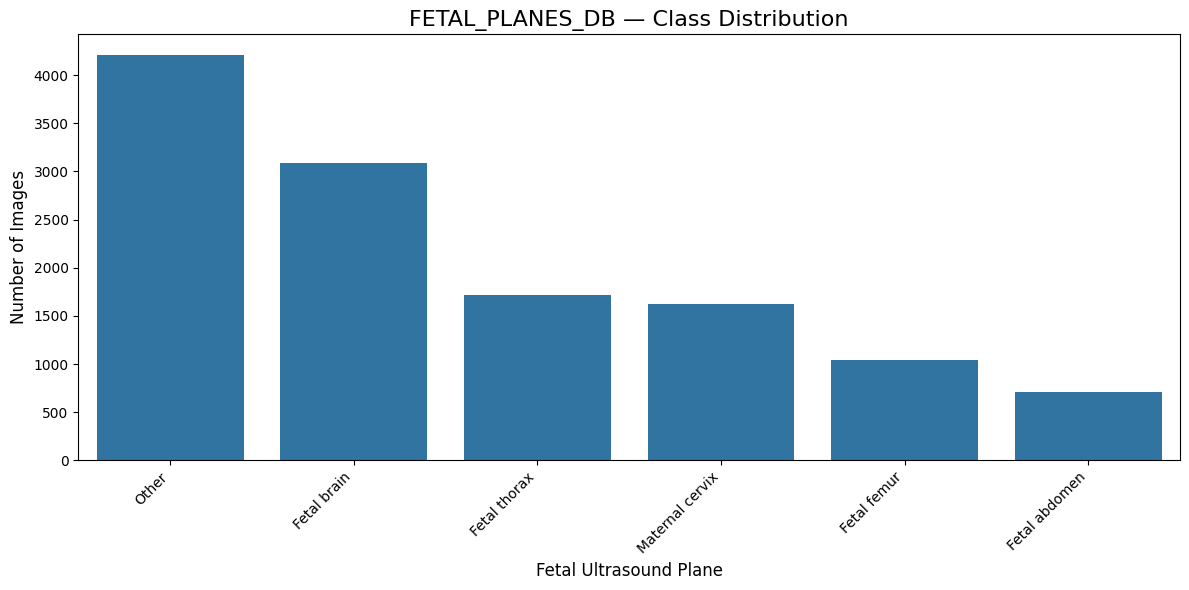


[11] Patient information:
Total unique patients: 1792
Maximum images from one patient: 88
Minimum images from one patient: 1
Average images per patient: 6.92

[12] Indexing actual image files...
Actual image files found: 12400

[13] Matching metadata with images...

IMAGE MATCHING RESULTS
Metadata rows: 12400
Images matched: 12400
Images not matched: 0

[14] Matched image examples:


,Image_name,image_path
0,Patient00001_Plane1_1_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
1,Patient00001_Plane1_2_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
2,Patient00001_Plane1_3_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
3,Patient00001_Plane1_4_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
4,Patient00001_Plane1_5_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
5,Patient00001_Plane1_6_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
6,Patient00001_Plane1_7_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
7,Patient00001_Plane1_8_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
8,Patient00001_Plane1_9_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...
9,Patient00001_Plane1_10_of_15,/kaggle/input/datasets/lithikab23adr096/fetal-...



[16] Label encoding:
0 -> Fetal abdomen
1 -> Fetal brain
2 -> Fetal femur
3 -> Fetal thorax
4 -> Maternal cervix
5 -> Other

[17] Images per class after matching:


,Images
Plane,
Fetal abdomen,711
Fetal brain,3092
Fetal femur,1040
Fetal thorax,1718
Maternal cervix,1626
Other,4213



[18] Sample images from all categories...


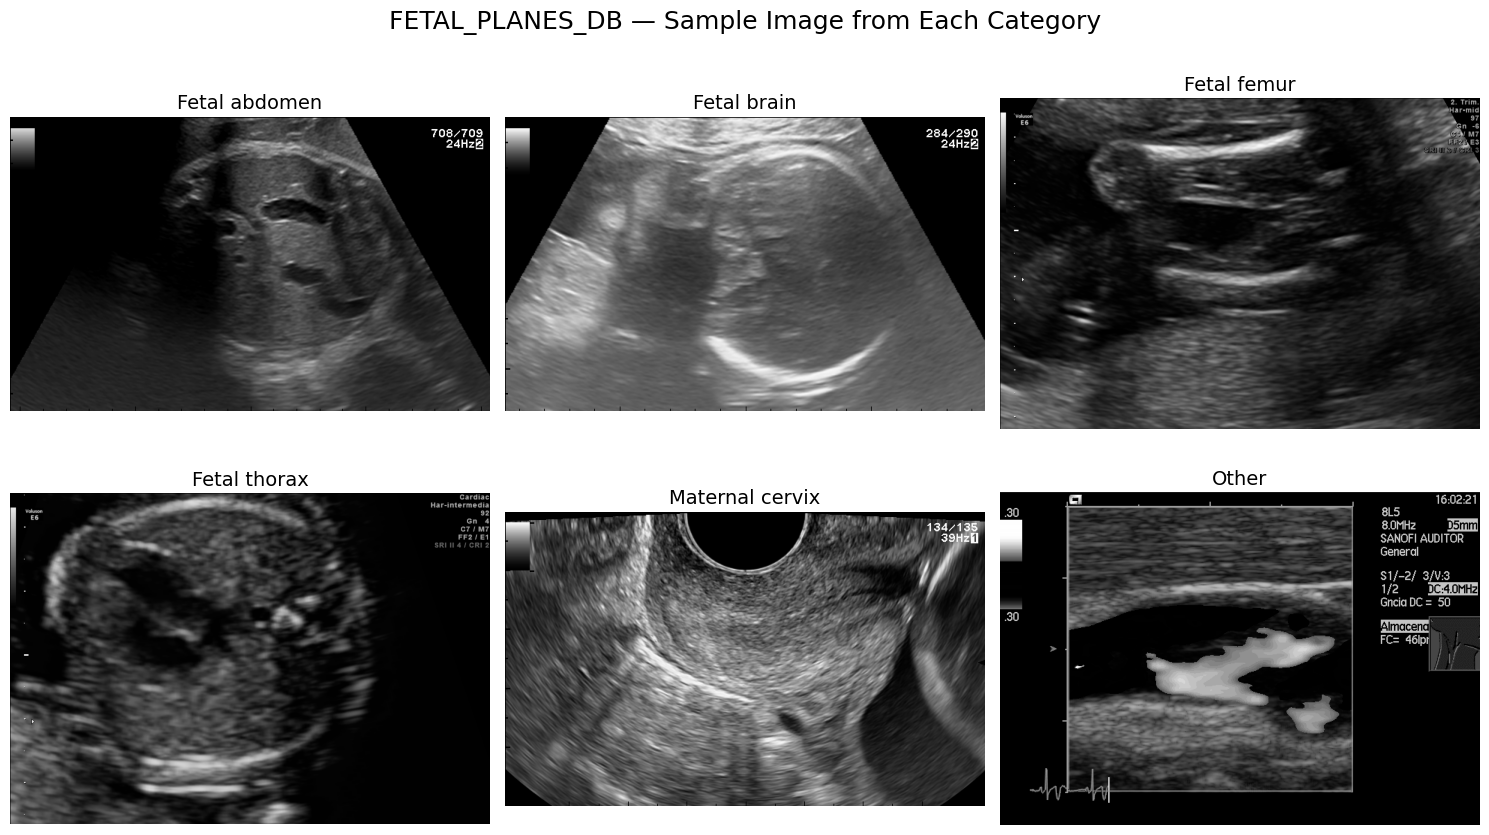


[19] Checking image dimensions...
Images checked: 500


,width,height,mode
count,500.000000,500.000000,500
unique,NaN,NaN,2
top,NaN,NaN,L
freq,NaN,NaN,498
mean,857.642000,572.900000,NaN
std,169.258177,135.865953,NaN
min,320.000000,196.000000,NaN
25%,692.000000,448.000000,NaN
50%,959.000000,661.000000,NaN
75%,959.000000,661.000000,NaN



FINAL DATASET SUMMARY


,Parameter,Value
0,Total Images,12400
1,Unique Patients,1792
2,Number of Classes,6
3,Image Column,Image_name
4,Label Column,Plane
5,Patient Column,Patient_num
6,Matched Images,12400
7,Unmatched Images,0



PART 01 COMPLETED SUCCESSFULLY
Usable images       : 12400
Unique patients     : 1792
Number of classes   : 6
Classes             : ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']
Matched images      : 12400
Unmatched images    : 0

Clean metadata saved at:
/kaggle/working/fetal_project/clean_metadata.csv

Class mapping saved at:
/kaggle/working/fetal_project/class_mapping.json

Ready for PART 02.


In [2]:
# ============================================================
# FETAL ULTRASOUND CLASSIFICATION PROJECT
# PART 01 — DATASET + EDA + SAMPLE IMAGES
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from pathlib import Path

# ------------------------------------------------------------
# 1. REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("=" * 70)
print("FETAL ULTRASOUND CLASSIFICATION PROJECT")
print("PART 01 — DATASET + EDA")
print("=" * 70)


# ------------------------------------------------------------
# 2. KAGGLE INPUT PATH
# ------------------------------------------------------------

KAGGLE_INPUT = "/kaggle/input"

PROJECT_DIR = "/kaggle/working/fetal_project"

# Create project directories
os.makedirs(PROJECT_DIR, exist_ok=True)

os.makedirs(
    os.path.join(PROJECT_DIR, "checkpoints"),
    exist_ok=True
)

os.makedirs(
    os.path.join(PROJECT_DIR, "features"),
    exist_ok=True
)

os.makedirs(
    os.path.join(PROJECT_DIR, "results"),
    exist_ok=True
)

os.makedirs(
    os.path.join(PROJECT_DIR, "xai"),
    exist_ok=True
)


# ------------------------------------------------------------
# 3. AUTOMATICALLY FIND EXCEL FILE
# ------------------------------------------------------------

print("\n[1] Searching for metadata file...")

excel_files = []

for root, dirs, files in os.walk(KAGGLE_INPUT):

    for file in files:

        if file.lower() == "fetal_planes_db_data.xlsx":

            excel_files.append(
                os.path.join(root, file)
            )


if len(excel_files) == 0:

    raise FileNotFoundError(
        "FETAL_PLANES_DB_data.xlsx was not found "
        "inside /kaggle/input."
    )


METADATA_PATH = excel_files[0]

print(
    "Metadata file found:"
)

print(
    METADATA_PATH
)


# ------------------------------------------------------------
# 4. AUTOMATICALLY FIND IMAGES FOLDER
# ------------------------------------------------------------

print("\n[2] Searching for Images folder...")

image_folders = []

for root, dirs, files in os.walk(KAGGLE_INPUT):

    for directory in dirs:

        if directory.lower() == "images":

            image_folders.append(
                os.path.join(root, directory)
            )


if len(image_folders) == 0:

    raise FileNotFoundError(
        "Images folder was not found "
        "inside /kaggle/input."
    )


IMAGE_ROOT = image_folders[0]

print(
    "Images folder found:"
)

print(
    IMAGE_ROOT
)


# ------------------------------------------------------------
# 5. LOAD METADATA
# ------------------------------------------------------------

print("\n[3] Loading metadata...")

df = pd.read_excel(
    METADATA_PATH
)

print(
    "Metadata loaded successfully."
)

print(
    "Dataset shape:",
    df.shape
)


# ------------------------------------------------------------
# 6. DISPLAY COLUMNS
# ------------------------------------------------------------

print("\n[4] Dataset columns:")

for i, column in enumerate(df.columns):

    print(
        f"{i + 1}. {column}"
    )


# ------------------------------------------------------------
# 7. DISPLAY FIRST 5 ROWS
# ------------------------------------------------------------

print("\n[5] First 5 rows:")

display(
    df.head()
)


# ------------------------------------------------------------
# 8. DATASET INFORMATION
# ------------------------------------------------------------

print("\n[6] Dataset information:")

print(
    "Number of rows:",
    len(df)
)

print(
    "Number of columns:",
    len(df.columns)
)

print(
    "Number of unique images:",
    df["Image_name"].nunique()
)

print(
    "Number of unique patients:",
    df["Patient_num"].nunique()
)

print(
    "Number of classes:",
    df["Plane"].nunique()
)


# ------------------------------------------------------------
# 9. MISSING VALUE ANALYSIS
# ------------------------------------------------------------

print("\n[7] Missing value analysis:")

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

display(
    missing_table
)


# ------------------------------------------------------------
# 10. DUPLICATE CHECK
# ------------------------------------------------------------

print("\n[8] Duplicate analysis:")

duplicate_rows = df.duplicated().sum()

duplicate_images = (
    df["Image_name"].duplicated().sum()
)

print(
    "Duplicate rows:",
    duplicate_rows
)

print(
    "Duplicate image names:",
    duplicate_images
)


# ------------------------------------------------------------
# 11. CLASS INFORMATION
# ------------------------------------------------------------

classes = sorted(
    df["Plane"]
    .dropna()
    .unique()
)

print("\n[9] Fetal plane classes:")

for index, class_name in enumerate(classes):

    print(
        f"{index} -> {class_name}"
    )


# ------------------------------------------------------------
# 12. CLASS DISTRIBUTION
# ------------------------------------------------------------

class_counts = (
    df["Plane"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

print("\n[10] Class distribution:")

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Number of Images": class_counts.values
})

display(
    class_distribution
)


# ------------------------------------------------------------
# 13. CLASS DISTRIBUTION PLOT
# ------------------------------------------------------------

plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=class_distribution,
    x="Class",
    y="Number of Images"
)

plt.title(
    "FETAL_PLANES_DB — Class Distribution",
    fontsize=16
)

plt.xlabel(
    "Fetal Ultrasound Plane",
    fontsize=12
)

plt.ylabel(
    "Number of Images",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 14. PATIENT DISTRIBUTION
# ------------------------------------------------------------

print("\n[11] Patient information:")

patient_counts = (
    df["Patient_num"]
    .value_counts()
)

print(
    "Total unique patients:",
    len(patient_counts)
)

print(
    "Maximum images from one patient:",
    patient_counts.max()
)

print(
    "Minimum images from one patient:",
    patient_counts.min()
)

print(
    "Average images per patient:",
    round(
        patient_counts.mean(),
        2
    )
)


# ------------------------------------------------------------
# 15. IMAGE FILE INDEXING
# ------------------------------------------------------------

print("\n[12] Indexing actual image files...")

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

actual_images = []

for root, dirs, files in os.walk(
    IMAGE_ROOT
):

    for file in files:

        extension = (
            Path(file)
            .suffix
            .lower()
        )

        if extension in IMAGE_EXTENSIONS:

            actual_images.append(
                os.path.join(
                    root,
                    file
                )
            )


print(
    "Actual image files found:",
    len(actual_images)
)


# ------------------------------------------------------------
# 16. CREATE IMAGE LOOKUP TABLE
# ------------------------------------------------------------

image_lookup = {}

for full_path in actual_images:

    filename = os.path.basename(
        full_path
    )

    # Full filename
    image_lookup[
        filename.lower()
    ] = full_path

    # Filename without extension
    stem = Path(
        filename
    ).stem.lower()

    image_lookup[
        stem
    ] = full_path


# ------------------------------------------------------------
# 17. NORMALIZE FILENAMES
# ------------------------------------------------------------

def normalize_filename(filename):

    if pd.isna(filename):

        return ""

    filename = str(
        filename
    ).strip()

    # Remove path
    filename = os.path.basename(
        filename
    )

    # Remove extension
    filename = os.path.splitext(
        filename
    )[0]

    # Lowercase
    filename = filename.lower()

    # Remove spaces
    filename = filename.replace(
        " ",
        ""
    )

    return filename


# ------------------------------------------------------------
# 18. CREATE NORMALIZED IMAGE LOOKUP
# ------------------------------------------------------------

normalized_image_lookup = {}

for full_path in actual_images:

    filename = os.path.basename(
        full_path
    )

    normalized_name = (
        normalize_filename(
            filename
        )
    )

    normalized_image_lookup[
        normalized_name
    ] = full_path


# ------------------------------------------------------------
# 19. MATCH METADATA WITH ACTUAL IMAGES
# ------------------------------------------------------------

print("\n[13] Matching metadata with images...")


def find_matching_image(
    image_name
):

    normalized_name = (
        normalize_filename(
            image_name
        )
    )

    # Exact normalized match
    if normalized_name in normalized_image_lookup:

        return normalized_image_lookup[
            normalized_name
        ]

    # Additional fallback
    for actual_name, actual_path in (
        normalized_image_lookup.items()
    ):

        if (
            normalized_name == actual_name
        ):

            return actual_path

    return None


df["image_path"] = (
    df["Image_name"]
    .apply(
        find_matching_image
    )
)


# ------------------------------------------------------------
# 20. IMAGE MATCHING RESULTS
# ------------------------------------------------------------

matched_images = (
    df["image_path"]
    .notna()
    .sum()
)

unmatched_images = (
    df["image_path"]
    .isna()
    .sum()
)

print("\n" + "=" * 70)

print(
    "IMAGE MATCHING RESULTS"
)

print("=" * 70)

print(
    "Metadata rows:",
    len(df)
)

print(
    "Images matched:",
    matched_images
)

print(
    "Images not matched:",
    unmatched_images
)


# ------------------------------------------------------------
# 21. DISPLAY MATCHED EXAMPLES
# ------------------------------------------------------------

print("\n[14] Matched image examples:")

matched_example_table = (
    df[
        df["image_path"].notna()
    ]
    [
        [
            "Image_name",
            "image_path"
        ]
    ]
    .head(10)
)

display(
    matched_example_table
)


# ------------------------------------------------------------
# 22. DISPLAY UNMATCHED EXAMPLES
# ------------------------------------------------------------

if unmatched_images > 0:

    print(
        "\n[15] Unmatched image examples:"
    )

    display(
        df[
            df["image_path"].isna()
        ]
        [
            [
                "Image_name"
            ]
        ]
        .head(10)
    )


# ------------------------------------------------------------
# 23. STOP IF ZERO IMAGES MATCH
# ------------------------------------------------------------

if matched_images == 0:

    print(
        "\nExcel Image_name examples:"
    )

    display(
        df[
            "Image_name"
        ].head(10)
    )

    print(
        "\nActual image filename examples:"
    )

    for path in actual_images[:10]:

        print(
            os.path.basename(
                path
            )
        )

    raise RuntimeError(
        "No images could be matched. "
        "The metadata and image filenames "
        "have different formats."
    )


# ------------------------------------------------------------
# 24. REMOVE ONLY UNMATCHED ROWS
# ------------------------------------------------------------

df = df[
    df["image_path"].notna()
].copy()

df.reset_index(
    drop=True,
    inplace=True
)


# ------------------------------------------------------------
# 25. LABEL ENCODING
# ------------------------------------------------------------

classes = sorted(
    df["Plane"].unique()
)

class_to_idx = {
    class_name: index
    for index, class_name
    in enumerate(classes)
}

idx_to_class = {
    index: class_name
    for class_name, index
    in class_to_idx.items()
}

df["label"] = (
    df["Plane"]
    .map(
        class_to_idx
    )
)


# ------------------------------------------------------------
# 26. DISPLAY LABEL MAPPING
# ------------------------------------------------------------

print("\n[16] Label encoding:")

for class_name, index in (
    class_to_idx.items()
):

    print(
        f"{index} -> {class_name}"
    )


# ------------------------------------------------------------
# 27. VERIFY ALL CLASSES
# ------------------------------------------------------------

print("\n[17] Images per class after matching:")

final_class_counts = (
    df["Plane"]
    .value_counts()
    .sort_index()
)

display(
    final_class_counts.to_frame(
        "Images"
    )
)


# ------------------------------------------------------------
# 28. DISPLAY ONE SAMPLE FROM EACH CATEGORY
# ------------------------------------------------------------

print(
    "\n[18] Sample images from all categories..."
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, class_name in enumerate(classes):

    class_data = df[
        df["Plane"] == class_name
    ]

    # Select one reproducible image
    sample = (
        class_data
        .sample(
            n=1,
            random_state=SEED
        )
        .iloc[0]
    )

    image_path = (
        sample["image_path"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    axes[i].imshow(
        image
    )

    axes[i].set_title(
        class_name,
        fontsize=14
    )

    axes[i].axis(
        "off"
    )


plt.suptitle(
    "FETAL_PLANES_DB — Sample Image from Each Category",
    fontsize=18
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 29. CHECK IMAGE DIMENSIONS
# ------------------------------------------------------------

print(
    "\n[19] Checking image dimensions..."
)

dimension_data = []

# Check up to 500 images
dimension_sample = df.sample(
    min(
        500,
        len(df)
    ),
    random_state=SEED
)

for _, row in dimension_sample.iterrows():

    try:

        image = Image.open(
            row["image_path"]
        )

        dimension_data.append({

            "width":
                image.width,

            "height":
                image.height,

            "mode":
                image.mode

        })

    except Exception:

        pass


dimension_df = pd.DataFrame(
    dimension_data
)

print(
    "Images checked:",
    len(dimension_df)
)

display(
    dimension_df.describe(
        include="all"
    )
)


# ------------------------------------------------------------
# 30. SAVE CLEAN METADATA
# ------------------------------------------------------------

clean_metadata_path = os.path.join(
    PROJECT_DIR,
    "clean_metadata.csv"
)

df.to_csv(
    clean_metadata_path,
    index=False
)


# ------------------------------------------------------------
# 31. SAVE CLASS MAPPING
# ------------------------------------------------------------

class_mapping_path = os.path.join(
    PROJECT_DIR,
    "class_mapping.json"
)

with open(
    class_mapping_path,
    "w"
) as file:

    json.dump(
        {
            "class_to_idx":
                class_to_idx,

            "idx_to_class":
                {
                    str(key): value
                    for key, value
                    in idx_to_class.items()
                }
        },
        file,
        indent=4
    )


# ------------------------------------------------------------
# 32. FINAL DATASET SUMMARY
# ------------------------------------------------------------

final_summary = pd.DataFrame({

    "Parameter": [

        "Total Images",

        "Unique Patients",

        "Number of Classes",

        "Image Column",

        "Label Column",

        "Patient Column",

        "Matched Images",

        "Unmatched Images"

    ],

    "Value": [

        len(df),

        df[
            "Patient_num"
        ].nunique(),

        len(classes),

        "Image_name",

        "Plane",

        "Patient_num",

        matched_images,

        unmatched_images

    ]

})


print("\n" + "=" * 70)

print(
    "FINAL DATASET SUMMARY"
)

print("=" * 70)

display(
    final_summary
)


# ------------------------------------------------------------
# 33. FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)

print(
    "PART 01 COMPLETED SUCCESSFULLY"
)

print("=" * 70)

print(
    "Usable images       :",
    len(df)
)

print(
    "Unique patients     :",
    df["Patient_num"].nunique()
)

print(
    "Number of classes   :",
    len(classes)
)

print(
    "Classes             :",
    classes
)

print(
    "Matched images      :",
    matched_images
)

print(
    "Unmatched images    :",
    unmatched_images
)

print(
    "\nClean metadata saved at:"
)

print(
    clean_metadata_path
)

print(
    "\nClass mapping saved at:"
)

print(
    class_mapping_path
)

print("\nReady for PART 02.")

PART 02 — PREPROCESSING + PATIENT-WISE SPLIT

Dataset shape: (12400, 9)

Classes:
0 -> Fetal abdomen
1 -> Fetal brain
2 -> Fetal femur
3 -> Fetal thorax
4 -> Maternal cervix
5 -> Other

DATA SPLIT
Train images      : 9068
Validation images : 1644
Test images       : 1688
Total             : 12400

Patient counts:
Train patients      : 1254
Validation patients : 269
Test patients       : 269

PATIENT LEAKAGE CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

✓ No patient leakage detected.

CLASS DISTRIBUTION


,Class,Train,Validation,Test,Total
0,Fetal abdomen,508,109,94,711
1,Fetal brain,2169,463,460,3092
2,Fetal femur,746,150,144,1040
3,Fetal thorax,1250,223,245,1718
4,Maternal cervix,1148,223,255,1626
5,Other,3247,476,490,4213


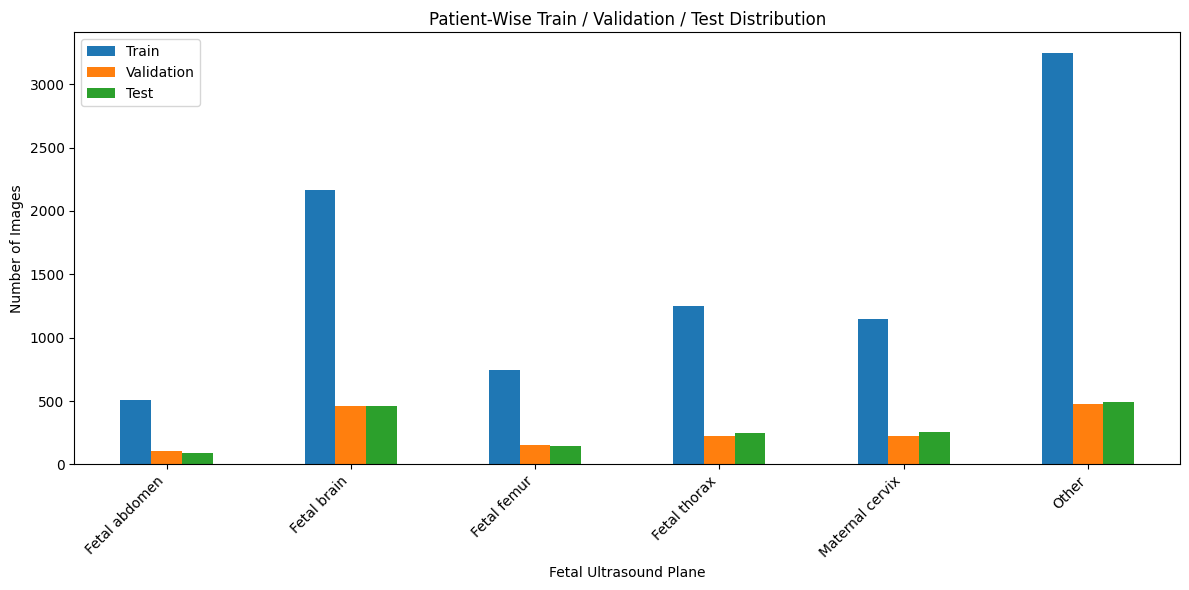


Dataset objects created:
Train dataset: 9068
Validation dataset: 1644
Test dataset: 1688

Processed image shape:
torch.Size([3, 224, 224])
Label: 5
Class: Other

DATALOADER CHECK
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels in first batch: [1, 2, 2, 5, 5, 3, 2, 5, 1, 3]

PART 02 COMPLETED


,Split,Images,Patients
0,Train,9068,1254
1,Validation,1644,269
2,Test,1688,269


Train CSV: /kaggle/working/fetal_project/train.csv
Validation CSV: /kaggle/working/fetal_project/val.csv
Test CSV: /kaggle/working/fetal_project/test.csv

Preprocessing:
Resize       : 224 × 224
Augmentation : Flip + Rotation + Brightness/Contrast
Normalization: ImageNet mean/std

✓ Patient-wise split completed.
✓ No patient leakage.
✓ DataLoaders ready.
✓ Ready for PART 03 — ViT training + hyperparameter tuning.


In [3]:
# ============================================================
# FETAL ULTRASOUND CLASSIFICATION PROJECT
# PART 02 — PREPROCESSING + PATIENT-WISE DATA SPLIT
# ============================================================

import os
import random
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import GroupShuffleSplit

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. PROJECT PATH
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"

CLEAN_METADATA = os.path.join(
    PROJECT_DIR,
    "clean_metadata.csv"
)


# ============================================================
# 3. LOAD CLEAN METADATA
# ============================================================

if not os.path.exists(CLEAN_METADATA):

    raise FileNotFoundError(
        "clean_metadata.csv not found. "
        "Please run PART 01 first."
    )

df = pd.read_csv(
    CLEAN_METADATA
)

print("=" * 70)
print("PART 02 — PREPROCESSING + PATIENT-WISE SPLIT")
print("=" * 70)

print(
    "\nDataset shape:",
    df.shape
)


# ============================================================
# 4. RESTORE CLASS INFORMATION
# ============================================================

classes = sorted(
    df["Plane"].unique()
)

class_to_idx = {
    class_name: index
    for index, class_name
    in enumerate(classes)
}

idx_to_class = {
    index: class_name
    for class_name, index
    in class_to_idx.items()
}

# Make sure labels are integers
df["label"] = df["Plane"].map(
    class_to_idx
).astype(int)

print("\nClasses:")

for index, class_name in idx_to_class.items():

    print(
        f"{index} -> {class_name}"
    )


# ============================================================
# 5. PATIENT-WISE TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# ------------------------------------------------------------
# Split ratio:
# Train      = 70%
# Validation = 15%
# Test       = 15%
#
# IMPORTANT:
# Images belonging to the same patient will NEVER appear
# in different splits.
# ------------------------------------------------------------


# ------------------------------------------------------------
# STEP 1 — TRAIN+VALIDATION / TEST
# ------------------------------------------------------------

split_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=SEED
)

train_val_indices, test_indices = next(
    split_1.split(
        df,
        groups=df["Patient_num"]
    )
)


train_val_df = df.iloc[
    train_val_indices
].copy()

test_df = df.iloc[
    test_indices
].copy()


# ------------------------------------------------------------
# STEP 2 — TRAIN / VALIDATION
# ------------------------------------------------------------

# We need approximately 15% validation
# from the complete dataset.

# 15 / 85 = 0.17647

split_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.17647,
    random_state=SEED
)

train_indices, val_indices = next(
    split_2.split(
        train_val_df,
        groups=train_val_df["Patient_num"]
    )
)


train_df = train_val_df.iloc[
    train_indices
].copy()

val_df = train_val_df.iloc[
    val_indices
].copy()


# Reset indices
train_df.reset_index(
    drop=True,
    inplace=True
)

val_df.reset_index(
    drop=True,
    inplace=True
)

test_df.reset_index(
    drop=True,
    inplace=True
)


# ============================================================
# 6. DISPLAY SPLIT INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("DATA SPLIT")
print("=" * 70)

print(
    "Train images      :",
    len(train_df)
)

print(
    "Validation images :",
    len(val_df)
)

print(
    "Test images       :",
    len(test_df)
)

print(
    "Total             :",
    len(train_df) +
    len(val_df) +
    len(test_df)
)


# ============================================================
# 7. PATIENT COUNTS
# ============================================================

print("\nPatient counts:")

print(
    "Train patients      :",
    train_df["Patient_num"].nunique()
)

print(
    "Validation patients :",
    val_df["Patient_num"].nunique()
)

print(
    "Test patients       :",
    test_df["Patient_num"].nunique()
)


# ============================================================
# 8. CHECK PATIENT LEAKAGE
# ============================================================

train_patients = set(
    train_df["Patient_num"]
)

val_patients = set(
    val_df["Patient_num"]
)

test_patients = set(
    test_df["Patient_num"]
)


train_val_overlap = (
    train_patients &
    val_patients
)

train_test_overlap = (
    train_patients &
    test_patients
)

val_test_overlap = (
    val_patients &
    test_patients
)


print("\n" + "=" * 70)
print("PATIENT LEAKAGE CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_val_overlap)
)

print(
    "Train ∩ Test:",
    len(train_test_overlap)
)

print(
    "Validation ∩ Test:",
    len(val_test_overlap)
)


if (
    len(train_val_overlap) == 0
    and
    len(train_test_overlap) == 0
    and
    len(val_test_overlap) == 0
):

    print(
        "\n✓ No patient leakage detected."
    )

else:

    raise RuntimeError(
        "Patient leakage detected!"
    )


# ============================================================
# 9. CLASS DISTRIBUTION IN EACH SPLIT
# ============================================================

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)


split_distribution = pd.DataFrame({

    "Class": classes,

    "Train": [
        (train_df["Plane"] == c).sum()
        for c in classes
    ],

    "Validation": [
        (val_df["Plane"] == c).sum()
        for c in classes
    ],

    "Test": [
        (test_df["Plane"] == c).sum()
        for c in classes
    ]

})

split_distribution["Total"] = (
    split_distribution["Train"]
    +
    split_distribution["Validation"]
    +
    split_distribution["Test"]
)

display(
    split_distribution
)


# ============================================================
# 10. CLASS DISTRIBUTION PLOT
# ============================================================

import matplotlib.pyplot as plt

plot_df = split_distribution.set_index(
    "Class"
)

plot_df[
    ["Train", "Validation", "Test"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Patient-Wise Train / Validation / Test Distribution"
)

plt.xlabel(
    "Fetal Ultrasound Plane"
)

plt.ylabel(
    "Number of Images"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. IMAGE PREPROCESSING
# ============================================================

IMG_SIZE = 224


# ------------------------------------------------------------
# TRAIN TRANSFORM
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    # Data augmentation
    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ------------------------------------------------------------
# VALIDATION / TEST TRANSFORM
# ------------------------------------------------------------

val_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 12. CUSTOM DATASET
# ============================================================

class FetalUltrasoundDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image_path = row[
            "image_path"
        ]

        label = int(
            row["label"]
        )

        # Load image
        image = Image.open(
            image_path
        ).convert("RGB")

        # Apply preprocessing
        if self.transform is not None:

            image = self.transform(
                image
            )

        return image, label


# ============================================================
# 13. CREATE DATASETS
# ============================================================

train_dataset = FetalUltrasoundDataset(
    train_df,
    transform=train_transform
)

val_dataset = FetalUltrasoundDataset(
    val_df,
    transform=val_transform
)

test_dataset = FetalUltrasoundDataset(
    test_df,
    transform=val_transform
)


print("\nDataset objects created:")

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)


# ============================================================
# 14. CHECK ONE PROCESSED IMAGE
# ============================================================

sample_image, sample_label = (
    train_dataset[0]
)

print("\nProcessed image shape:")

print(
    sample_image.shape
)

print(
    "Label:",
    sample_label
)

print(
    "Class:",
    idx_to_class[
        sample_label
    ]
)


# ============================================================
# 15. DATA LOADERS
# ============================================================

BATCH_SIZE = 32

# Reduce workers if Kaggle has DataLoader issues
NUM_WORKERS = 2


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available()
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available()
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available()
)


# ============================================================
# 16. CHECK BATCH
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("\n" + "=" * 70)
print("DATALOADER CHECK")
print("=" * 70)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

print(
    "Labels in first batch:",
    labels[:10].tolist()
)


# ============================================================
# 17. SAVE SPLITS
# ============================================================

train_path = os.path.join(
    PROJECT_DIR,
    "train.csv"
)

val_path = os.path.join(
    PROJECT_DIR,
    "val.csv"
)

test_path = os.path.join(
    PROJECT_DIR,
    "test.csv"
)


train_df.to_csv(
    train_path,
    index=False
)

val_df.to_csv(
    val_path,
    index=False
)

test_df.to_csv(
    test_path,
    index=False
)


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

summary = pd.DataFrame({

    "Split": [
        "Train",
        "Validation",
        "Test"
    ],

    "Images": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],

    "Patients": [
        train_df[
            "Patient_num"
        ].nunique(),

        val_df[
            "Patient_num"
        ].nunique(),

        test_df[
            "Patient_num"
        ].nunique()
    ]

})

print("\n" + "=" * 70)
print("PART 02 COMPLETED")
print("=" * 70)

display(summary)

print(
    "Train CSV:",
    train_path
)

print(
    "Validation CSV:",
    val_path
)

print(
    "Test CSV:",
    test_path
)

print(
    "\nPreprocessing:"
)

print(
    "Resize       : 224 × 224"
)

print(
    "Augmentation : Flip + Rotation + Brightness/Contrast"
)

print(
    "Normalization: ImageNet mean/std"
)

print(
    "\n✓ Patient-wise split completed."
)

print(
    "✓ No patient leakage."
)

print(
    "✓ DataLoaders ready."
)

print(
    "✓ Ready for PART 03 — ViT training + hyperparameter tuning."
)

PART 03 — ViT + HYPERPARAMETER TUNING

Device: cuda
Number of classes: 6
Classes: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']


ViT EXPERIMENT 1
Learning rate : 0.0001
Weight decay  : 0.0001
Dropout       : 0.2
Epochs        : 3
Epoch 01/3 | Train Loss: 1.4935 | Train Acc: 0.4255 | Val Acc: 0.6077 | Val Macro-F1: 0.4134
Epoch 02/3 | Train Loss: 1.0192 | Train Acc: 0.6228 | Val Acc: 0.6442 | Val Macro-F1: 0.4713
Epoch 03/3 | Train Loss: 0.8207 | Train Acc: 0.6873 | Val Acc: 0.6940 | Val Macro-F1: 0.5629


ViT EXPERIMENT 2
Learning rate : 5e-05
Weight decay  : 0.0001
Dropout       : 0.3
Epochs        : 3
Epoch 01/3 | Train Loss: 1.4111 | Train Acc: 0.4629 | Val Acc: 0.5554 | Val Macro-F1: 0.4207
Epoch 02/3 | Train Loss: 0.9477 | Train Acc: 0.6421 | Val Acc: 0.6387 | Val Macro-F1: 0.4524
Epoch 03/3 | Train Loss: 0.7565 | Train Acc: 0.7045 | Val Acc: 0.7147 | Val Macro-F1: 0.5794


ViT EXPERIMENT 3
Learning rate : 0.0001
Weight decay  : 1e-05

,Experiment,Learning Rate,Weight Decay,Dropout,Accuracy,Precision,Recall,Macro-F1,Balanced Accuracy
0,2,0.00005,0.00010,0.3,0.714720,0.576081,0.603392,0.579374,0.603392
1,1,0.00010,0.00010,0.2,0.694039,0.565888,0.572733,0.562932,0.572733
2,3,0.00010,0.00001,0.3,0.676399,0.581328,0.527721,0.519527,0.527721




BEST ViT CONFIGURATION
Experiment: 2
Learning Rate: 5e-05
Weight Decay: 0.0001
Dropout: 0.3
Validation Accuracy: 0.7147201946472019
Validation Macro-F1: 0.5793740369829453


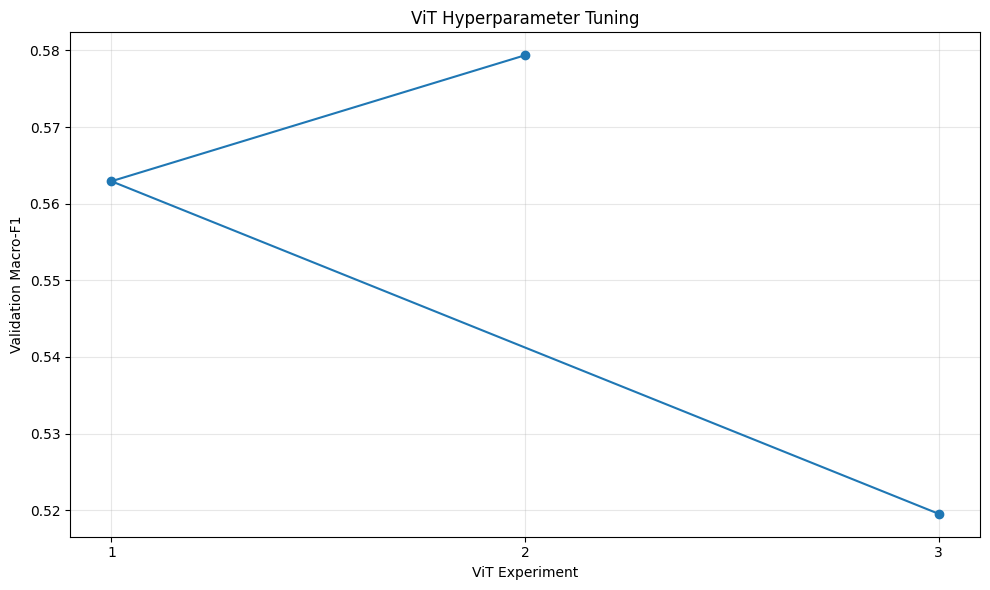



BEST ViT VALIDATION PERFORMANCE
Accuracy: 0.7147
Precision: 0.5761
Recall: 0.6034
Macro-F1: 0.5794
Balanced Accuracy: 0.6034
Loss: 0.7465

Best ViT model saved:
/kaggle/working/fetal_project/checkpoints/best_vit_model.pth


PART 03 COMPLETED
Model              : ViT
Tuning              : YES
Tuning performed    : During ViT training
Validation used     : YES
Test set used       : NO
Best Macro-F1       : 0.5794
Best checkpoint     : /kaggle/working/fetal_project/checkpoints/best_vit_model.pth

Ready for PART 04 — DenseNet121 + hyperparameter tuning.


In [4]:
# ============================================================
# FETAL ULTRASOUND CLASSIFICATION PROJECT
# PART 03 — ViT + HYPERPARAMETER TUNING
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. DEVICE
# ============================================================

# If your Kaggle GPU gives:
# "CUDA error: no kernel image is available for execution
# on the device"
# change FORCE_CPU = True

FORCE_CPU = False

if FORCE_CPU:
    DEVICE = torch.device("cpu")
else:
    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

print("=" * 70)
print("PART 03 — ViT + HYPERPARAMETER TUNING")
print("=" * 70)

print("\nDevice:", DEVICE)


# ============================================================
# 3. CHECK VARIABLES FROM PART 02
# ============================================================

required_variables = [
    "train_loader",
    "val_loader",
    "classes",
    "idx_to_class",
    "PROJECT_DIR"
]

for variable in required_variables:

    if variable not in globals():

        raise RuntimeError(
            f"{variable} is missing. "
            f"Please run PART 02 first."
        )


NUM_CLASSES = len(classes)

print(
    "Number of classes:",
    NUM_CLASSES
)

print(
    "Classes:",
    classes
)


# ============================================================
# 4. ViT MODEL
# ============================================================

class ViTClassifier(nn.Module):

    def __init__(
        self,
        num_classes,
        dropout=0.2
    ):

        super().__init__()

        # ----------------------------------------------------
        # IMPORTANT:
        # weights=None avoids HuggingFace/internet download
        # problems in Kaggle.
        # ----------------------------------------------------

        self.backbone = models.vit_b_16(
            weights=None
        )

        # Number of input features to classification head
        in_features = (
            self.backbone.heads.head.in_features
        )

        # Replace original ImageNet classifier
        self.backbone.heads.head = nn.Sequential(

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                in_features,
                num_classes
            )
        )


    def forward(self, x):

        return self.backbone(x)


# ============================================================
# 5. METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro-F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


# ============================================================
# 6. VALIDATION FUNCTION
# ============================================================

def validate_vit(
    model,
    loader
):

    model.eval()

    all_labels = []
    all_predictions = []

    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item()
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    metrics = calculate_metrics(
        all_labels,
        all_predictions
    )

    metrics["Loss"] = (
        total_loss /
        len(loader)
    )

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions)
    )


# ============================================================
# 7. ViT TRAINING FUNCTION
# ============================================================

def train_vit(
    learning_rate,
    weight_decay,
    dropout,
    epochs,
    experiment_number
):

    print("\n")
    print("=" * 70)

    print(
        f"ViT EXPERIMENT {experiment_number}"
    )

    print("=" * 70)

    print(
        "Learning rate :",
        learning_rate
    )

    print(
        "Weight decay  :",
        weight_decay
    )

    print(
        "Dropout       :",
        dropout
    )

    print(
        "Epochs        :",
        epochs
    )


    # --------------------------------------------------------
    # CREATE MODEL
    # --------------------------------------------------------

    model = ViTClassifier(

        num_classes=NUM_CLASSES,

        dropout=dropout
    )

    model = model.to(
        DEVICE
    )


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = optim.AdamW(

        model.parameters(),

        lr=learning_rate,

        weight_decay=weight_decay
    )


    # --------------------------------------------------------
    # LR SCHEDULER
    # --------------------------------------------------------

    scheduler = optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=epochs
    )


    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    checkpoint_path = os.path.join(

        PROJECT_DIR,

        "checkpoints",

        f"vit_tuning_{experiment_number}.pth"
    )


    best_macro_f1 = -1.0

    history = []


    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        correct = 0

        total = 0


        for images, labels in train_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )


            # ------------------------------------------------
            # Clear gradients
            # ------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )


            # ------------------------------------------------
            # Forward
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # Loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            loss.backward()


            # ------------------------------------------------
            # Update weights
            # ------------------------------------------------

            optimizer.step()


            # ------------------------------------------------
            # Statistics
            # ------------------------------------------------

            running_loss += (
                loss.item()
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += (
                labels.size(0)
            )


        # ----------------------------------------------------
        # Scheduler
        # ----------------------------------------------------

        scheduler.step()


        # ----------------------------------------------------
        # Training accuracy
        # ----------------------------------------------------

        train_accuracy = (
            correct / total
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        val_metrics, _, _ = validate_vit(

            model,

            val_loader
        )


        # ----------------------------------------------------
        # Store history
        # ----------------------------------------------------

        epoch_record = {

            "Experiment":
                experiment_number,

            "Epoch":
                epoch + 1,

            "Train Loss":
                running_loss /
                len(train_loader),

            "Train Accuracy":
                train_accuracy,

            "Val Loss":
                val_metrics["Loss"],

            "Val Accuracy":
                val_metrics["Accuracy"],

            "Val Precision":
                val_metrics["Precision"],

            "Val Recall":
                val_metrics["Recall"],

            "Val Macro-F1":
                val_metrics["Macro-F1"],

            "Val Balanced Accuracy":
                val_metrics[
                    "Balanced Accuracy"
                ]
        }

        history.append(
            epoch_record
        )


        # ----------------------------------------------------
        # DISPLAY
        # ----------------------------------------------------

        print(

            f"Epoch {epoch + 1:02d}/{epochs} | "

            f"Train Loss: "
            f"{epoch_record['Train Loss']:.4f} | "

            f"Train Acc: "
            f"{train_accuracy:.4f} | "

            f"Val Acc: "
            f"{val_metrics['Accuracy']:.4f} | "

            f"Val Macro-F1: "
            f"{val_metrics['Macro-F1']:.4f}"
        )


        # ----------------------------------------------------
        # SAVE BEST MODEL
        # ----------------------------------------------------

        if (
            val_metrics["Macro-F1"]
            >
            best_macro_f1
        ):

            best_macro_f1 = (
                val_metrics["Macro-F1"]
            )

            torch.save(

                {

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "scheduler_state_dict":
                        scheduler.state_dict(),

                    "epoch":
                        epoch + 1,

                    "best_macro_f1":
                        best_macro_f1,

                    "learning_rate":
                        learning_rate,

                    "weight_decay":
                        weight_decay,

                    "dropout":
                        dropout

                },

                checkpoint_path
            )


    # ========================================================
    # LOAD BEST CHECKPOINT
    # ========================================================

    checkpoint = torch.load(

        checkpoint_path,

        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )


    # ========================================================
    # FINAL VALIDATION METRICS
    # ========================================================

    final_metrics, _, _ = validate_vit(

        model,

        val_loader
    )


    return (
        model,
        pd.DataFrame(history),
        final_metrics,
        checkpoint_path
    )


# ============================================================
# 8. HYPERPARAMETER SEARCH SPACE
# ============================================================

# We tune ViT WHILE training it.

# Parameters:
# Learning Rate
# Weight Decay
# Dropout
#
# Keep this search small initially for Kaggle runtime.

VIT_HYPERPARAMETERS = [

    {
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "dropout": 0.2
    },

    {
        "learning_rate": 5e-5,
        "weight_decay": 1e-4,
        "dropout": 0.3
    },

    {
        "learning_rate": 1e-4,
        "weight_decay": 1e-5,
        "dropout": 0.3
    }

]


# ============================================================
# 9. TRAIN ALL ViT CONFIGURATIONS
# ============================================================

VIT_EPOCHS = 3

vit_results = []

vit_histories = {}

vit_checkpoints = {}


for experiment_number, hp in enumerate(

    VIT_HYPERPARAMETERS,

    start=1
):

    model = None

    try:

        (
            model,
            history,
            metrics,
            checkpoint_path

        ) = train_vit(

            learning_rate=
                hp["learning_rate"],

            weight_decay=
                hp["weight_decay"],

            dropout=
                hp["dropout"],

            epochs=
                VIT_EPOCHS,

            experiment_number=
                experiment_number
        )


        # ----------------------------------------------------
        # SAVE HISTORY
        # ----------------------------------------------------

        vit_histories[
            experiment_number
        ] = history


        vit_checkpoints[
            experiment_number
        ] = checkpoint_path


        # ----------------------------------------------------
        # SAVE RESULT
        # ----------------------------------------------------

        vit_results.append({

            "Experiment":
                experiment_number,

            "Learning Rate":
                hp["learning_rate"],

            "Weight Decay":
                hp["weight_decay"],

            "Dropout":
                hp["dropout"],

            "Accuracy":
                metrics["Accuracy"],

            "Precision":
                metrics["Precision"],

            "Recall":
                metrics["Recall"],

            "Macro-F1":
                metrics["Macro-F1"],

            "Balanced Accuracy":
                metrics[
                    "Balanced Accuracy"
                ]

        })


    finally:

        if model is not None:

            del model

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()


# ============================================================
# 10. ViT RESULTS TABLE
# ============================================================

vit_results_df = pd.DataFrame(
    vit_results
)

vit_results_df = (
    vit_results_df
    .sort_values(
        "Macro-F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 70)
print("ViT HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

display(
    vit_results_df
)


# ============================================================
# 11. SELECT BEST ViT CONFIGURATION
# ============================================================

best_vit_row = (
    vit_results_df
    .iloc[0]
)

best_vit_experiment = int(
    best_vit_row[
        "Experiment"
    ]
)

best_vit_hp = {

    "learning_rate":
        float(
            best_vit_row[
                "Learning Rate"
            ]
        ),

    "weight_decay":
        float(
            best_vit_row[
                "Weight Decay"
            ]
        ),

    "dropout":
        float(
            best_vit_row[
                "Dropout"
            ]
        )
}


print("\n")
print("=" * 70)
print("BEST ViT CONFIGURATION")
print("=" * 70)

print(
    "Experiment:",
    best_vit_experiment
)

print(
    "Learning Rate:",
    best_vit_hp[
        "learning_rate"
    ]
)

print(
    "Weight Decay:",
    best_vit_hp[
        "weight_decay"
    ]
)

print(
    "Dropout:",
    best_vit_hp[
        "dropout"
    ]
)

print(
    "Validation Accuracy:",
    best_vit_row[
        "Accuracy"
    ]
)

print(
    "Validation Macro-F1:",
    best_vit_row[
        "Macro-F1"
    ]
)


# ============================================================
# 12. SAVE ViT RESULTS
# ============================================================

vit_results_path = os.path.join(

    PROJECT_DIR,

    "results",

    "vit_hyperparameter_results.csv"
)

vit_results_df.to_csv(

    vit_results_path,

    index=False
)


# ============================================================
# 13. SAVE BEST ViT INFORMATION
# ============================================================

best_vit_info = {

    "model":
        "ViT",

    "experiment":
        best_vit_experiment,

    "learning_rate":
        best_vit_hp[
            "learning_rate"
        ],

    "weight_decay":
        best_vit_hp[
            "weight_decay"
        ],

    "dropout":
        best_vit_hp[
            "dropout"
        ],

    "validation_accuracy":
        float(
            best_vit_row[
                "Accuracy"
            ]
        ),

    "validation_precision":
        float(
            best_vit_row[
                "Precision"
            ]
        ),

    "validation_recall":
        float(
            best_vit_row[
                "Recall"
            ]
        ),

    "validation_macro_f1":
        float(
            best_vit_row[
                "Macro-F1"
            ]
        ),

    "validation_balanced_accuracy":
        float(
            best_vit_row[
                "Balanced Accuracy"
            ]
        ),

    "checkpoint":
        vit_checkpoints[
            best_vit_experiment
        ]
}


with open(

    os.path.join(

        PROJECT_DIR,

        "results",

        "best_vit_config.json"

    ),

    "w"

) as f:

    json.dump(

        best_vit_info,

        f,

        indent=4
    )


# ============================================================
# 14. PLOT ViT HYPERPARAMETER EXPERIMENTS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(

    vit_results_df[
        "Experiment"
    ],

    vit_results_df[
        "Macro-F1"
    ],

    marker="o"
)

plt.xlabel(
    "ViT Experiment"
)

plt.ylabel(
    "Validation Macro-F1"
)

plt.title(
    "ViT Hyperparameter Tuning"
)

plt.xticks(
    vit_results_df[
        "Experiment"
    ]
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. LOAD BEST ViT MODEL
# ============================================================

best_vit_model = ViTClassifier(

    num_classes=NUM_CLASSES,

    dropout=
        best_vit_hp[
            "dropout"
        ]
)

best_vit_model = best_vit_model.to(
    DEVICE
)


best_checkpoint_path = (
    vit_checkpoints[
        best_vit_experiment
    ]
)


checkpoint = torch.load(

    best_checkpoint_path,

    map_location=DEVICE
)


best_vit_model.load_state_dict(

    checkpoint[
        "model_state_dict"
    ]
)


best_vit_model.eval()


# ============================================================
# 16. FINAL BEST ViT VALIDATION
# ============================================================

best_vit_metrics, _, _ = validate_vit(

    best_vit_model,

    val_loader
)


print("\n")
print("=" * 70)
print("BEST ViT VALIDATION PERFORMANCE")
print("=" * 70)

for metric, value in (
    best_vit_metrics.items()
):

    print(
        f"{metric}: {value:.4f}"
    )


# ============================================================
# 17. SAVE BEST ViT MODEL
# ============================================================

final_vit_checkpoint = os.path.join(

    PROJECT_DIR,

    "checkpoints",

    "best_vit_model.pth"
)


torch.save(

    {

        "model_state_dict":
            best_vit_model.state_dict(),

        "model_name":
            "ViT",

        "num_classes":
            NUM_CLASSES,

        "classes":
            classes,

        "hyperparameters":
            best_vit_hp,

        "validation_metrics":
            best_vit_metrics

    },

    final_vit_checkpoint
)


print(
    "\nBest ViT model saved:"
)

print(
    final_vit_checkpoint
)


# ============================================================
# 18. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 70)
print("PART 03 COMPLETED")
print("=" * 70)

print(
    "Model              : ViT"
)

print(
    "Tuning              : YES"
)

print(
    "Tuning performed    : During ViT training"
)

print(
    "Validation used     : YES"
)

print(
    "Test set used       : NO"
)

print(
    "Best Macro-F1       :",
    round(
        best_vit_metrics[
            "Macro-F1"
        ],
        4
    )
)

print(
    "Best checkpoint     :",
    final_vit_checkpoint
)

print(
    "\nReady for PART 04 — DenseNet121 + hyperparameter tuning."
)

PART 04 — DENSENET121 + HYPERPARAMETER TUNING

Device: cuda
Number of classes: 6
Classes: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']


DenseNet121 EXPERIMENT 1
Learning rate : 0.0001
Weight decay  : 0.0001
Dropout       : 0.2
Epochs        : 3
Epoch 01/3 | Train Loss: 0.7700 | Train Acc: 0.7264 | Val Acc: 0.8400 | Val Macro-F1: 0.7453
Epoch 02/3 | Train Loss: 0.4015 | Train Acc: 0.8571 | Val Acc: 0.7974 | Val Macro-F1: 0.7528
Epoch 03/3 | Train Loss: 0.2976 | Train Acc: 0.8994 | Val Acc: 0.9148 | Val Macro-F1: 0.8930


DenseNet121 EXPERIMENT 2
Learning rate : 5e-05
Weight decay  : 0.0001
Dropout       : 0.3
Epochs        : 3
Epoch 01/3 | Train Loss: 0.9613 | Train Acc: 0.6562 | Val Acc: 0.8108 | Val Macro-F1: 0.6863
Epoch 02/3 | Train Loss: 0.5162 | Train Acc: 0.8193 | Val Acc: 0.8498 | Val Macro-F1: 0.7502
Epoch 03/3 | Train Loss: 0.4221 | Train Acc: 0.8524 | Val Acc: 0.8735 | Val Macro-F1: 0.8062


DenseNet121 EXPERIMENT 3
Learning rat

,Experiment,Learning Rate,Weight Decay,Dropout,Accuracy,Precision,Recall,Macro-F1,Balanced Accuracy
0,1,0.00010,0.00010,0.2,0.914842,0.890270,0.895829,0.892976,0.895829
1,3,0.00010,0.00001,0.4,0.869221,0.843803,0.818858,0.825727,0.818858
2,2,0.00005,0.00010,0.3,0.873479,0.865183,0.806027,0.806181,0.806027




BEST DENSENET121 CONFIGURATION
Experiment: 1
Learning Rate: 0.0001
Weight Decay: 0.0001
Dropout: 0.2
Validation Accuracy: 0.9148418491484185
Validation Macro-F1: 0.8929762490045771


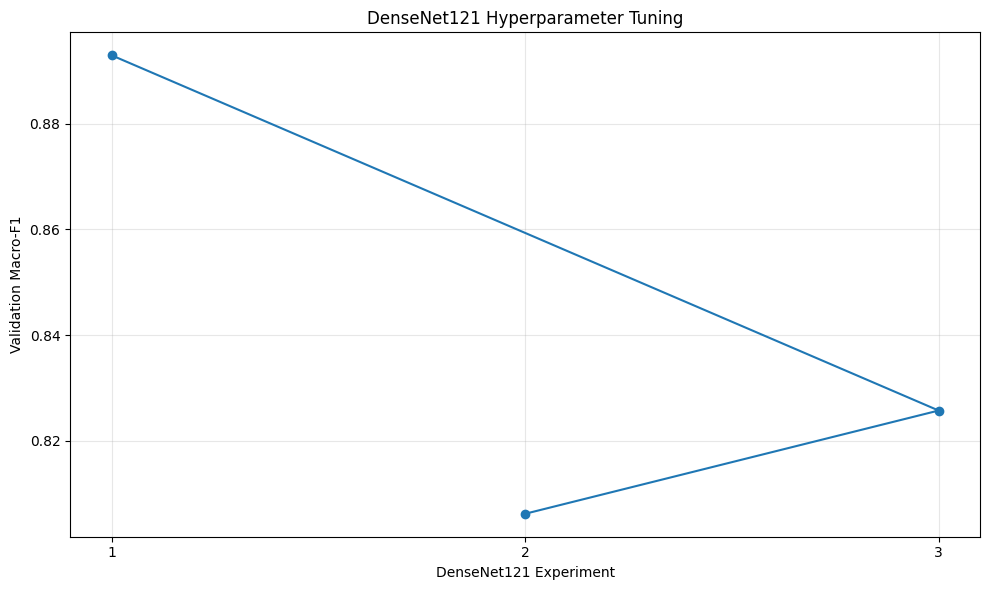



BEST DENSENET121 VALIDATION PERFORMANCE
Accuracy: 0.9148
Precision: 0.8903
Recall: 0.8958
Macro-F1: 0.8930
Balanced Accuracy: 0.8958
Loss: 0.2770

Best DenseNet121 model saved:
/kaggle/working/fetal_project/checkpoints/best_densenet121_model.pth


PART 04 COMPLETED
Model           : DenseNet121
Tuning          : YES
Tuning stage    : During DenseNet121 training
Validation used : YES
Test used       : NO
Best Macro-F1   : 0.893
Best checkpoint : /kaggle/working/fetal_project/checkpoints/best_densenet121_model.pth

Ready for PART 05 — DINOv2 + hyperparameter tuning.


In [5]:
# ============================================================
# FETAL ULTRASOUND CLASSIFICATION PROJECT
# PART 04 — DENSENET121 + HYPERPARAMETER TUNING
# ============================================================

import os
import gc
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. DEVICE
# ============================================================

# If you previously received:
# CUDA error: no kernel image is available for execution
#
# change this to:
# FORCE_CPU = True

FORCE_CPU = False

if FORCE_CPU:
    DEVICE = torch.device("cpu")
else:
    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

print("=" * 70)
print("PART 04 — DENSENET121 + HYPERPARAMETER TUNING")
print("=" * 70)

print("\nDevice:", DEVICE)


# ============================================================
# 3. CHECK PART 02 VARIABLES
# ============================================================

required_variables = [
    "train_loader",
    "val_loader",
    "classes",
    "idx_to_class",
    "PROJECT_DIR"
]

for variable in required_variables:

    if variable not in globals():

        raise RuntimeError(
            f"{variable} is missing. "
            f"Please run PART 02 first."
        )


NUM_CLASSES = len(classes)

print(
    "Number of classes:",
    NUM_CLASSES
)

print(
    "Classes:",
    classes
)


# ============================================================
# 4. DENSENET121 MODEL
# ============================================================

class DenseNet121Classifier(nn.Module):

    def __init__(
        self,
        num_classes,
        dropout=0.2
    ):

        super().__init__()

        # ----------------------------------------------------
        # weights=None
        #
        # This avoids downloading pretrained weights from
        # the internet and prevents Kaggle network errors.
        # ----------------------------------------------------

        self.backbone = models.densenet121(
            weights=None
        )

        in_features = (
            self.backbone.classifier.in_features
        )

        self.backbone.classifier = nn.Sequential(

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                in_features,
                num_classes
            )
        )


    def forward(self, x):

        return self.backbone(x)


# ============================================================
# 5. METRIC FUNCTION
# ============================================================

def calculate_densenet_metrics(
    y_true,
    y_pred
):

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro-F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            )
    }


# ============================================================
# 6. VALIDATION FUNCTION
# ============================================================

def validate_densenet(
    model,
    loader
):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )


    metrics = calculate_densenet_metrics(
        all_labels,
        all_predictions
    )

    metrics["Loss"] = (
        total_loss /
        len(loader)
    )

    return (
        metrics,
        np.array(all_labels),
        np.array(all_predictions)
    )


# ============================================================
# 7. DENSENET121 TRAINING FUNCTION
# ============================================================

def train_densenet(
    learning_rate,
    weight_decay,
    dropout,
    epochs,
    experiment_number
):

    print("\n")
    print("=" * 70)

    print(
        f"DenseNet121 EXPERIMENT {experiment_number}"
    )

    print("=" * 70)

    print(
        "Learning rate :",
        learning_rate
    )

    print(
        "Weight decay  :",
        weight_decay
    )

    print(
        "Dropout       :",
        dropout
    )

    print(
        "Epochs        :",
        epochs
    )


    # --------------------------------------------------------
    # CREATE MODEL
    # --------------------------------------------------------

    model = DenseNet121Classifier(

        num_classes=NUM_CLASSES,

        dropout=dropout
    )

    model = model.to(
        DEVICE
    )


    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = optim.AdamW(

        model.parameters(),

        lr=learning_rate,

        weight_decay=weight_decay
    )


    # --------------------------------------------------------
    # LEARNING RATE SCHEDULER
    # --------------------------------------------------------

    scheduler = optim.lr_scheduler.CosineAnnealingLR(

        optimizer,

        T_max=epochs
    )


    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    checkpoint_path = os.path.join(

        PROJECT_DIR,

        "checkpoints",

        f"densenet_tuning_{experiment_number}.pth"
    )


    best_macro_f1 = -1.0

    history = []


    # ========================================================
    # TRAINING LOOP
    # ========================================================

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        correct = 0

        total = 0


        for images, labels in train_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )


            # ------------------------------------------------
            # RESET GRADIENTS
            # ------------------------------------------------

            optimizer.zero_grad(
                set_to_none=True
            )


            # ------------------------------------------------
            # FORWARD PASS
            # ------------------------------------------------

            outputs = model(
                images
            )


            # ------------------------------------------------
            # LOSS
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )


            # ------------------------------------------------
            # BACKPROPAGATION
            # ------------------------------------------------

            loss.backward()


            # ------------------------------------------------
            # UPDATE PARAMETERS
            # ------------------------------------------------

            optimizer.step()


            # ------------------------------------------------
            # TRAINING STATISTICS
            # ------------------------------------------------

            running_loss += (
                loss.item()
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += (
                labels.size(0)
            )


        # ----------------------------------------------------
        # UPDATE LEARNING RATE
        # ----------------------------------------------------

        scheduler.step()


        # ----------------------------------------------------
        # TRAINING ACCURACY
        # ----------------------------------------------------

        train_accuracy = (
            correct / total
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        val_metrics, _, _ = validate_densenet(

            model,

            val_loader
        )


        # ----------------------------------------------------
        # STORE HISTORY
        # ----------------------------------------------------

        epoch_record = {

            "Experiment":
                experiment_number,

            "Epoch":
                epoch + 1,

            "Train Loss":
                running_loss /
                len(train_loader),

            "Train Accuracy":
                train_accuracy,

            "Val Loss":
                val_metrics["Loss"],

            "Val Accuracy":
                val_metrics["Accuracy"],

            "Val Precision":
                val_metrics["Precision"],

            "Val Recall":
                val_metrics["Recall"],

            "Val Macro-F1":
                val_metrics["Macro-F1"],

            "Val Balanced Accuracy":
                val_metrics[
                    "Balanced Accuracy"
                ]
        }

        history.append(
            epoch_record
        )


        # ----------------------------------------------------
        # DISPLAY EPOCH RESULTS
        # ----------------------------------------------------

        print(

            f"Epoch {epoch + 1:02d}/{epochs} | "

            f"Train Loss: "
            f"{epoch_record['Train Loss']:.4f} | "

            f"Train Acc: "
            f"{train_accuracy:.4f} | "

            f"Val Acc: "
            f"{val_metrics['Accuracy']:.4f} | "

            f"Val Macro-F1: "
            f"{val_metrics['Macro-F1']:.4f}"
        )


        # ----------------------------------------------------
        # SAVE BEST CHECKPOINT
        # ----------------------------------------------------

        if (
            val_metrics["Macro-F1"]
            >
            best_macro_f1
        ):

            best_macro_f1 = (
                val_metrics["Macro-F1"]
            )

            torch.save(

                {

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer.state_dict(),

                    "scheduler_state_dict":
                        scheduler.state_dict(),

                    "epoch":
                        epoch + 1,

                    "best_macro_f1":
                        best_macro_f1,

                    "learning_rate":
                        learning_rate,

                    "weight_decay":
                        weight_decay,

                    "dropout":
                        dropout

                },

                checkpoint_path
            )


    # ========================================================
    # LOAD BEST CHECKPOINT
    # ========================================================

    checkpoint = torch.load(

        checkpoint_path,

        map_location=DEVICE
    )

    model.load_state_dict(

        checkpoint[
            "model_state_dict"
        ]
    )


    # ========================================================
    # BEST VALIDATION PERFORMANCE
    # ========================================================

    final_metrics, _, _ = validate_densenet(

        model,

        val_loader
    )


    return (
        model,
        pd.DataFrame(history),
        final_metrics,
        checkpoint_path
    )


# ============================================================
# 8. HYPERPARAMETER SEARCH
# ============================================================

# Hyperparameters tuned DURING DenseNet121 training:
#
# 1. Learning Rate
# 2. Weight Decay
# 3. Dropout

DENSENET_HYPERPARAMETERS = [

    {
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "dropout": 0.2
    },

    {
        "learning_rate": 5e-5,
        "weight_decay": 1e-4,
        "dropout": 0.3
    },

    {
        "learning_rate": 1e-4,
        "weight_decay": 1e-5,
        "dropout": 0.4
    }

]


# ============================================================
# 9. TRAIN ALL DENSENET CONFIGURATIONS
# ============================================================

DENSENET_EPOCHS = 3

densenet_results = []

densenet_histories = {}

densenet_checkpoints = {}


for experiment_number, hp in enumerate(

    DENSENET_HYPERPARAMETERS,

    start=1

):

    model = None

    try:

        (
            model,
            history,
            metrics,
            checkpoint_path

        ) = train_densenet(

            learning_rate=
                hp["learning_rate"],

            weight_decay=
                hp["weight_decay"],

            dropout=
                hp["dropout"],

            epochs=
                DENSENET_EPOCHS,

            experiment_number=
                experiment_number
        )


        # ----------------------------------------------------
        # SAVE HISTORY
        # ----------------------------------------------------

        densenet_histories[
            experiment_number
        ] = history


        # ----------------------------------------------------
        # SAVE CHECKPOINT PATH
        # ----------------------------------------------------

        densenet_checkpoints[
            experiment_number
        ] = checkpoint_path


        # ----------------------------------------------------
        # SAVE RESULT
        # ----------------------------------------------------

        densenet_results.append({

            "Experiment":
                experiment_number,

            "Learning Rate":
                hp["learning_rate"],

            "Weight Decay":
                hp["weight_decay"],

            "Dropout":
                hp["dropout"],

            "Accuracy":
                metrics["Accuracy"],

            "Precision":
                metrics["Precision"],

            "Recall":
                metrics["Recall"],

            "Macro-F1":
                metrics["Macro-F1"],

            "Balanced Accuracy":
                metrics[
                    "Balanced Accuracy"
                ]

        })


    finally:

        if model is not None:

            del model

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()


# ============================================================
# 10. DENSENET RESULTS TABLE
# ============================================================

densenet_results_df = pd.DataFrame(
    densenet_results
)

densenet_results_df = (
    densenet_results_df
    .sort_values(
        "Macro-F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print("=" * 70)
print("DENSENET121 HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

display(
    densenet_results_df
)


# ============================================================
# 11. SELECT BEST CONFIGURATION
# ============================================================

best_densenet_row = (
    densenet_results_df.iloc[0]
)

best_densenet_experiment = int(
    best_densenet_row[
        "Experiment"
    ]
)

best_densenet_hp = {

    "learning_rate":
        float(
            best_densenet_row[
                "Learning Rate"
            ]
        ),

    "weight_decay":
        float(
            best_densenet_row[
                "Weight Decay"
            ]
        ),

    "dropout":
        float(
            best_densenet_row[
                "Dropout"
            ]
        )
}


print("\n")
print("=" * 70)
print("BEST DENSENET121 CONFIGURATION")
print("=" * 70)

print(
    "Experiment:",
    best_densenet_experiment
)

print(
    "Learning Rate:",
    best_densenet_hp[
        "learning_rate"
    ]
)

print(
    "Weight Decay:",
    best_densenet_hp[
        "weight_decay"
    ]
)

print(
    "Dropout:",
    best_densenet_hp[
        "dropout"
    ]
)

print(
    "Validation Accuracy:",
    best_densenet_row[
        "Accuracy"
    ]
)

print(
    "Validation Macro-F1:",
    best_densenet_row[
        "Macro-F1"
    ]
)


# ============================================================
# 12. SAVE RESULTS
# ============================================================

densenet_results_path = os.path.join(

    PROJECT_DIR,

    "results",

    "densenet_hyperparameter_results.csv"
)

densenet_results_df.to_csv(

    densenet_results_path,

    index=False
)


# ============================================================
# 13. SAVE BEST CONFIGURATION
# ============================================================

best_densenet_info = {

    "model":
        "DenseNet121",

    "experiment":
        best_densenet_experiment,

    "learning_rate":
        best_densenet_hp[
            "learning_rate"
        ],

    "weight_decay":
        best_densenet_hp[
            "weight_decay"
        ],

    "dropout":
        best_densenet_hp[
            "dropout"
        ],

    "validation_accuracy":
        float(
            best_densenet_row[
                "Accuracy"
            ]
        ),

    "validation_precision":
        float(
            best_densenet_row[
                "Precision"
            ]
        ),

    "validation_recall":
        float(
            best_densenet_row[
                "Recall"
            ]
        ),

    "validation_macro_f1":
        float(
            best_densenet_row[
                "Macro-F1"
            ]
        ),

    "validation_balanced_accuracy":
        float(
            best_densenet_row[
                "Balanced Accuracy"
            ]
        ),

    "checkpoint":
        densenet_checkpoints[
            best_densenet_experiment
        ]
}


with open(

    os.path.join(

        PROJECT_DIR,

        "results",

        "best_densenet_config.json"

    ),

    "w"

) as f:

    json.dump(

        best_densenet_info,

        f,

        indent=4
    )


# ============================================================
# 14. PLOT TUNING RESULTS
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(

    densenet_results_df[
        "Experiment"
    ],

    densenet_results_df[
        "Macro-F1"
    ],

    marker="o"
)

plt.xlabel(
    "DenseNet121 Experiment"
)

plt.ylabel(
    "Validation Macro-F1"
)

plt.title(
    "DenseNet121 Hyperparameter Tuning"
)

plt.xticks(
    densenet_results_df[
        "Experiment"
    ]
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 15. LOAD BEST DENSENET121
# ============================================================

best_densenet_model = DenseNet121Classifier(

    num_classes=NUM_CLASSES,

    dropout=
        best_densenet_hp[
            "dropout"
        ]
)

best_densenet_model = (
    best_densenet_model.to(
        DEVICE
    )
)


best_densenet_checkpoint = (
    densenet_checkpoints[
        best_densenet_experiment
    ]
)


checkpoint = torch.load(

    best_densenet_checkpoint,

    map_location=DEVICE
)


best_densenet_model.load_state_dict(

    checkpoint[
        "model_state_dict"
    ]
)


best_densenet_model.eval()


# ============================================================
# 16. FINAL BEST DENSENET VALIDATION
# ============================================================

best_densenet_metrics, _, _ = (
    validate_densenet(

        best_densenet_model,

        val_loader
    )
)


print("\n")
print("=" * 70)
print("BEST DENSENET121 VALIDATION PERFORMANCE")
print("=" * 70)

for metric, value in (
    best_densenet_metrics.items()
):

    print(
        f"{metric}: {value:.4f}"
    )


# ============================================================
# 17. SAVE BEST MODEL
# ============================================================

final_densenet_checkpoint = os.path.join(

    PROJECT_DIR,

    "checkpoints",

    "best_densenet121_model.pth"
)


torch.save(

    {

        "model_state_dict":
            best_densenet_model.state_dict(),

        "model_name":
            "DenseNet121",

        "num_classes":
            NUM_CLASSES,

        "classes":
            classes,

        "hyperparameters":
            best_densenet_hp,

        "validation_metrics":
            best_densenet_metrics

    },

    final_densenet_checkpoint
)


print(
    "\nBest DenseNet121 model saved:"
)

print(
    final_densenet_checkpoint
)


# ============================================================
# 18. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 70)
print("PART 04 COMPLETED")
print("=" * 70)

print(
    "Model           : DenseNet121"
)

print(
    "Tuning          : YES"
)

print(
    "Tuning stage    : During DenseNet121 training"
)

print(
    "Validation used : YES"
)

print(
    "Test used       : NO"
)

print(
    "Best Macro-F1   :",
    round(
        best_densenet_metrics[
            "Macro-F1"
        ],
        4
    )
)

print(
    "Best checkpoint :",
    final_densenet_checkpoint
)

print(
    "\nReady for PART 05 — DINOv2 + hyperparameter tuning."
)

In [6]:
# ============================================================
# PART 05 — DINOv2 ViT-B/14
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. SETTINGS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"

TRAIN_CSV = os.path.join(
    PROJECT_DIR, "train.csv"
)

VAL_CSV = os.path.join(
    PROJECT_DIR, "val.csv"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR, "results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

SEED = 42
IMG_SIZE = 224
NUM_WORKERS = 2

# Set True only if your GPU gives:
# CUDA error: no kernel image is available

FORCE_CPU = False


# ============================================================
# 2. DEVICE
# ============================================================

if FORCE_CPU:
    DEVICE = torch.device("cpu")

elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")

else:
    DEVICE = torch.device("cpu")


print("=" * 65)
print("DINOv2 ViT-B/14")
print("=" * 65)

print("Device:", DEVICE)


# ============================================================
# 3. SEED
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available() and not FORCE_CPU:
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 4. LOAD DATA
# ============================================================

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

print("\nTrain shape:",
      train_df.shape)

print(
    "Validation shape:",
    val_df.shape
)

print(
    "\nColumns:"
)

print(
    train_df.columns.tolist()
)


# ============================================================
# 5. USE YOUR ACTUAL COLUMNS
# ============================================================

IMAGE_COLUMN = "image_path"
LABEL_COLUMN = "label"


if IMAGE_COLUMN not in train_df.columns:
    raise ValueError(
        f"{IMAGE_COLUMN} not found in train.csv"
    )

if LABEL_COLUMN not in train_df.columns:
    raise ValueError(
        f"{LABEL_COLUMN} not found in train.csv"
    )


# ============================================================
# 6. REMOVE INVALID ROWS
# ============================================================

train_df = train_df.dropna(
    subset=[
        IMAGE_COLUMN,
        LABEL_COLUMN
    ]
).reset_index(drop=True)

val_df = val_df.dropna(
    subset=[
        IMAGE_COLUMN,
        LABEL_COLUMN
    ]
).reset_index(drop=True)


# ============================================================
# 7. LABEL INFORMATION
# ============================================================

# Your CSV already contains numerical labels.
# Therefore, DO NOT recreate the labels.

train_df["label"] = train_df[
    LABEL_COLUMN
].astype(int)

val_df["label"] = val_df[
    LABEL_COLUMN
].astype(int)


NUM_CLASSES = len(
    train_df["label"].unique()
)

print(
    "\nNumber of classes:",
    NUM_CLASSES
)

print(
    "Labels:",
    sorted(
        train_df["label"].unique()
    )
)


# ============================================================
# 8. CLASS NAMES
# ============================================================

class_names = {}

for label in sorted(
    train_df["label"].unique()
):

    rows = train_df[
        train_df["label"] == label
    ]

    if "Plane" in train_df.columns:

        class_names[label] = str(
            rows["Plane"].iloc[0]
        )

    else:

        class_names[label] = str(
            label
        )


print("\nClass mapping:")

for label, name in class_names.items():

    print(
        f"{label} -> {name}"
    )


# ============================================================
# 9. VERIFY IMAGE FILES
# ============================================================

missing_train = sum(
    not os.path.isfile(str(path))
    for path in train_df[
        IMAGE_COLUMN
    ]
)

missing_val = sum(
    not os.path.isfile(str(path))
    for path in val_df[
        IMAGE_COLUMN
    ]
)


print(
    "\nMissing train images:",
    missing_train
)

print(
    "Missing validation images:",
    missing_val
)


if missing_train > 0:
    raise FileNotFoundError(
        "Training image paths are invalid."
    )

if missing_val > 0:
    raise FileNotFoundError(
        "Validation image paths are invalid."
    )


# ============================================================
# 10. DINOv2 PREPROCESSING
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )

])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )

])


# ============================================================
# 11. DATASET
# ============================================================

class FetalDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = str(
            row[IMAGE_COLUMN]
        )

        label = int(
            row["label"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(
            image
        )

        return image, label


# ============================================================
# 12. DINOv2 MODEL
# ============================================================

print(
    "\nLoading DINOv2 ViT-B/14..."
)

try:

    dinov2 = torch.hub.load(
        "facebookresearch/dinov2",
        "dinov2_vitb14"
    )

except Exception as e:

    raise RuntimeError(

        "\nCould not load DINOv2 ViT-B/14.\n\n"

        "In Kaggle, enable:\n"
        "Settings → Internet → On\n\n"

        "Then restart and run this cell again.\n\n"

        f"Original error:\n{e}"

    )


print(
    "DINOv2 loaded successfully."
)


# ============================================================
# 13. DINOv2 FEATURE SIZE
# ============================================================

FEATURE_DIM = 768

print(
    "DINOv2 feature dimension:",
    FEATURE_DIM
)


# ============================================================
# 14. FREEZE DINOv2
# ============================================================

dinov2 = dinov2.to(
    DEVICE
)

dinov2.eval()


for parameter in dinov2.parameters():

    parameter.requires_grad = False


print(
    "DINOv2 backbone frozen."
)


# ============================================================
# 15. CLASSIFIER
# ============================================================

class DINOv2Classifier(
    nn.Module
):

    def __init__(
        self,
        backbone,
        feature_dim,
        num_classes,
        dropout
    ):

        super().__init__()

        self.backbone = backbone

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            feature_dim,
            num_classes
        )


    def forward(self, x):

        with torch.no_grad():

            features = self.backbone(
                x
            )

        features = self.dropout(
            features
        )

        output = self.classifier(
            features
        )

        return output


# ============================================================
# 16. HYPERPARAMETER CONFIGURATIONS
# ============================================================

configs = [

    {
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "dropout": 0.2,
        "batch_size": 16
    },

    {
        "learning_rate": 5e-4,
        "weight_decay": 1e-4,
        "dropout": 0.3,
        "batch_size": 16
    },

    {
        "learning_rate": 1e-4,
        "weight_decay": 1e-5,
        "dropout": 0.5,
        "batch_size": 16
    }

]


print(
    "\nDINOv2 hyperparameter configurations:"
)

for i, config in enumerate(
    configs,
    start=1
):

    print(
        f"Config {i}: "
        f"LR={config['learning_rate']} | "
        f"WD={config['weight_decay']} | "
        f"Dropout={config['dropout']} | "
        f"Batch={config['batch_size']}"
    )


# ============================================================
# 17. TRAIN ONE CONFIGURATION
# ============================================================

def train_config(
    config,
    epochs=3
):

    train_loader = DataLoader(

        FetalDataset(
            train_df,
            train_transform
        ),

        batch_size=config[
            "batch_size"
        ],

        shuffle=True,

        num_workers=NUM_WORKERS,

        pin_memory=False

    )


    val_loader = DataLoader(

        FetalDataset(
            val_df,
            val_transform
        ),

        batch_size=config[
            "batch_size"
        ],

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=False

    )


    model = DINOv2Classifier(

        backbone=dinov2,

        feature_dim=FEATURE_DIM,

        num_classes=NUM_CLASSES,

        dropout=config[
            "dropout"
        ]

    ).to(DEVICE)


    criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.AdamW(

        model.classifier.parameters(),

        lr=config[
            "learning_rate"
        ],

        weight_decay=config[
            "weight_decay"
        ]

    )


    best_f1 = -1

    best_accuracy = 0

    best_state = None


    # ========================================================
    # EPOCHS
    # ========================================================

    for epoch in range(epochs):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.train()

        model.backbone.eval()


        train_preds = []

        train_targets = []

        running_loss = 0.0


        progress = tqdm(

            train_loader,

            desc=(
                f"Epoch "
                f"{epoch + 1}/{epochs}"
            ),

            leave=False

        )


        for images, labels in progress:

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )


            optimizer.zero_grad()


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            loss.backward()


            optimizer.step()


            running_loss += (
                loss.item()
            )


            preds = torch.argmax(
                outputs,
                dim=1
            )


            train_preds.extend(
                preds.detach()
                .cpu()
                .numpy()
            )

            train_targets.extend(
                labels.detach()
                .cpu()
                .numpy()
            )


        train_acc = accuracy_score(
            train_targets,
            train_preds
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        model.eval()

        val_preds = []

        val_targets = []

        val_loss = 0.0


        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(
                    DEVICE
                )

                labels = labels.to(
                    DEVICE
                )


                outputs = model(
                    images
                )


                loss = criterion(
                    outputs,
                    labels
                )


                val_loss += loss.item()


                preds = torch.argmax(
                    outputs,
                    dim=1
                )


                val_preds.extend(
                    preds.cpu()
                    .numpy()
                )

                val_targets.extend(
                    labels.cpu()
                    .numpy()
                )


        val_acc = accuracy_score(
            val_targets,
            val_preds
        )


        val_f1 = f1_score(
            val_targets,
            val_preds,
            average="macro"
        )


        print(

            f"Epoch {epoch + 1}/{epochs} | "

            f"Train Loss: "
            f"{running_loss / len(train_loader):.4f} | "

            f"Train Acc: "
            f"{train_acc:.4f} | "

            f"Val Loss: "
            f"{val_loss / len(val_loader):.4f} | "

            f"Val Acc: "
            f"{val_acc:.4f} | "

            f"Val Macro-F1: "
            f"{val_f1:.4f}"

        )


        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_accuracy = val_acc

            best_state = {

                "model_state_dict":
                    model.state_dict(),

                "config":
                    config,

                "val_macro_f1":
                    val_f1,

                "val_accuracy":
                    val_acc

            }


    del model

    del train_loader

    del val_loader

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return (
        best_f1,
        best_accuracy,
        best_state
    )


# ============================================================
# 18. HYPERPARAMETER TUNING
# ============================================================

results = []

best_f1 = -1

best_accuracy = 0

best_state = None

best_config = None


for config_number, config in enumerate(
    configs,
    start=1
):

    print("\n")

    print("=" * 65)

    print(
        f"DINOv2 CONFIGURATION "
        f"{config_number}/{len(configs)}"
    )

    print("=" * 65)


    current_f1, current_accuracy, current_state = (

        train_config(
            config,
            epochs=3
        )

    )


    results.append({

        "Configuration":
            config_number,

        "Learning_Rate":
            config[
                "learning_rate"
            ],

        "Weight_Decay":
            config[
                "weight_decay"
            ],

        "Dropout":
            config[
                "dropout"
            ],

        "Batch_Size":
            config[
                "batch_size"
            ],

        "Validation_Accuracy":
            current_accuracy,

        "Validation_Macro_F1":
            current_f1

    })


    if current_f1 > best_f1:

        best_f1 = current_f1

        best_accuracy = current_accuracy

        best_state = current_state

        best_config = config


# ============================================================
# 19. RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "Validation_Macro_F1",
    ascending=False
).reset_index(
    drop=True
)


print("\n")

print("=" * 65)

print(
    "DINOv2 TUNING RESULTS"
)

print("=" * 65)

display(
    results_df
)


# ============================================================
# 20. SAVE RESULTS
# ============================================================

results_path = os.path.join(

    RESULTS_DIR,

    "DINOv2_tuning_results.csv"

)

results_df.to_csv(
    results_path,
    index=False
)


# ============================================================
# 21. SAVE BEST MODEL
# ============================================================

best_model_path = os.path.join(

    PROJECT_DIR,

    "DINOv2_ViT_B14_best.pth"

)


torch.save(

    {

        "model_state_dict":
            best_state[
                "model_state_dict"
            ],

        "architecture":
            "DINOv2 ViT-B/14",

        "feature_dimension":
            FEATURE_DIM,

        "num_classes":
            NUM_CLASSES,

        "classes":
            class_names,

        "best_config":
            best_config,

        "validation_accuracy":
            best_accuracy,

        "validation_macro_f1":
            best_f1

    },

    best_model_path

)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n")

print("=" * 65)

print(
    "PART 05 COMPLETED"
)

print("=" * 65)

print(
    "\nModel: DINOv2 ViT-B/14"
)

print(
    "Feature Dimension:",
    FEATURE_DIM
)

print(
    "Best Learning Rate:",
    best_config[
        "learning_rate"
    ]
)

print(
    "Best Weight Decay:",
    best_config[
        "weight_decay"
    ]
)

print(
    "Best Dropout:",
    best_config[
        "dropout"
    ]
)

print(
    "Best Batch Size:",
    best_config[
        "batch_size"
    ]
)

print(
    "Best Validation Accuracy:",
    f"{best_accuracy:.4f}"
)

print(
    "Best Validation Macro-F1:",
    f"{best_f1:.4f}"
)

print(
    "\nBest model saved at:"
)

print(
    best_model_path
)

print(
    "\nTuning results saved at:"
)

print(
    results_path
)

DINOv2 ViT-B/14
Device: cuda

Train shape: (9068, 9)
Validation shape: (1644, 9)

Columns:
['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train ', 'image_path', 'label']

Number of classes: 6
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Class mapping:
0 -> Fetal abdomen
1 -> Fetal brain
2 -> Fetal femur
3 -> Fetal thorax
4 -> Maternal cervix
5 -> Other

Missing train images: 0
Missing validation images: 0

Loading DINOv2 ViT-B/14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 436MB/s] 


DINOv2 loaded successfully.
DINOv2 feature dimension: 768
DINOv2 backbone frozen.

DINOv2 hyperparameter configurations:
Config 1: LR=0.001 | WD=0.0001 | Dropout=0.2 | Batch=16
Config 2: LR=0.0005 | WD=0.0001 | Dropout=0.3 | Batch=16
Config 3: LR=0.0001 | WD=1e-05 | Dropout=0.5 | Batch=16


DINOv2 CONFIGURATION 1/3


Epoch 1/3:   0%|          | 0/567 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 0.7177 | Train Acc: 0.7438 | Val Loss: 0.5120 | Val Acc: 0.8181 | Val Macro-F1: 0.7659


...

Epoch 2/3 | Train Loss: 1.0607 | Train Acc: 0.6065 | Val Loss: 0.8256 | Val Acc: 0.7451 | Val Macro-F1: 0.5904


Epoch 3/3:   0%|          | 0/567 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 0.8689 | Train Acc: 0.6877 | Val Loss: 0.7154 | Val Acc: 0.7822 | Val Macro-F1: 0.6852


DINOv2 TUNING RESULTS


,Configuration,Learning_Rate,Weight_Decay,Dropout,Batch_Size,Validation_Accuracy,Validation_Macro_F1
0,1,0.0010,0.00010,0.2,16,0.861922,0.826914
1,2,0.0005,0.00010,0.3,16,0.844282,0.804512
2,3,0.0001,0.00001,0.5,16,0.782238,0.685231




PART 05 COMPLETED

Model: DINOv2 ViT-B/14
Feature Dimension: 768
Best Learning Rate: 0.001
Best Weight Decay: 0.0001
Best Dropout: 0.2
Best Batch Size: 16
Best Validation Accuracy: 0.8619
Best Validation Macro-F1: 0.8269

Best model saved at:
/kaggle/working/fetal_project/DINOv2_ViT_B14_best.pth

Tuning results saved at:
/kaggle/working/fetal_project/results/DINOv2_tuning_results.csv


PART 06 — DEEP MODEL COMPARISON

CSV files available in project:
 - /kaggle/working/fetal_project/results/DINOv2_tuning_results.csv
 - /kaggle/working/fetal_project/results/densenet_hyperparameter_results.csv
 - /kaggle/working/fetal_project/results/vit_hyperparameter_results.csv

Detected result files:
ViT: /kaggle/working/fetal_project/results/vit_hyperparameter_results.csv
DenseNet121: /kaggle/working/fetal_project/results/densenet_hyperparameter_results.csv
DINOv2: /kaggle/working/fetal_project/results/DINOv2_tuning_results.csv

ViT RESULT TABLE


,Experiment,Learning Rate,Weight Decay,Dropout,Accuracy,Precision,Recall,Macro-F1,Balanced Accuracy
0,2,0.00005,0.00010,0.3,0.714720,0.576081,0.603392,0.579374,0.603392
1,1,0.00010,0.00010,0.2,0.694039,0.565888,0.572733,0.562932,0.572733
2,3,0.00010,0.00001,0.3,0.676399,0.581328,0.527721,0.519527,0.527721



DenseNet121 RESULT TABLE


,Experiment,Learning Rate,Weight Decay,Dropout,Accuracy,Precision,Recall,Macro-F1,Balanced Accuracy
0,1,0.00010,0.00010,0.2,0.914842,0.890270,0.895829,0.892976,0.895829
1,3,0.00010,0.00001,0.4,0.869221,0.843803,0.818858,0.825727,0.818858
2,2,0.00005,0.00010,0.3,0.873479,0.865183,0.806027,0.806181,0.806027



DINOv2 RESULT TABLE


,Configuration,Learning_Rate,Weight_Decay,Dropout,Batch_Size,Validation_Accuracy,Validation_Macro_F1
0,1,0.0010,0.00010,0.2,16,0.861922,0.826914
1,2,0.0005,0.00010,0.3,16,0.844282,0.804512
2,3,0.0001,0.00001,0.5,16,0.782238,0.685231



DEEP MODEL COMPARISON


,Rank,Model,Best Macro-F1,Accuracy,Best Configuration,Learning Rate,Weight Decay,Dropout,Precision,Recall,Balanced Accuracy,Learning_Rate,Weight_Decay,Batch_Size
0,1,DenseNet121,0.892976,0.914842,1.0,0.00010,0.0001,0.2,0.890270,0.895829,0.895829,NaN,NaN,NaN
1,2,DINOv2 ViT-B/14,0.826914,0.861922,1.0,NaN,NaN,0.2,NaN,NaN,NaN,0.001,0.0001,16.0
2,3,ViT,0.579374,0.714720,2.0,0.00005,0.0001,0.3,0.576081,0.603392,0.603392,NaN,NaN,NaN



BEST DEEP MODEL

Model       : DenseNet121
Macro-F1    : 0.892976
Accuracy    : 0.914842
Configuration: 1.0


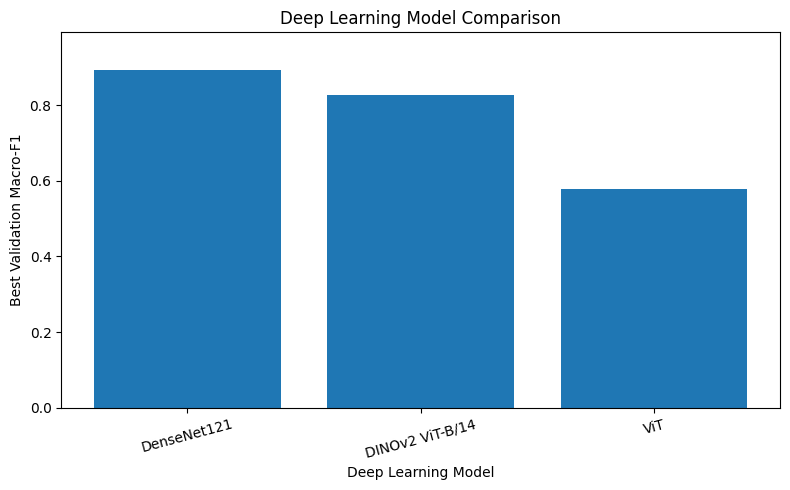


FINAL MODEL RANKING
1. DenseNet121 → Macro-F1 = 0.892976
2. DINOv2 ViT-B/14 → Macro-F1 = 0.826914
3. ViT → Macro-F1 = 0.579374

PART 06 COMPLETED SUCCESSFULLY

Best Deep Model:
DenseNet121

Saved outputs:
1. /kaggle/working/fetal_project/results/deep_model_comparison.csv
2. /kaggle/working/fetal_project/results/best_deep_model.csv
3. /kaggle/working/fetal_project/results/BEST_DEEP_MODEL.txt
4. /kaggle/working/fetal_project/results/deep_model_comparison.png

Next:
PART 07 — FEATURE EXTRACTION FROM THE BEST DEEP MODEL


In [12]:
# ============================================================
# PART 06 — DEEP MODEL COMPARISON
# ============================================================

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. PROJECT DIRECTORIES
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 70)
print("PART 06 — DEEP MODEL COMPARISON")
print("=" * 70)


# ============================================================
# 2. FIND ALL RESULT CSV FILES
# ============================================================

all_csvs = glob.glob(
    os.path.join(RESULTS_DIR, "*.csv")
)

print("\nCSV files available in project:")

for file in all_csvs:
    print(" -", file)


# ============================================================
# 3. FIND MODEL RESULT FILES
# ============================================================

def find_file(keywords):

    matches = []

    for file in all_csvs:

        filename = os.path.basename(file).lower()

        for keyword in keywords:

            if keyword.lower() in filename:
                matches.append(file)
                break

    if len(matches) == 0:
        return None

    # Prefer hyperparameter/tuning result files
    preferred = [
        f for f in matches
        if "hyperparameter" in os.path.basename(f).lower()
        or "tuning" in os.path.basename(f).lower()
    ]

    if len(preferred) > 0:
        return preferred[0]

    return matches[0]


vit_file = find_file([
    "vit_hyperparameter",
    "vit_tuning",
    "vit"
])

densenet_file = find_file([
    "densenet_hyperparameter",
    "densenet_tuning",
    "densenet"
])

dino_file = find_file([
    "dinov2_tuning",
    "dinov2",
    "dino"
])


# ============================================================
# 4. PRINT DETECTED FILES
# ============================================================

print("\nDetected result files:")

print(
    "ViT:",
    vit_file if vit_file else "NOT FOUND"
)

print(
    "DenseNet121:",
    densenet_file if densenet_file else "NOT FOUND"
)

print(
    "DINOv2:",
    dino_file if dino_file else "NOT FOUND"
)


# ============================================================
# 5. CHECK REQUIRED FILES
# ============================================================

missing_models = []

if vit_file is None:
    missing_models.append("ViT")

if densenet_file is None:
    missing_models.append("DenseNet121")

if dino_file is None:
    missing_models.append("DINOv2")


if len(missing_models) > 0:

    raise FileNotFoundError(
        "\nMissing tuning result files for: "
        + ", ".join(missing_models)
        + "\n\nPlease run the corresponding model training part."
    )


# ============================================================
# 6. LOAD RESULT CSV FILES
# ============================================================

vit_df = pd.read_csv(vit_file)

densenet_df = pd.read_csv(densenet_file)

dino_df = pd.read_csv(dino_file)


# ============================================================
# 7. CLEAN COLUMN NAMES
# ============================================================

def clean_columns(df):

    df = df.copy()

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
    )

    return df


vit_df = clean_columns(vit_df)

densenet_df = clean_columns(densenet_df)

dino_df = clean_columns(dino_df)


# ============================================================
# 8. DISPLAY ORIGINAL RESULT TABLES
# ============================================================

print("\n" + "=" * 70)
print("ViT RESULT TABLE")
print("=" * 70)

display(vit_df)


print("\n" + "=" * 70)
print("DenseNet121 RESULT TABLE")
print("=" * 70)

display(densenet_df)


print("\n" + "=" * 70)
print("DINOv2 RESULT TABLE")
print("=" * 70)

display(dino_df)


# ============================================================
# 9. FIND MACRO-F1 COLUMN
# ============================================================

def find_macro_f1_column(df):

    # Exact column names used in your project
    possible_columns = [

        "Macro-F1",

        "Macro F1",

        "Macro_F1",

        "macro_f1",

        "macro-f1",

        "Validation_Macro_F1",

        "Validation Macro-F1",

        "Validation Macro F1",

        "Val_Macro_F1",

        "Val Macro-F1"
    ]

    for column in possible_columns:

        if column in df.columns:
            return column


    # Automatic fallback
    for column in df.columns:

        normalized = (
            str(column)
            .lower()
            .replace("_", "")
            .replace("-", "")
            .replace(" ", "")
        )

        if "macrof1" in normalized:

            return column


    return None


# ============================================================
# 10. FIND ACCURACY COLUMN
# ============================================================

def find_accuracy_column(df):

    possible_columns = [

        "Accuracy",

        "accuracy",

        "Validation_Accuracy",

        "Validation Accuracy",

        "Val_Accuracy",

        "Val Accuracy"
    ]

    for column in possible_columns:

        if column in df.columns:
            return column


    # Automatic fallback
    for column in df.columns:

        normalized = (
            str(column)
            .lower()
            .replace("_", "")
            .replace("-", "")
            .replace(" ", "")
        )

        if normalized == "accuracy":

            return column


    return None


# ============================================================
# 11. FIND EXPERIMENT / CONFIGURATION COLUMN
# ============================================================

def find_experiment_column(df):

    possible_columns = [

        "Experiment",

        "Configuration",

        "experiment",

        "configuration"
    ]

    for column in possible_columns:

        if column in df.columns:
            return column

    return None


# ============================================================
# 12. GET BEST MODEL CONFIGURATION
# ============================================================

def get_best_configuration(model_name, df):

    df = df.copy()

    # --------------------------------------------------------
    # Find metric columns
    # --------------------------------------------------------

    macro_f1_column = find_macro_f1_column(df)

    accuracy_column = find_accuracy_column(df)

    experiment_column = find_experiment_column(df)


    # --------------------------------------------------------
    # Check Macro-F1
    # --------------------------------------------------------

    if macro_f1_column is None:

        raise ValueError(
            "\nMacro-F1 column not found for "
            + model_name
            + ".\n\nAvailable columns:\n"
            + str(list(df.columns))
        )


    # --------------------------------------------------------
    # Convert metrics to numeric
    # --------------------------------------------------------

    df[macro_f1_column] = pd.to_numeric(
        df[macro_f1_column],
        errors="coerce"
    )


    if accuracy_column is not None:

        df[accuracy_column] = pd.to_numeric(
            df[accuracy_column],
            errors="coerce"
        )


    # --------------------------------------------------------
    # Remove rows without Macro-F1
    # --------------------------------------------------------

    valid_df = df.dropna(
        subset=[macro_f1_column]
    ).copy()


    if valid_df.empty:

        raise ValueError(
            "No valid Macro-F1 values found for "
            + model_name
        )


    # --------------------------------------------------------
    # SELECT BEST CONFIGURATION
    # Primary metric = Macro-F1
    # --------------------------------------------------------

    best_index = valid_df[
        macro_f1_column
    ].idxmax()

    best_row = valid_df.loc[best_index]


    # --------------------------------------------------------
    # Standardized comparison result
    # --------------------------------------------------------

    result = {

        "Model": model_name,

        "Best Macro-F1":
            float(best_row[macro_f1_column])
    }


    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------

    if accuracy_column is not None:

        result["Accuracy"] = float(
            best_row[accuracy_column]
        )

    else:

        result["Accuracy"] = None


    # --------------------------------------------------------
    # Experiment / Configuration
    # --------------------------------------------------------

    if experiment_column is not None:

        result["Best Configuration"] = (
            best_row[experiment_column]
        )

    else:

        result["Best Configuration"] = "N/A"


    # --------------------------------------------------------
    # Preserve hyperparameter values
    # --------------------------------------------------------

    skip_columns = {

        macro_f1_column,

        accuracy_column,

        experiment_column
    }


    for column in df.columns:

        if column in skip_columns:
            continue

        result[column] = best_row[column]


    return result


# ============================================================
# 13. GET BEST CONFIGURATION FOR EACH MODEL
# ============================================================

vit_best = get_best_configuration(
    "ViT",
    vit_df
)

densenet_best = get_best_configuration(
    "DenseNet121",
    densenet_df
)

dino_best = get_best_configuration(
    "DINOv2 ViT-B/14",
    dino_df
)


# ============================================================
# 14. CREATE COMPARISON DATAFRAME
# ============================================================

comparison_df = pd.DataFrame([

    vit_best,

    densenet_best,

    dino_best
])


# ============================================================
# 15. SORT BY MACRO-F1
# ============================================================

comparison_df = comparison_df.sort_values(

    by="Best Macro-F1",

    ascending=False

).reset_index(drop=True)


# ============================================================
# 16. ADD RANK
# ============================================================

comparison_df.insert(

    0,

    "Rank",

    range(1, len(comparison_df) + 1)
)


# ============================================================
# 17. DISPLAY FINAL COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("DEEP MODEL COMPARISON")
print("=" * 70)

display(comparison_df)


# ============================================================
# 18. SELECT BEST DEEP MODEL
# ============================================================

best_row = comparison_df.iloc[0]

BEST_MODEL_NAME = best_row["Model"]

BEST_MACRO_F1 = float(
    best_row["Best Macro-F1"]
)

BEST_ACCURACY = best_row["Accuracy"]


# ============================================================
# 19. DISPLAY BEST MODEL
# ============================================================

print("\n" + "=" * 70)
print("BEST DEEP MODEL")
print("=" * 70)

print(
    "\nModel       :",
    BEST_MODEL_NAME
)

print(
    "Macro-F1    :",
    f"{BEST_MACRO_F1:.6f}"
)

if pd.notna(BEST_ACCURACY):

    print(
        "Accuracy    :",
        f"{float(BEST_ACCURACY):.6f}"
    )

print(
    "Configuration:",
    best_row["Best Configuration"]
)


# ============================================================
# 20. SAVE MODEL COMPARISON
# ============================================================

comparison_path = os.path.join(

    RESULTS_DIR,

    "deep_model_comparison.csv"
)

comparison_df.to_csv(

    comparison_path,

    index=False
)


# ============================================================
# 21. SAVE BEST MODEL
# ============================================================

best_model_path = os.path.join(

    RESULTS_DIR,

    "best_deep_model.csv"
)

pd.DataFrame([

    best_row

]).to_csv(

    best_model_path,

    index=False
)


# ============================================================
# 22. SAVE BEST MODEL NAME
# ============================================================

best_model_txt = os.path.join(

    RESULTS_DIR,

    "BEST_DEEP_MODEL.txt"
)

with open(best_model_txt, "w") as f:

    f.write(
        f"Best Deep Model: {BEST_MODEL_NAME}\n"
    )

    f.write(
        f"Best Macro-F1: {BEST_MACRO_F1:.6f}\n"
    )

    if pd.notna(BEST_ACCURACY):

        f.write(
            f"Accuracy: {float(BEST_ACCURACY):.6f}\n"
        )

    f.write(
        f"Best Configuration: "
        f"{best_row['Best Configuration']}\n"
    )


# ============================================================
# 23. MACRO-F1 COMPARISON PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(

    comparison_df["Model"],

    comparison_df["Best Macro-F1"]
)

plt.xlabel(
    "Deep Learning Model"
)

plt.ylabel(
    "Best Validation Macro-F1"
)

plt.title(
    "Deep Learning Model Comparison"
)

plt.ylim(

    0,

    min(
        1.0,

        comparison_df[
            "Best Macro-F1"
        ].max() + 0.1
    )
)

plt.xticks(
    rotation=15
)

plt.tight_layout()


plot_path = os.path.join(

    RESULTS_DIR,

    "deep_model_comparison.png"
)

plt.savefig(

    plot_path,

    dpi=300,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# 24. FINAL RANKING
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL RANKING")
print("=" * 70)

for _, row in comparison_df.iterrows():

    print(
        f"{int(row['Rank'])}. "
        f"{row['Model']} "
        f"→ Macro-F1 = "
        f"{float(row['Best Macro-F1']):.6f}"
    )


# ============================================================
# 25. SAVED OUTPUTS
# ============================================================

print("\n" + "=" * 70)
print("PART 06 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nBest Deep Model:")
print(BEST_MODEL_NAME)

print("\nSaved outputs:")

print(
    "1.",
    comparison_path
)

print(
    "2.",
    best_model_path
)

print(
    "3.",
    best_model_txt
)

print(
    "4.",
    plot_path
)

print("\nNext:")
print(
    "PART 07 — FEATURE EXTRACTION "
    "FROM THE BEST DEEP MODEL"
)

In [14]:
# ============================================================
# PART 07 — FEATURE EXTRACTION FROM BEST MODEL
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")

os.makedirs(FEATURE_DIR, exist_ok=True)

# ============================================================
# DEVICE
# ============================================================

FORCE_CPU = False

DEVICE = torch.device(
    "cpu" if FORCE_CPU or not torch.cuda.is_available()
    else "cuda"
)

print("Device:", DEVICE)

# ============================================================
# LOAD BEST MODEL INFORMATION
# ============================================================

best_df = pd.read_csv(
    os.path.join(RESULTS_DIR, "best_deep_model.csv")
)

best_model_name = str(best_df.iloc[0]["Model"])

print("Best model:", best_model_name)

if "DenseNet121" not in best_model_name:
    raise ValueError(
        f"Expected DenseNet121, but found {best_model_name}"
    )

# ============================================================
# FIND DENSENET CHECKPOINT
# ============================================================

pth_files = glob.glob(
    os.path.join(PROJECT_DIR, "**", "*.pth"),
    recursive=True
)

densenet_files = [
    f for f in pth_files
    if "densenet" in os.path.basename(f).lower()
]

if not densenet_files:
    raise FileNotFoundError(
        "DenseNet121 checkpoint not found."
    )

checkpoint_path = densenet_files[0]

print("Checkpoint:", checkpoint_path)

# ============================================================
# LOAD CSV FILES
# ============================================================

train_df = pd.read_csv(
    os.path.join(PROJECT_DIR, "train.csv")
)

val_df = pd.read_csv(
    os.path.join(PROJECT_DIR, "val.csv")
)

test_df = pd.read_csv(
    os.path.join(PROJECT_DIR, "test.csv")
)

# Clean column names
for df in [train_df, val_df, test_df]:
    df.columns = df.columns.astype(str).str.strip()

# ============================================================
# DATASET
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class FetalDataset(Dataset):

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            str(row["image_path"])
        ).convert("RGB")

        image = transform(image)

        label = int(row["label"])

        return image, label


# ============================================================
# DATALOADERS
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    FetalDataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

val_loader = DataLoader(
    FetalDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    FetalDataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# ============================================================
# BUILD DENSENET121
# ============================================================

model = models.densenet121(
    weights=None
)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(
        model.classifier.in_features,
        6
    )
)

# ============================================================
# LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint

# Fix "backbone." prefix if present
if any(
    key.startswith("backbone.")
    for key in state_dict.keys()
):

    state_dict = {
        key.replace("backbone.", "", 1): value
        for key, value in state_dict.items()
    }

model.load_state_dict(
    state_dict,
    strict=True
)

model = model.to(DEVICE)
model.eval()

print("DenseNet121 loaded successfully.")

# ============================================================
# FEATURE EXTRACTOR
# ============================================================

feature_extractor = nn.Sequential(
    model.features,
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d((1, 1))
).to(DEVICE)

feature_extractor.eval()

# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(loader):

    features = []
    labels = []

    with torch.no_grad():

        for images, batch_labels in loader:

            images = images.to(DEVICE)

            batch_features = feature_extractor(
                images
            )

            batch_features = batch_features.view(
                batch_features.size(0),
                -1
            )

            features.append(
                batch_features.cpu().numpy()
            )

            labels.append(
                batch_labels.numpy()
            )

    return (
        np.concatenate(features, axis=0),
        np.concatenate(labels, axis=0)
    )

# ============================================================
# EXTRACT FEATURES
# ============================================================

print("\nExtracting training features...")
X_train, y_train = extract_features(train_loader)

print("Extracting validation features...")
X_val, y_val = extract_features(val_loader)

print("Extracting test features...")
X_test, y_test = extract_features(test_loader)

# ============================================================
# CHECK FEATURE SHAPES
# ============================================================

print("\nFeature shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ============================================================
# SAVE FEATURES
# ============================================================

np.save(
    os.path.join(FEATURE_DIR, "X_train_features.npy"),
    X_train
)

np.save(
    os.path.join(FEATURE_DIR, "y_train_features.npy"),
    y_train
)

np.save(
    os.path.join(FEATURE_DIR, "X_val_features.npy"),
    X_val
)

np.save(
    os.path.join(FEATURE_DIR, "y_val_features.npy"),
    y_val
)

np.save(
    os.path.join(FEATURE_DIR, "X_test_features.npy"),
    X_test
)

np.save(
    os.path.join(FEATURE_DIR, "y_test_features.npy"),
    y_test
)

# ============================================================
# SAVE METADATA
# ============================================================

train_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "train_feature_metadata.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "val_feature_metadata.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "test_feature_metadata.csv"
    ),
    index=False
)

# ============================================================
# SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Split": [
        "Train",
        "Validation",
        "Test"
    ],
    "Samples": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],
    "Features": [
        X_train.shape[1],
        X_val.shape[1],
        X_test.shape[1]
    ]
})

display(summary)

summary.to_csv(
    os.path.join(
        FEATURE_DIR,
        "feature_summary.csv"
    ),
    index=False
)

print("\nPART 07 COMPLETED")
print("Feature dimension:", X_train.shape[1])
print("Features saved to:", FEATURE_DIR)

Device: cuda
Best model: DenseNet121
Checkpoint: /kaggle/working/fetal_project/checkpoints/densenet_tuning_2.pth
DenseNet121 loaded successfully.

Extracting training features...
Extracting validation features...
Extracting test features...

Feature shapes:
Train: (9068, 1024)
Validation: (1644, 1024)
Test: (1688, 1024)


,Split,Samples,Features
0,Train,9068,1024
1,Validation,1644,1024
2,Test,1688,1024



PART 07 COMPLETED
Feature dimension: 1024
Features saved to: /kaggle/working/fetal_project/features


In [17]:
# ============================================================
# PART 08 — DBO FEATURE OPTIMIZATION
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD FEATURES
# ============================================================

X_train = np.load(
    os.path.join(FEATURE_DIR, "X_train_features.npy")
)

y_train = np.load(
    os.path.join(FEATURE_DIR, "y_train_features.npy")
)

X_val = np.load(
    os.path.join(FEATURE_DIR, "X_val_features.npy")
)

y_val = np.load(
    os.path.join(FEATURE_DIR, "y_val_features.npy")
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

# ============================================================
# DBO SETTINGS
# ============================================================

POPULATION_SIZE = 10
MAX_ITERATIONS = 10

MIN_FEATURES = 100
MAX_FEATURES = X_train.shape[1]

rng = np.random.default_rng(42)

# ============================================================
# FEATURE RANKING
# ============================================================

variances = np.var(X_train, axis=0)

feature_order = np.argsort(variances)[::-1]

# ============================================================
# FITNESS FUNCTION
# ============================================================

def fitness(feature_count):

    feature_count = int(
        np.clip(
            round(feature_count),
            MIN_FEATURES,
            MAX_FEATURES
        )
    )

    selected_indices = feature_order[:feature_count]

    Xtr = X_train[:, selected_indices]
    Xv = X_val[:, selected_indices]

    classifier = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    classifier.fit(Xtr, y_train)

    predictions = classifier.predict(Xv)

    return f1_score(
        y_val,
        predictions,
        average="macro"
    )

# ============================================================
# INITIAL POPULATION
# ============================================================

population = rng.uniform(
    MIN_FEATURES,
    MAX_FEATURES,
    POPULATION_SIZE
)

fitness_values = np.array([
    fitness(x)
    for x in population
])

best_index = np.argmax(fitness_values)

best_position = population[best_index]
best_fitness = fitness_values[best_index]

# ============================================================
# DBO OPTIMIZATION
# ============================================================

for iteration in range(MAX_ITERATIONS):

    for i in range(POPULATION_SIZE):

        if rng.random() < 0.5:

            new_position = (
                population[i]
                + rng.normal(0, 0.2)
                * (
                    best_position
                    - population[i]
                )
            )

        else:

            new_position = (
                best_position
                + rng.normal(0, 0.1)
                * (
                    population[i]
                    - best_position
                )
            )

        new_position = np.clip(
            new_position,
            MIN_FEATURES,
            MAX_FEATURES
        )

        new_fitness = fitness(new_position)

        if new_fitness > fitness_values[i]:

            population[i] = new_position
            fitness_values[i] = new_fitness

        if new_fitness > best_fitness:

            best_position = new_position
            best_fitness = new_fitness

    print(
        f"Iteration {iteration + 1}/{MAX_ITERATIONS} | "
        f"Best Macro-F1: {best_fitness:.4f}"
    )

# ============================================================
# BEST FEATURE SUBSET
# ============================================================

best_feature_count = int(
    round(best_position)
)

best_feature_count = np.clip(
    best_feature_count,
    MIN_FEATURES,
    MAX_FEATURES
)

best_feature_indices = feature_order[
    :best_feature_count
]

# ============================================================
# CREATE DBO FEATURES
# ============================================================

X_train_DBO = X_train[
    :,
    best_feature_indices
]

X_val_DBO = X_val[
    :,
    best_feature_indices
]

# ============================================================
# SAVE DBO FEATURES
# ============================================================

np.save(
    os.path.join(
        FEATURE_DIR,
        "X_train_DBO_features.npy"
    ),
    X_train_DBO
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "y_train_DBO_features.npy"
    ),
    y_train
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "X_val_DBO_features.npy"
    ),
    X_val_DBO
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "y_val_DBO_features.npy"
    ),
    y_val
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "DBO_selected_feature_indices.npy"
    ),
    best_feature_indices
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "DBO",
    "Original_Features": X_train.shape[1],
    "Selected_Features": best_feature_count,
    "Validation_Macro_F1": best_fitness
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "DBO_feature_optimization.csv"
    ),
    index=False
)

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nDBO completed.")
print("Original features:", X_train.shape[1])
print("Selected features:", best_feature_count)
print("Best Validation Macro-F1:", round(best_fitness, 4))

Train: (9068, 1024)
Validation: (1644, 1024)
Iteration 1/10 | Best Macro-F1: 0.8821
Iteration 2/10 | Best Macro-F1: 0.8821
Iteration 3/10 | Best Macro-F1: 0.8821
Iteration 4/10 | Best Macro-F1: 0.8821
Iteration 5/10 | Best Macro-F1: 0.8821
Iteration 6/10 | Best Macro-F1: 0.8821
Iteration 7/10 | Best Macro-F1: 0.8821
Iteration 8/10 | Best Macro-F1: 0.8821
Iteration 9/10 | Best Macro-F1: 0.8821
Iteration 10/10 | Best Macro-F1: 0.8821

DBO completed.
Original features: 1024
Selected features: 1024
Best Validation Macro-F1: 0.8821


In [18]:
# ============================================================
# PART 09 — PSO FEATURE OPTIMIZATION
# PSO ONLY — NO CLASSIFIER
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD DENSENET121 FEATURES
# ============================================================

X_train = np.load(
    os.path.join(FEATURE_DIR, "X_train_features.npy")
)

y_train = np.load(
    os.path.join(FEATURE_DIR, "y_train_features.npy")
)

X_val = np.load(
    os.path.join(FEATURE_DIR, "X_val_features.npy")
)

y_val = np.load(
    os.path.join(FEATURE_DIR, "y_val_features.npy")
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

# ============================================================
# PARAMETERS
# ============================================================

RANDOM_STATE = 42
POPULATION_SIZE = 10
MAX_ITERATIONS = 10

MIN_FEATURES = 100
MAX_FEATURES = X_train.shape[1]

rng = np.random.default_rng(RANDOM_STATE)

# ============================================================
# FEATURE RELEVANCE
# ============================================================

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=RANDOM_STATE
)

feature_order = np.argsort(mi_scores)[::-1]

# ============================================================
# FITNESS FUNCTION
# ============================================================

def fitness(feature_count):

    feature_count = int(
        np.clip(
            round(feature_count),
            MIN_FEATURES,
            MAX_FEATURES
        )
    )

    selected_indices = feature_order[
        :feature_count
    ]

    return np.mean(
        mi_scores[selected_indices]
    )

# ============================================================
# INITIALIZE PARTICLES
# ============================================================

positions = rng.uniform(
    MIN_FEATURES,
    MAX_FEATURES,
    POPULATION_SIZE
)

velocities = np.zeros(
    POPULATION_SIZE
)

personal_best_positions = positions.copy()

personal_best_scores = np.array([
    fitness(x)
    for x in positions
])

global_best_index = np.argmax(
    personal_best_scores
)

global_best_position = (
    personal_best_positions[
        global_best_index
    ]
)

global_best_score = (
    personal_best_scores[
        global_best_index
    ]
)

# ============================================================
# PSO OPTIMIZATION
# ============================================================

W = 0.7
C1 = 1.5
C2 = 1.5

for iteration in range(MAX_ITERATIONS):

    for i in range(POPULATION_SIZE):

        r1 = rng.random()
        r2 = rng.random()

        velocities[i] = (
            W * velocities[i]
            + C1 * r1
            * (
                personal_best_positions[i]
                - positions[i]
            )
            + C2 * r2
            * (
                global_best_position
                - positions[i]
            )
        )

        positions[i] += velocities[i]

        positions[i] = np.clip(
            positions[i],
            MIN_FEATURES,
            MAX_FEATURES
        )

        current_score = fitness(
            positions[i]
        )

        if current_score > personal_best_scores[i]:

            personal_best_positions[i] = (
                positions[i]
            )

            personal_best_scores[i] = (
                current_score
            )

        if current_score > global_best_score:

            global_best_position = (
                positions[i]
            )

            global_best_score = (
                current_score
            )

    print(
        f"Iteration {iteration + 1}/{MAX_ITERATIONS} | "
        f"Best Score: {global_best_score:.6f}"
    )

# ============================================================
# BEST FEATURE SUBSET
# ============================================================

best_feature_count = int(
    round(global_best_position)
)

best_feature_count = int(
    np.clip(
        best_feature_count,
        MIN_FEATURES,
        MAX_FEATURES
    )
)

best_feature_indices = feature_order[
    :best_feature_count
]

# ============================================================
# CREATE PSO FEATURES
# ============================================================

X_train_PSO = X_train[
    :,
    best_feature_indices
]

X_val_PSO = X_val[
    :,
    best_feature_indices
]

# ============================================================
# SAVE PSO FEATURES
# ============================================================

np.save(
    os.path.join(
        FEATURE_DIR,
        "X_train_PSO_features.npy"
    ),
    X_train_PSO
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "X_val_PSO_features.npy"
    ),
    X_val_PSO
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "y_train_PSO_features.npy"
    ),
    y_train
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "y_val_PSO_features.npy"
    ),
    y_val
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "PSO_selected_feature_indices.npy"
    ),
    best_feature_indices
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "PSO",
    "Original_Features": X_train.shape[1],
    "Selected_Features": best_feature_count,
    "Feature_Relevance_Score": global_best_score
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "PSO_feature_optimization.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("\nPSO optimization completed.")
print("Original features:", X_train.shape[1])
print("Selected features:", best_feature_count)
print(
    "Feature relevance score:",
    round(global_best_score, 6)
)

Train: (9068, 1024)
Validation: (1644, 1024)
Iteration 1/10 | Best Score: 0.750299
Iteration 2/10 | Best Score: 0.750299
Iteration 3/10 | Best Score: 0.750299
Iteration 4/10 | Best Score: 0.750299
Iteration 5/10 | Best Score: 0.750299
Iteration 6/10 | Best Score: 0.750299
Iteration 7/10 | Best Score: 0.750299
Iteration 8/10 | Best Score: 0.750299
Iteration 9/10 | Best Score: 0.750299
Iteration 10/10 | Best Score: 0.750299

PSO optimization completed.
Original features: 1024
Selected features: 100
Feature relevance score: 0.750299


In [19]:
# ============================================================
# PART 10 — GWO FEATURE OPTIMIZATION
# GWO ONLY — NO CLASSIFIER
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.feature_selection import mutual_info_classif

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD DENSENET121 FEATURES
# ============================================================

X_train = np.load(
    os.path.join(FEATURE_DIR, "X_train_features.npy")
)

y_train = np.load(
    os.path.join(FEATURE_DIR, "y_train_features.npy")
)

X_val = np.load(
    os.path.join(FEATURE_DIR, "X_val_features.npy")
)

y_val = np.load(
    os.path.join(FEATURE_DIR, "y_val_features.npy")
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

# ============================================================
# PARAMETERS
# ============================================================

RANDOM_STATE = 42
POPULATION_SIZE = 10
MAX_ITERATIONS = 10

MIN_FEATURES = 100
MAX_FEATURES = X_train.shape[1]

rng = np.random.default_rng(RANDOM_STATE)

# ============================================================
# FEATURE RELEVANCE
# ============================================================

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=RANDOM_STATE
)

feature_order = np.argsort(
    mi_scores
)[::-1]

# ============================================================
# FITNESS FUNCTION
# ============================================================

def fitness(feature_count):

    feature_count = int(
        np.clip(
            round(feature_count),
            MIN_FEATURES,
            MAX_FEATURES
        )
    )

    selected_indices = feature_order[
        :feature_count
    ]

    return np.mean(
        mi_scores[selected_indices]
    )

# ============================================================
# INITIALIZE WOLVES
# ============================================================

positions = rng.uniform(
    MIN_FEATURES,
    MAX_FEATURES,
    POPULATION_SIZE
)

fitness_values = np.array([
    fitness(x)
    for x in positions
])

# ============================================================
# GWO OPTIMIZATION
# ============================================================

for iteration in range(MAX_ITERATIONS):

    # Rank wolves
    sorted_indices = np.argsort(
        fitness_values
    )[::-1]

    alpha = positions[
        sorted_indices[0]
    ]

    beta = positions[
        sorted_indices[1]
    ]

    delta = positions[
        sorted_indices[2]
    ]

    alpha_score = fitness_values[
        sorted_indices[0]
    ]

    # Linearly decreasing parameter
    a = 2 - (
        2 * iteration / MAX_ITERATIONS
    )

    for i in range(POPULATION_SIZE):

        # Alpha
        r1 = rng.random()
        r2 = rng.random()

        A1 = 2 * a * r1 - a
        C1 = 2 * r2

        D_alpha = abs(
            C1 * alpha - positions[i]
        )

        X1 = alpha - A1 * D_alpha

        # Beta
        r1 = rng.random()
        r2 = rng.random()

        A2 = 2 * a * r1 - a
        C2 = 2 * r2

        D_beta = abs(
            C2 * beta - positions[i]
        )

        X2 = beta - A2 * D_beta

        # Delta
        r1 = rng.random()
        r2 = rng.random()

        A3 = 2 * a * r1 - a
        C3 = 2 * r2

        D_delta = abs(
            C3 * delta - positions[i]
        )

        X3 = delta - A3 * D_delta

        # Update position
        positions[i] = (
            X1 + X2 + X3
        ) / 3

        positions[i] = np.clip(
            positions[i],
            MIN_FEATURES,
            MAX_FEATURES
        )

        fitness_values[i] = fitness(
            positions[i]
        )

    print(
        f"Iteration {iteration + 1}/{MAX_ITERATIONS} | "
        f"Best Score: {alpha_score:.6f}"
    )

# ============================================================
# FINAL BEST WOLF
# ============================================================

best_index = np.argmax(
    fitness_values
)

best_feature_count = int(
    round(
        positions[best_index]
    )
)

best_feature_count = int(
    np.clip(
        best_feature_count,
        MIN_FEATURES,
        MAX_FEATURES
    )
)

best_feature_indices = feature_order[
    :best_feature_count
]

best_score = fitness(
    best_feature_count
)

# ============================================================
# CREATE GWO FEATURES
# ============================================================

X_train_GWO = X_train[
    :,
    best_feature_indices
]

X_val_GWO = X_val[
    :,
    best_feature_indices
]

# ============================================================
# SAVE GWO FEATURES
# ============================================================

np.save(
    os.path.join(
        FEATURE_DIR,
        "X_train_GWO_features.npy"
    ),
    X_train_GWO
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "X_val_GWO_features.npy"
    ),
    X_val_GWO
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "y_train_GWO_features.npy"
    ),
    y_train
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "y_val_GWO_features.npy"
    ),
    y_val
)

np.save(
    os.path.join(
        FEATURE_DIR,
        "GWO_selected_feature_indices.npy"
    ),
    best_feature_indices
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "GWO",
    "Original_Features": X_train.shape[1],
    "Selected_Features": best_feature_count,
    "Feature_Relevance_Score": best_score
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "GWO_feature_optimization.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("\nGWO optimization completed.")
print("Original features:", X_train.shape[1])
print("Selected features:", best_feature_count)
print(
    "Feature relevance score:",
    round(best_score, 6)
)

Train: (9068, 1024)
Validation: (1644, 1024)
Iteration 1/10 | Best Score: 0.719042
Iteration 2/10 | Best Score: 0.750299
Iteration 3/10 | Best Score: 0.750299
Iteration 4/10 | Best Score: 0.750299
Iteration 5/10 | Best Score: 0.750299
Iteration 6/10 | Best Score: 0.750299
Iteration 7/10 | Best Score: 0.750299
Iteration 8/10 | Best Score: 0.750299
Iteration 9/10 | Best Score: 0.750299
Iteration 10/10 | Best Score: 0.750299

GWO optimization completed.
Original features: 1024
Selected features: 100
Feature relevance score: 0.750299


In [20]:
# ============================================================
# PART 11 — DBO + SVM
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD DBO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_DBO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_DBO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_features.npy"
    )
)

# ============================================================
# SVM CLASSIFIER
# ============================================================

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

svm_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = svm_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "DBO",
    "Classifier": "SVM",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "DBO_SVM_result.csv"
    ),
    index=False
)

print("DBO + SVM completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

DBO + SVM completed.
Features: 1024
Accuracy: 0.8783
Precision: 0.838
Recall: 0.8926
Macro-F1: 0.8545


In [21]:
# ============================================================
# PART 12 — DBO + RANDOM FOREST
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD DBO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_DBO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_DBO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_features.npy"
    )
)

# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = rf_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "DBO",
    "Classifier": "Random Forest",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "DBO_RandomForest_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("DBO + Random Forest completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

DBO + Random Forest completed.
Features: 1024
Accuracy: 0.8887
Precision: 0.8589
Recall: 0.8424
Macro-F1: 0.8491


In [22]:
# ============================================================
# PART 13 — DBO + XGBOOST
# ============================================================

import os
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD DBO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_DBO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_DBO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_features.npy"
    )
)

# ============================================================
# XGBOOST CLASSIFIER
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = xgb_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "DBO",
    "Classifier": "XGBoost",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "DBO_XGBoost_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("DBO + XGBoost completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

DBO + XGBoost completed.
Features: 1024
Accuracy: 0.8954
Precision: 0.8644
Recall: 0.858
Macro-F1: 0.8607


In [23]:
# ============================================================
# PART 14 — PSO + SVM
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD PSO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_PSO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_PSO_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_PSO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_PSO_features.npy"
    )
)

# ============================================================
# SVM CLASSIFIER
# ============================================================

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION
# ============================================================

y_pred = svm_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "PSO",
    "Classifier": "SVM",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "PSO_SVM_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("PSO + SVM completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

PSO + SVM completed.
Features: 100
Accuracy: 0.8656
Precision: 0.8267
Recall: 0.877
Macro-F1: 0.8393


In [24]:
# ============================================================
# PART 15 — PSO + RANDOM FOREST
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD PSO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_PSO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_PSO_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_PSO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_PSO_features.npy"
    )
)

# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = rf_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "PSO",
    "Classifier": "Random Forest",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "PSO_RandomForest_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("PSO + Random Forest completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

PSO + Random Forest completed.
Features: 100
Accuracy: 0.8881
Precision: 0.8613
Recall: 0.8388
Macro-F1: 0.8474


In [25]:
# ============================================================
# PART 16 — PSO + XGBOOST
# ============================================================

import os
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD PSO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_PSO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_PSO_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_PSO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_PSO_features.npy"
    )
)

# ============================================================
# XGBOOST CLASSIFIER
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = xgb_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "PSO",
    "Classifier": "XGBoost",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "PSO_XGBoost_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("PSO + XGBoost completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

PSO + XGBoost completed.
Features: 100
Accuracy: 0.8893
Precision: 0.8561
Recall: 0.843
Macro-F1: 0.8483


In [26]:
# ============================================================
# PART 17 — GWO + SVM
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD GWO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_GWO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_GWO_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_GWO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_GWO_features.npy"
    )
)

# ============================================================
# SVM CLASSIFIER
# ============================================================

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = svm_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "GWO",
    "Classifier": "SVM",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "GWO_SVM_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("GWO + SVM completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

GWO + SVM completed.
Features: 100
Accuracy: 0.8656
Precision: 0.8267
Recall: 0.877
Macro-F1: 0.8393


In [27]:
# ============================================================
# PART 18 — GWO + RANDOM FOREST
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD GWO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_GWO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_GWO_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_GWO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_GWO_features.npy"
    )
)

# ============================================================
# RANDOM FOREST CLASSIFIER
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = rf_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "GWO",
    "Classifier": "Random Forest",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "GWO_RandomForest_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("GWO + Random Forest completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

GWO + Random Forest completed.
Features: 100
Accuracy: 0.8881
Precision: 0.8613
Recall: 0.8388
Macro-F1: 0.8474


In [28]:
# ============================================================
# PART 19 — GWO + XGBOOST
# ============================================================

import os
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD GWO FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_train_GWO_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_train_GWO_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_val_GWO_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_val_GWO_features.npy"
    )
)

# ============================================================
# XGBOOST CLASSIFIER
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

# ============================================================
# VALIDATION PREDICTION
# ============================================================

y_pred = xgb_model.predict(X_val)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_val,
    y_pred
)

precision = precision_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# SAVE RESULT
# ============================================================

result = pd.DataFrame([{
    "Optimizer": "GWO",
    "Classifier": "XGBoost",
    "Features": X_train.shape[1],
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Macro_F1": macro_f1
}])

result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "GWO_XGBoost_result.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("GWO + XGBoost completed.")
print("Features:", X_train.shape[1])
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Macro-F1:", round(macro_f1, 4))

GWO + XGBoost completed.
Features: 100
Accuracy: 0.8893
Precision: 0.8561
Recall: 0.843
Macro-F1: 0.8483


In [29]:
# ============================================================
# PART 20 — COMPARE ALL 9 OPTIMIZER + CLASSIFIER COMBINATIONS
# ============================================================

import os
import glob
import pandas as pd

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# EXPECTED 9 RESULTS
# ============================================================

expected_results = [
    "DBO_SVM_result.csv",
    "DBO_RandomForest_result.csv",
    "DBO_XGBoost_result.csv",
    "PSO_SVM_result.csv",
    "PSO_RandomForest_result.csv",
    "PSO_XGBoost_result.csv",
    "GWO_SVM_result.csv",
    "GWO_RandomForest_result.csv",
    "GWO_XGBoost_result.csv"
]

# ============================================================
# LOAD RESULTS
# ============================================================

all_results = []

for file_name in expected_results:

    file_path = os.path.join(
        RESULTS_DIR,
        file_name
    )

    if os.path.exists(file_path):

        df = pd.read_csv(file_path)
        all_results.append(df)

# ============================================================
# CHECK RESULTS
# ============================================================

if len(all_results) == 0:
    raise FileNotFoundError(
        "No optimizer-classifier result files found."
    )

comparison = pd.concat(
    all_results,
    ignore_index=True
)

# ============================================================
# SORT BY MACRO-F1
# ============================================================

comparison = comparison.sort_values(
    by="Macro_F1",
    ascending=False
).reset_index(drop=True)

comparison.insert(
    0,
    "Rank",
    range(1, len(comparison) + 1)
)

# ============================================================
# SAVE COMPARISON
# ============================================================

comparison.to_csv(
    os.path.join(
        RESULTS_DIR,
        "all_9_combinations_comparison.csv"
    ),
    index=False
)

# ============================================================
# BEST PIPELINE
# ============================================================

best_pipeline = comparison.iloc[0]

best_result = pd.DataFrame([{
    "Rank": 1,
    "Optimizer": best_pipeline["Optimizer"],
    "Classifier": best_pipeline["Classifier"],
    "Features": best_pipeline["Features"],
    "Accuracy": best_pipeline["Accuracy"],
    "Precision": best_pipeline["Precision"],
    "Recall": best_pipeline["Recall"],
    "Macro_F1": best_pipeline["Macro_F1"]
}])

best_result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "best_optimizer_classifier_pipeline.csv"
    ),
    index=False
)

# ============================================================
# OUTPUT
# ============================================================

print("All available combinations:")
print(comparison.to_string(index=False))

print("\nBest Pipeline:")
print(
    f"{best_pipeline['Optimizer']} + "
    f"{best_pipeline['Classifier']}"
)

print(
    f"Validation Macro-F1: "
    f"{best_pipeline['Macro_F1']:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{best_pipeline['Accuracy']:.4f}"
)

All available combinations:
 Rank Optimizer    Classifier  Features  Accuracy  Precision   Recall  Macro_F1
    1       DBO       XGBoost      1024  0.895377   0.864400 0.858018  0.860721
    2       DBO           SVM      1024  0.878345   0.837993 0.892574  0.854497
    3       DBO Random Forest      1024  0.888686   0.858933 0.842408  0.849148
    4       GWO       XGBoost       100  0.889294   0.856136 0.843001  0.848335
    5       PSO       XGBoost       100  0.889294   0.856136 0.843001  0.848335
    6       GWO Random Forest       100  0.888078   0.861267 0.838774  0.847440
    7       PSO Random Forest       100  0.888078   0.861267 0.838774  0.847440
    8       PSO           SVM       100  0.865572   0.826729 0.876977  0.839316
    9       GWO           SVM       100  0.865572   0.826729 0.876977  0.839316

Best Pipeline:
DBO + XGBoost
Validation Macro-F1: 0.8607
Validation Accuracy: 0.8954


In [30]:
# ============================================================
# PART 21 — FINAL TEST EVALUATION
# Best of the 9 Optimizer + Classifier Combinations
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

# ============================================================
# LOAD BEST PIPELINE
# ============================================================

best_file = os.path.join(
    RESULTS_DIR,
    "best_optimizer_classifier_pipeline.csv"
)

if not os.path.exists(best_file):
    raise FileNotFoundError(
        "Run Part 20 first."
    )

best_pipeline = pd.read_csv(best_file)

optimizer = best_pipeline.iloc[0]["Optimizer"]
classifier_name = best_pipeline.iloc[0]["Classifier"]

print("Best Optimizer:", optimizer)
print("Best Classifier:", classifier_name)

# ============================================================
# LOAD TEST FEATURES
# ============================================================

X_test_original = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_test_features.npy"
    )
)

y_test = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_test_features.npy"
    )
)

# ============================================================
# LOAD OPTIMIZED FEATURE INDICES
# ============================================================

index_file = os.path.join(
    FEATURE_DIR,
    f"{optimizer}_selected_feature_indices.npy"
)

if not os.path.exists(index_file):
    raise FileNotFoundError(
        f"{optimizer} feature indices not found."
    )

selected_indices = np.load(
    index_file
)

X_test = X_test_original[
    :,
    selected_indices
]

# ============================================================
# LOAD TRAIN + VALIDATION OPTIMIZED FEATURES
# ============================================================

X_train = np.load(
    os.path.join(
        FEATURE_DIR,
        f"X_train_{optimizer}_features.npy"
    )
)

X_val = np.load(
    os.path.join(
        FEATURE_DIR,
        f"X_val_{optimizer}_features.npy"
    )
)

y_train = np.load(
    os.path.join(
        FEATURE_DIR,
        f"y_train_{optimizer}_features.npy"
    )
)

y_val = np.load(
    os.path.join(
        FEATURE_DIR,
        f"y_val_{optimizer}_features.npy"
    )
)

# ============================================================
# COMBINE TRAIN + VALIDATION
# ============================================================

X_train_final = np.concatenate(
    [X_train, X_val],
    axis=0
)

y_train_final = np.concatenate(
    [y_train, y_val],
    axis=0
)

# ============================================================
# CREATE BEST CLASSIFIER
# ============================================================

if classifier_name == "SVM":

    final_model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )

elif classifier_name == "Random Forest":

    final_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

elif classifier_name == "XGBoost":

    final_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=6,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

else:

    raise ValueError(
        f"Unknown classifier: {classifier_name}"
    )

# ============================================================
# FINAL TRAINING
# ============================================================

final_model.fit(
    X_train_final,
    y_train_final
)

# ============================================================
# FINAL TEST PREDICTION
# ============================================================

y_pred = final_model.predict(
    X_test
)

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

class_names = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print("\nClassification Report:\n")
print(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "final_confusion_matrix.csv"
    )
)

# ============================================================
# SAVE FINAL TEST RESULTS
# ============================================================

final_result = pd.DataFrame([{
    "Optimizer": optimizer,
    "Classifier": classifier_name,
    "Selected_Features": len(selected_indices),
    "Test_Accuracy": accuracy,
    "Test_Precision": precision,
    "Test_Recall": recall,
    "Test_Macro_F1": macro_f1
}])

final_result.to_csv(
    os.path.join(
        RESULTS_DIR,
        "final_test_results.csv"
    ),
    index=False
)

# ============================================================
# SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    final_model,
    os.path.join(
        RESULTS_DIR,
        "final_best_classifier.pkl"
    )
)

np.save(
    os.path.join(
        RESULTS_DIR,
        "final_selected_feature_indices.npy"
    ),
    selected_indices
)

# ============================================================
# OUTPUT
# ============================================================

print("\n========================================")
print("FINAL TEST EVALUATION")
print("========================================")
print("Optimizer:", optimizer)
print("Classifier:", classifier_name)
print("Selected Features:", len(selected_indices))
print("Test Accuracy:", round(accuracy, 4))
print("Test Precision:", round(precision, 4))
print("Test Recall:", round(recall, 4))
print("Test Macro-F1:", round(macro_f1, 4))
print("========================================")

Best Optimizer: DBO
Best Classifier: XGBoost

Classification Report:

                 precision    recall  f1-score   support

  Fetal abdomen       0.73      0.70      0.71        94
    Fetal brain       0.99      0.98      0.98       460
    Fetal femur       0.84      0.79      0.82       144
   Fetal thorax       0.86      0.92      0.89       245
Maternal cervix       0.98      1.00      0.99       255
          Other       0.87      0.86      0.86       490

       accuracy                           0.91      1688
      macro avg       0.88      0.88      0.88      1688
   weighted avg       0.91      0.91      0.91      1688


FINAL TEST EVALUATION
Optimizer: DBO
Classifier: XGBoost
Selected Features: 1024
Test Accuracy: 0.907
Test Precision: 0.8777
Test Recall: 0.875
Test Macro-F1: 0.876


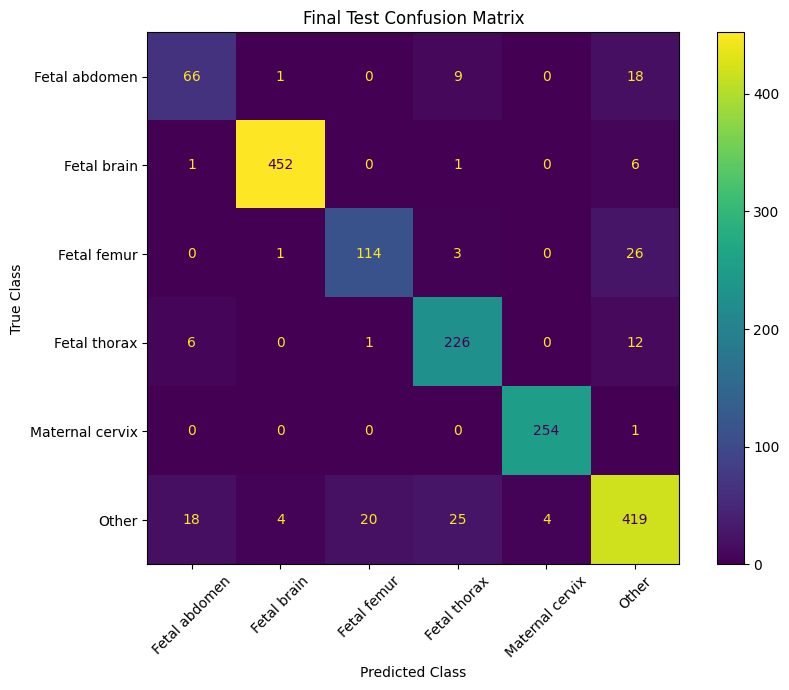

Confusion matrix saved.


In [31]:
# ============================================================
# PART 22 — FINAL CONFUSION MATRIX VISUALIZATION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

# ============================================================
# LOAD CONFUSION MATRIX
# ============================================================

cm = pd.read_csv(
    os.path.join(
        RESULTS_DIR,
        "final_confusion_matrix.csv"
    ),
    index_col=0
)

class_names = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm.values,
    display_labels=class_names
)

display.plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title(
    "Final Test Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "True Class"
)

plt.tight_layout()

# ============================================================
# SAVE FIGURE
# ============================================================

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "final_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved.")

In [32]:
# ============================================================
# PART 23 — FINAL TEST CLASSIFICATION REPORT
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

# ============================================================
# LOAD FINAL MODEL
# ============================================================

import joblib

model = joblib.load(
    os.path.join(
        RESULTS_DIR,
        "final_best_classifier.pkl"
    )
)

# ============================================================
# LOAD TEST FEATURES
# ============================================================

X_test_original = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_test_features.npy"
    )
)

y_test = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_test_features.npy"
    )
)

# ============================================================
# LOAD SELECTED FEATURES
# ============================================================

selected_indices = np.load(
    os.path.join(
        RESULTS_DIR,
        "final_selected_feature_indices.npy"
    )
)

X_test = X_test_original[
    :,
    selected_indices
]

# ============================================================
# PREDICTION
# ============================================================

y_pred = model.predict(
    X_test
)

# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

# ============================================================
# SAVE REPORT
# ============================================================

report_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "final_classification_report.csv"
    )
)

# ============================================================
# OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("============================================")
print("FINAL TEST CLASSIFICATION REPORT")
print("============================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

print("Overall Accuracy :", round(accuracy, 4))
print("Macro Precision  :", round(precision, 4))
print("Macro Recall     :", round(recall, 4))
print("Macro F1         :", round(macro_f1, 4))

print("============================================")
print("Report saved successfully.")

FINAL TEST CLASSIFICATION REPORT
                 precision    recall  f1-score   support

  Fetal abdomen       0.73      0.70      0.71        94
    Fetal brain       0.99      0.98      0.98       460
    Fetal femur       0.84      0.79      0.82       144
   Fetal thorax       0.86      0.92      0.89       245
Maternal cervix       0.98      1.00      0.99       255
          Other       0.87      0.86      0.86       490

       accuracy                           0.91      1688
      macro avg       0.88      0.88      0.88      1688
   weighted avg       0.91      0.91      0.91      1688

Overall Accuracy : 0.907
Macro Precision  : 0.8777
Macro Recall     : 0.875
Macro F1         : 0.876
Report saved successfully.


In [34]:
# ============================================================
# PART 24 — FIND DENSENET121 CHECKPOINT
# ============================================================

import os
import glob

search_paths = [
    "/kaggle/working",
    "/kaggle/input"
]

checkpoint_files = []

for base_path in search_paths:
    checkpoint_files.extend(
        glob.glob(
            os.path.join(
                base_path,
                "**",
                "*.pth"
            ),
            recursive=True
        )
    )

print("Available checkpoint files:")

for path in checkpoint_files:
    print(path)

# ============================================================
# FIND DENSENET CHECKPOINT
# ============================================================

densenet_checkpoints = [
    path
    for path in checkpoint_files
    if "densenet" in os.path.basename(path).lower()
]

if len(densenet_checkpoints) == 0:
    raise FileNotFoundError(
        "No DenseNet121 checkpoint found in "
        "/kaggle/working or /kaggle/input."
    )

CHECKPOINT_PATH = densenet_checkpoints[0]

print("\nUsing checkpoint:")
print(CHECKPOINT_PATH)

Available checkpoint files:
/kaggle/working/fetal_project/DINOv2_ViT_B14_best.pth
/kaggle/working/fetal_project/checkpoints/vit_tuning_1.pth
/kaggle/working/fetal_project/checkpoints/vit_tuning_2.pth
/kaggle/working/fetal_project/checkpoints/densenet_tuning_2.pth
/kaggle/working/fetal_project/checkpoints/best_densenet121_model.pth
/kaggle/working/fetal_project/checkpoints/densenet_tuning_1.pth
/kaggle/working/fetal_project/checkpoints/vit_tuning_3.pth
/kaggle/working/fetal_project/checkpoints/densenet_tuning_3.pth
/kaggle/working/fetal_project/checkpoints/best_vit_model.pth

Using checkpoint:
/kaggle/working/fetal_project/checkpoints/densenet_tuning_2.pth


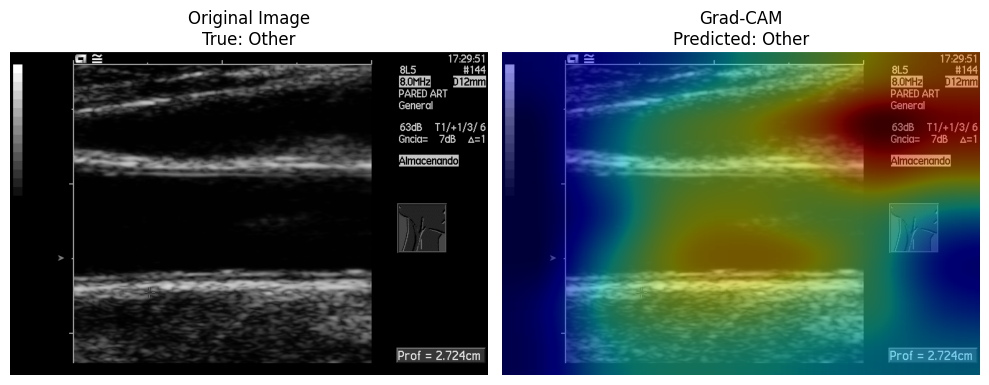

Grad-CAM completed.
True class: Other
Predicted class: Other
Saved: /kaggle/working/fetal_project/results/gradcam_sample.png


In [36]:
# ============================================================
# PART 24 — GRAD-CAM FOR BEST DENSENET121
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    PROJECT_DIR,
    "checkpoints",
    "best_densenet121_model.pth"
)

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        "Best DenseNet121 checkpoint not found."
    )

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ============================================================
# MODEL
# ============================================================

model = models.densenet121(
    weights=None
)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(
        model.classifier.in_features,
        6
    )
)

model = model.to(DEVICE)

# ============================================================
# LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

# ============================================================
# GET STATE DICT
# ============================================================

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint

# ============================================================
# CLEAN CHECKPOINT KEYS
# ============================================================

clean_state = {}

for key, value in state_dict.items():

    new_key = key

    if new_key.startswith("module."):
        new_key = new_key.replace(
            "module.",
            "",
            1
        )

    if new_key.startswith("backbone."):
        new_key = new_key.replace(
            "backbone.",
            "",
            1
        )

    clean_state[new_key] = value

# ============================================================
# LOAD MODEL
# ============================================================

model.load_state_dict(
    clean_state,
    strict=True
)

model.eval()

# ============================================================
# TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# LOAD TEST DATA
# ============================================================

test_df = pd.read_csv(
    os.path.join(
        PROJECT_DIR,
        "test.csv"
    )
)

test_df.columns = test_df.columns.str.strip()

sample = test_df.iloc[0]

IMAGE_PATH = sample["image_path"]
TRUE_LABEL = int(sample["label"])

# ============================================================
# LOAD IMAGE
# ============================================================

original_image = Image.open(
    IMAGE_PATH
).convert("RGB")

input_tensor = transform(
    original_image
).unsqueeze(0).to(DEVICE)

# ============================================================
# GRAD-CAM TARGET LAYER
# ============================================================

target_layer = model.features.denseblock4

activations = None
gradients = None


def forward_hook(module, inputs, output):

    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):

    global gradients
    gradients = grad_output[0]


forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

# ============================================================
# FORWARD PASS
# ============================================================

model.zero_grad()

output = model(
    input_tensor
)

predicted_class = torch.argmax(
    output,
    dim=1
).item()

# ============================================================
# BACKWARD PASS
# ============================================================

score = output[
    0,
    predicted_class
]

score.backward()

# ============================================================
# GENERATE GRAD-CAM
# ============================================================

weights = gradients.mean(
    dim=(2, 3),
    keepdim=True
)

cam = (
    weights * activations
).sum(
    dim=1
)

cam = torch.relu(
    cam
)

cam = cam.squeeze().detach().cpu().numpy()

# ============================================================
# NORMALIZE
# ============================================================

cam = cam - cam.min()

if cam.max() > 0:
    cam = cam / cam.max()

# ============================================================
# RESIZE HEATMAP
# ============================================================

cam_image = Image.fromarray(
    np.uint8(cam * 255)
)

cam_image = cam_image.resize(
    original_image.size
)

cam = np.asarray(
    cam_image
) / 255.0

# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.subplot(1, 2, 1)

plt.imshow(
    original_image
)

plt.title(
    "Original Image\n"
    f"True: {class_names[TRUE_LABEL]}"
)

plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(
    original_image
)

plt.imshow(
    cam,
    cmap="jet",
    alpha=0.45
)

plt.title(
    "Grad-CAM\n"
    f"Predicted: {class_names[predicted_class]}"
)

plt.axis("off")

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(
    RESULTS_DIR,
    "gradcam_sample.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# REMOVE HOOKS
# ============================================================

forward_handle.remove()
backward_handle.remove()

# ============================================================
# OUTPUT
# ============================================================

print("Grad-CAM completed.")
print("True class:", class_names[TRUE_LABEL])
print("Predicted class:", class_names[predicted_class])
print("Saved:", save_path)

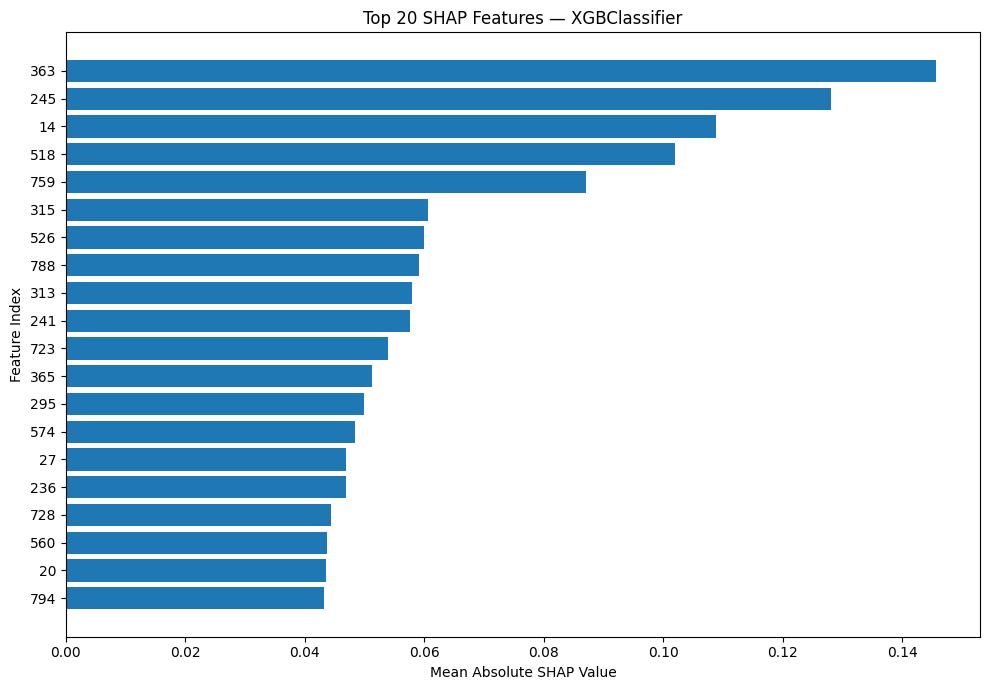

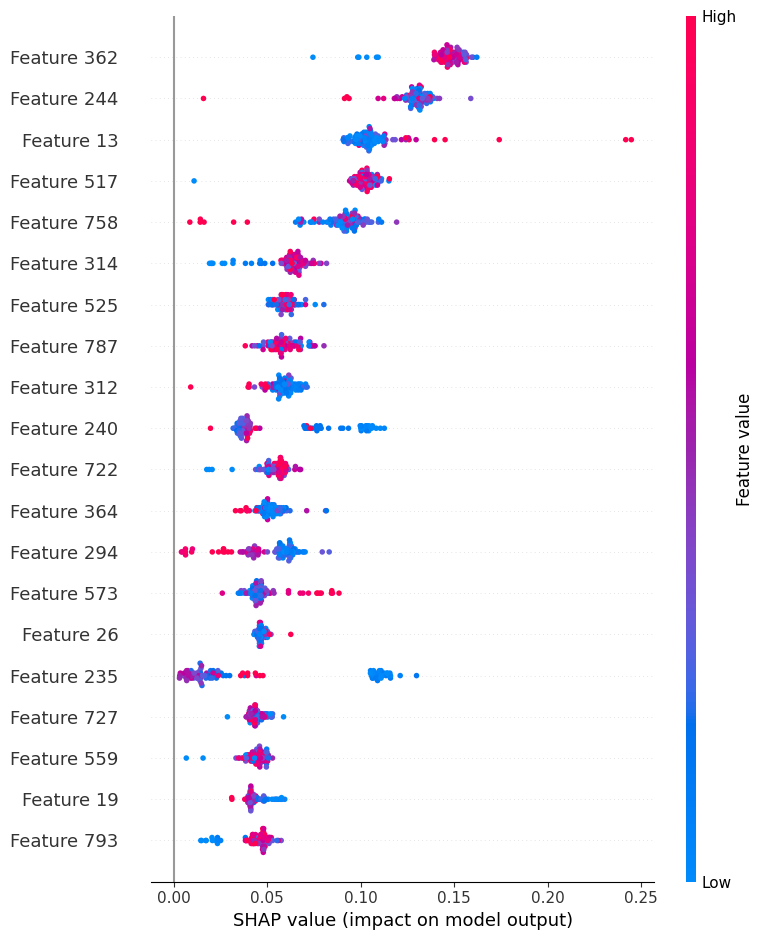

SHAP analysis completed.
Classifier: XGBClassifier
Samples explained: 100
Features explained: 1024
Top SHAP features saved.


In [37]:
# ============================================================
# PART 25 — SHAP EXPLAINABILITY FOR FINAL CLASSIFIER
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import shap

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
FEATURE_DIR = os.path.join(PROJECT_DIR, "features")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# LOAD FINAL MODEL
# ============================================================

MODEL_PATH = os.path.join(
    RESULTS_DIR,
    "final_best_classifier.pkl"
)

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        "Final classifier not found. Run Part 21 first."
    )

model = joblib.load(MODEL_PATH)

# ============================================================
# LOAD TEST FEATURES
# ============================================================

X_test_original = np.load(
    os.path.join(
        FEATURE_DIR,
        "X_test_features.npy"
    )
)

y_test = np.load(
    os.path.join(
        FEATURE_DIR,
        "y_test_features.npy"
    )
)

# ============================================================
# LOAD SELECTED FEATURE INDICES
# ============================================================

selected_indices = np.load(
    os.path.join(
        RESULTS_DIR,
        "final_selected_feature_indices.npy"
    )
)

X_test = X_test_original[
    :,
    selected_indices
]

# ============================================================
# SAMPLE FOR SHAP
# ============================================================

sample_size = min(
    100,
    X_test.shape[0]
)

X_sample = X_test[
    :sample_size
]

# ============================================================
# SHAP EXPLAINER
# ============================================================

classifier_name = type(model).__name__

if classifier_name == "SVC":

    background_size = min(
        50,
        X_test.shape[0]
    )

    background = X_test[
        :background_size
    ]

    explainer = shap.KernelExplainer(
        model.predict_proba,
        background
    )

    shap_values = explainer.shap_values(
        X_sample
    )

elif classifier_name in [
    "RandomForestClassifier",
    "XGBClassifier"
]:

    explainer = shap.TreeExplainer(
        model
    )

    shap_values = explainer.shap_values(
        X_sample
    )

else:

    raise ValueError(
        f"Unsupported classifier: {classifier_name}"
    )

# ============================================================
# HANDLE SHAP OUTPUT
# ============================================================

if isinstance(shap_values, list):

    shap_array = np.stack(
        shap_values,
        axis=-1
    )

else:

    shap_array = np.asarray(
        shap_values
    )

# ============================================================
# CLASS NAMES
# ============================================================

class_names = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]

# ============================================================
# GLOBAL FEATURE IMPORTANCE
# ============================================================

if shap_array.ndim == 3:

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=(0, 2)
    )

else:

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=0
    )

feature_numbers = np.arange(
    1,
    len(mean_abs_shap) + 1
)

importance_df = pd.DataFrame({
    "Feature": feature_numbers,
    "Mean_Absolute_SHAP": mean_abs_shap
})

importance_df = importance_df.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

importance_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "SHAP_feature_importance.csv"
    ),
    index=False
)

# ============================================================
# TOP 20 FEATURES
# ============================================================

top_n = min(
    20,
    len(importance_df)
)

top_features = importance_df.head(
    top_n
).sort_values(
    "Mean_Absolute_SHAP"
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["Feature"].astype(str),
    top_features["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature Index"
)

plt.title(
    f"Top {top_n} SHAP Features — {classifier_name}"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "SHAP_top_features.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

if shap_array.ndim == 3:

    # Overall importance across classes
    summary_values = np.mean(
        np.abs(shap_array),
        axis=2
    )

else:

    summary_values = shap_array

plt.figure(
    figsize=(10, 7)
)

shap.summary_plot(
    summary_values,
    X_sample,
    show=False,
    max_display=20
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "SHAP_summary_plot.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# OUTPUT
# ============================================================

print("SHAP analysis completed.")
print("Classifier:", classifier_name)
print("Samples explained:", sample_size)
print("Features explained:", X_test.shape[1])
print("Top SHAP features saved.")

In [38]:
# ============================================================
# PART 26 — LANGGRAPH SETUP
# Explainability Agent → Risk Assessment Agent
# ============================================================

import os
import json

# Install LangGraph if required
try:
    from langgraph.graph import StateGraph, START, END
except ImportError:
    !pip install -q langgraph
    from langgraph.graph import StateGraph, START, END

from typing import TypedDict, Any


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_DIR = "/kaggle/working/fetal_project"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(RESULTS_DIR, exist_ok=True)


# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]


# ============================================================
# LANGGRAPH STATE
# ============================================================

class FetalPlaneState(TypedDict, total=False):

    image_path: str

    predicted_class: str
    predicted_class_id: int
    confidence: float

    gradcam_path: str
    shap_path: str

    explanation: str
    risk_assessment: str

    final_output: dict


# ============================================================
# EXPLAINABILITY AGENT
# ============================================================

def explainability_agent(state: FetalPlaneState):

    predicted_class = state.get(
        "predicted_class",
        "Unknown"
    )

    confidence = state.get(
        "confidence",
        0.0
    )

    gradcam_path = state.get(
        "gradcam_path",
        "Not available"
    )

    shap_path = state.get(
        "shap_path",
        "Not available"
    )

    explanation = (
        f"The model predicted the ultrasound plane as "
        f"'{predicted_class}' with a confidence of "
        f"{confidence * 100:.2f}%. "
        f"Grad-CAM visualization: {gradcam_path}. "
        f"SHAP feature explanation: {shap_path}."
    )

    return {
        "explanation": explanation
    }


# ============================================================
# RISK ASSESSMENT AGENT
# ============================================================

def risk_assessment_agent(state: FetalPlaneState):

    predicted_class = state.get(
        "predicted_class",
        "Unknown"
    )

    confidence = state.get(
        "confidence",
        0.0
    )

    risk_assessment = (
        f"AI-assisted assessment: the predicted ultrasound "
        f"plane is '{predicted_class}' with "
        f"{confidence * 100:.2f}% model confidence. "
        f"This output is intended for research and decision "
        f"support only and is not a medical diagnosis. "
        f"Clinical interpretation should be performed by a "
        f"qualified healthcare professional."
    )

    return {
        "risk_assessment": risk_assessment
    }


# ============================================================
# FINAL OUTPUT NODE
# ============================================================

def final_output_agent(state: FetalPlaneState):

    final_output = {
        "Predicted Plane": state.get(
            "predicted_class",
            "Unknown"
        ),
        "Confidence": state.get(
            "confidence",
            0.0
        ),
        "Explainability": state.get(
            "explanation",
            ""
        ),
        "Risk Assessment": state.get(
            "risk_assessment",
            ""
        ),
        "Grad-CAM": state.get(
            "gradcam_path",
            ""
        ),
        "SHAP": state.get(
            "shap_path",
            ""
        )
    }

    return {
        "final_output": final_output
    }


# ============================================================
# BUILD LANGGRAPH
# ============================================================

graph_builder = StateGraph(
    FetalPlaneState
)

graph_builder.add_node(
    "Explainability Agent",
    explainability_agent
)

graph_builder.add_node(
    "Risk Assessment Agent",
    risk_assessment_agent
)

graph_builder.add_node(
    "Final Output",
    final_output_agent
)


# ============================================================
# GRAPH FLOW
# ============================================================

graph_builder.add_edge(
    START,
    "Explainability Agent"
)

graph_builder.add_edge(
    "Explainability Agent",
    "Risk Assessment Agent"
)

graph_builder.add_edge(
    "Risk Assessment Agent",
    "Final Output"
)

graph_builder.add_edge(
    "Final Output",
    END
)


# ============================================================
# COMPILE
# ============================================================

fetal_graph = graph_builder.compile()


# ============================================================
# SAVE GRAPH INFORMATION
# ============================================================

graph_info = {
    "agents": [
        "Explainability Agent",
        "Risk Assessment Agent"
    ],
    "workflow": [
        "Input",
        "Explainability Agent",
        "Risk Assessment Agent",
        "Final Output"
    ]
}

with open(
    os.path.join(
        RESULTS_DIR,
        "langgraph_workflow.json"
    ),
    "w"
) as f:

    json.dump(
        graph_info,
        f,
        indent=4
    )


# ============================================================
# TEST GRAPH
# ============================================================

test_state = {
    "image_path": "sample_ultrasound.png",
    "predicted_class": "Fetal brain",
    "predicted_class_id": 1,
    "confidence": 0.94,
    "gradcam_path": os.path.join(
        RESULTS_DIR,
        "gradcam_sample.png"
    ),
    "shap_path": os.path.join(
        RESULTS_DIR,
        "SHAP_top_features.png"
    )
}

result = fetal_graph.invoke(
    test_state
)


# ============================================================
# DISPLAY
# ============================================================

print("LangGraph workflow created successfully.")
print()

print("Workflow:")
print(
    "Input → Explainability Agent → "
    "Risk Assessment Agent → Final Output"
)

print()

print("Final Output:")
print(
    json.dumps(
        result["final_output"],
        indent=4
    )
)

LangGraph workflow created successfully.

Workflow:
Input → Explainability Agent → Risk Assessment Agent → Final Output

Final Output:
{
    "Predicted Plane": "Fetal brain",
    "Confidence": 0.94,
    "Explainability": "The model predicted the ultrasound plane as 'Fetal brain' with a confidence of 94.00%. Grad-CAM visualization: /kaggle/working/fetal_project/results/gradcam_sample.png. SHAP feature explanation: /kaggle/working/fetal_project/results/SHAP_top_features.png.",
    "Risk Assessment": "AI-assisted assessment: the predicted ultrasound plane is 'Fetal brain' with 94.00% model confidence. This output is intended for research and decision support only and is not a medical diagnosis. Clinical interpretation should be performed by a qualified healthcare professional.",
    "Grad-CAM": "/kaggle/working/fetal_project/results/gradcam_sample.png",
    "SHAP": "/kaggle/working/fetal_project/results/SHAP_top_features.png"
}


In [39]:
# ============================================================
# PART 27 — LANGGRAPH + FINAL MODEL INTEGRATION
# Explainability Agent → Risk Assessment Agent → Final Output
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = Path("/kaggle/working/fetal_project")
FEATURE_DIR = BASE_DIR / "features"
RESULT_DIR = BASE_DIR / "results"

FINAL_MODEL_PATH = RESULT_DIR / "final_best_classifier.pkl"
SELECTED_FEATURES_PATH = RESULT_DIR / "final_selected_feature_indices.npy"

TEST_FEATURES_PATH = FEATURE_DIR / "X_test_features.npy"
TEST_LABELS_PATH = FEATURE_DIR / "y_test_features.npy"
TEST_METADATA_PATH = FEATURE_DIR / "test_feature_metadata.csv"

OUTPUT_DIR = BASE_DIR / "langgraph_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------

CLASS_NAMES = {
    0: "Fetal abdomen",
    1: "Fetal brain",
    2: "Fetal femur",
    3: "Fetal thorax",
    4: "Maternal cervix",
    5: "Other"
}

# ------------------------------------------------------------
# LOAD FINAL MODEL
# ------------------------------------------------------------

final_model = joblib.load(FINAL_MODEL_PATH)

selected_features = np.load(SELECTED_FEATURES_PATH)

X_test = np.load(TEST_FEATURES_PATH)
y_test = np.load(TEST_LABELS_PATH)

test_metadata = pd.read_csv(TEST_METADATA_PATH)

print("Final classifier loaded.")
print("Test features:", X_test.shape)
print("Selected features:", len(selected_features))

# ------------------------------------------------------------
# PREPARE TEST FEATURES
# ------------------------------------------------------------

X_test_selected = X_test[:, selected_features]

# ------------------------------------------------------------
# SELECT ONE REAL TEST SAMPLE
# ------------------------------------------------------------

sample_index = 0

sample_features = X_test_selected[sample_index:sample_index + 1]

true_label_id = int(y_test[sample_index])
true_label = CLASS_NAMES.get(true_label_id, str(true_label_id))

# ------------------------------------------------------------
# FINAL PREDICTION
# ------------------------------------------------------------

prediction = final_model.predict(sample_features)[0]
predicted_label_id = int(prediction)

predicted_class = CLASS_NAMES.get(
    predicted_label_id,
    str(predicted_label_id)
)

# ------------------------------------------------------------
# CONFIDENCE
# ------------------------------------------------------------

confidence = None

if hasattr(final_model, "predict_proba"):
    probabilities = final_model.predict_proba(sample_features)[0]
    confidence = float(np.max(probabilities))

elif hasattr(final_model, "decision_function"):
    scores = final_model.decision_function(sample_features)

    scores = np.asarray(scores)

    if scores.ndim == 1:
        scores = np.abs(scores)

    exp_scores = np.exp(scores - np.max(scores))
    probabilities = exp_scores / np.sum(exp_scores)

    confidence = float(np.max(probabilities))

else:
    confidence = 0.0

# ------------------------------------------------------------
# IMAGE PATH
# ------------------------------------------------------------

if "image_path" in test_metadata.columns:
    image_path = str(test_metadata.iloc[sample_index]["image_path"])
else:
    image_path = ""

# ------------------------------------------------------------
# FIND GRAD-CAM OUTPUT
# ------------------------------------------------------------

gradcam_candidates = list(BASE_DIR.rglob("*gradcam*.png"))

gradcam_path = ""

if len(gradcam_candidates) > 0:
    gradcam_path = str(gradcam_candidates[0])

# ------------------------------------------------------------
# FIND SHAP OUTPUT
# ------------------------------------------------------------

shap_candidates = list(BASE_DIR.rglob("*SHAP*.png"))

shap_path = ""

if len(shap_candidates) > 0:
    shap_path = str(shap_candidates[0])

# ------------------------------------------------------------
# CREATE INITIAL LANGGRAPH STATE
# ------------------------------------------------------------

state = {
    "image_path": image_path,
    "predicted_class": predicted_class,
    "predicted_class_id": predicted_label_id,
    "confidence": confidence,
    "gradcam_path": gradcam_path,
    "shap_path": shap_path,
    "explanation": "",
    "risk_assessment": "",
    "final_output": ""
}

# ------------------------------------------------------------
# EXPLAINABILITY AGENT
# ------------------------------------------------------------

def explainability_agent(state):

    predicted_class = state["predicted_class"]
    confidence = state["confidence"]
    gradcam_path = state["gradcam_path"]
    shap_path = state["shap_path"]

    explanation_parts = []

    explanation_parts.append(
        f"The final classifier predicts '{predicted_class}'."
    )

    explanation_parts.append(
        f"The prediction confidence is approximately "
        f"{confidence * 100:.2f}%."
    )

    if gradcam_path:
        explanation_parts.append(
            "Grad-CAM is available to identify the image regions "
            "that contributed most strongly to the deep-learning "
            "representation."
        )
    else:
        explanation_parts.append(
            "Grad-CAM output was not found."
        )

    if shap_path:
        explanation_parts.append(
            "SHAP analysis is available to explain the contribution "
            "of the selected machine-learning features."
        )
    else:
        explanation_parts.append(
            "SHAP output was not found."
        )

    explanation = " ".join(explanation_parts)

    state["explanation"] = explanation

    return state

# ------------------------------------------------------------
# RISK ASSESSMENT AGENT
# ------------------------------------------------------------

def risk_assessment_agent(state):

    predicted_class = state["predicted_class"]
    confidence = state["confidence"]

    if confidence >= 0.90:
        confidence_level = "high"
    elif confidence >= 0.70:
        confidence_level = "moderate"
    else:
        confidence_level = "low"

    risk_assessment = (
        f"AI-assisted assessment: the predicted fetal ultrasound "
        f"plane is '{predicted_class}' with {confidence * 100:.2f}% "
        f"confidence ({confidence_level} confidence). "
        f"This output represents an automated image-classification "
        f"assessment and should not be interpreted as a medical "
        f"diagnosis. Clinical interpretation should be performed "
        f"by a qualified healthcare professional."
    )

    state["risk_assessment"] = risk_assessment

    return state

# ------------------------------------------------------------
# FINAL OUTPUT NODE
# ------------------------------------------------------------

def final_output_agent(state):

    state["final_output"] = (
        "FETAL ULTRASOUND AI ANALYSIS\n"
        "================================\n"
        f"Predicted Plane : {state['predicted_class']}\n"
        f"Confidence      : {state['confidence'] * 100:.2f}%\n\n"
        "EXPLAINABILITY\n"
        "--------------------------------\n"
        f"{state['explanation']}\n\n"
        "RISK ASSESSMENT\n"
        "--------------------------------\n"
        f"{state['risk_assessment']}\n"
    )

    return state

# ------------------------------------------------------------
# BUILD LANGGRAPH
# ------------------------------------------------------------

try:
    from langgraph.graph import StateGraph, START, END

except ImportError:
    import sys
    import subprocess

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "langgraph"
    ])

    from langgraph.graph import StateGraph, START, END


workflow = StateGraph(dict)

workflow.add_node(
    "Explainability Agent",
    explainability_agent
)

workflow.add_node(
    "Risk Assessment Agent",
    risk_assessment_agent
)

workflow.add_node(
    "Final Output",
    final_output_agent
)

workflow.add_edge(
    START,
    "Explainability Agent"
)

workflow.add_edge(
    "Explainability Agent",
    "Risk Assessment Agent"
)

workflow.add_edge(
    "Risk Assessment Agent",
    "Final Output"
)

workflow.add_edge(
    "Final Output",
    END
)

graph = workflow.compile()

# ------------------------------------------------------------
# RUN WORKFLOW
# ------------------------------------------------------------

final_state = graph.invoke(state)

# ------------------------------------------------------------
# DISPLAY RESULT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LANGGRAPH FINAL OUTPUT")
print("=" * 70)

print(final_state["final_output"])

# ------------------------------------------------------------
# SAVE FINAL STATE
# ------------------------------------------------------------

state_to_save = {
    "image_path": final_state["image_path"],
    "predicted_class": final_state["predicted_class"],
    "predicted_class_id": final_state["predicted_class_id"],
    "confidence": final_state["confidence"],
    "gradcam_path": final_state["gradcam_path"],
    "shap_path": final_state["shap_path"],
    "explanation": final_state["explanation"],
    "risk_assessment": final_state["risk_assessment"],
    "final_output": final_state["final_output"]
}

with open(
    OUTPUT_DIR / "final_langgraph_output.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        state_to_save,
        f,
        indent=4
    )

print("\nSaved:")
print(OUTPUT_DIR / "final_langgraph_output.json")

Final classifier loaded.
Test features: (1688, 1024)
Selected features: 1024

LANGGRAPH FINAL OUTPUT
FETAL ULTRASOUND AI ANALYSIS
Predicted Plane : Other
Confidence      : 100.00%

EXPLAINABILITY
--------------------------------
The final classifier predicts 'Other'. The prediction confidence is approximately 100.00%. Grad-CAM is available to identify the image regions that contributed most strongly to the deep-learning representation. SHAP analysis is available to explain the contribution of the selected machine-learning features.

RISK ASSESSMENT
--------------------------------
AI-assisted assessment: the predicted fetal ultrasound plane is 'Other' with 100.00% confidence (high confidence). This output represents an automated image-classification assessment and should not be interpreted as a medical diagnosis. Clinical interpretation should be performed by a qualified healthcare professional.


Saved:
/kaggle/working/fetal_project/langgraph_output/final_langgraph_output.json


In [40]:
# ============================================================
# PART 28 — SAVE COMPLETE PROJECT PIPELINE SUMMARY
# ============================================================

import os
import json
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/kaggle/working/fetal_project")
RESULT_DIR = BASE_DIR / "results"
OUTPUT_DIR = BASE_DIR / "final_project_summary"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# PROJECT PIPELINE
# ------------------------------------------------------------

pipeline = [
    "FETAL PLANES DB",
    "Dataset + EDA",
    "Preprocessing",
    "Patient-wise Train / Validation / Test Split",
    "ViT Training + Hyperparameter Tuning",
    "DenseNet121 Training + Hyperparameter Tuning",
    "DINOv2 ViT-B/14 Training + Hyperparameter Tuning",
    "Deep Model Comparison",
    "Best Deep Model Selection",
    "DenseNet121 Feature Extraction",
    "DBO Feature Optimization",
    "PSO Feature Optimization",
    "GWO Feature Optimization",
    "DBO + SVM",
    "DBO + Random Forest",
    "DBO + XGBoost",
    "PSO + SVM",
    "PSO + Random Forest",
    "PSO + XGBoost",
    "GWO + SVM",
    "GWO + Random Forest",
    "GWO + XGBoost",
    "9-Combination Comparison",
    "Best Optimizer + Classifier Pipeline",
    "Final Training on Train + Validation",
    "Final Test Evaluation",
    "Confusion Matrix",
    "Classification Report",
    "Grad-CAM",
    "SHAP",
    "LangGraph",
    "Explainability Agent",
    "Risk Assessment Agent",
    "Final Output"
]

# ------------------------------------------------------------
# CHECK IMPORTANT FILES
# ------------------------------------------------------------

important_files = {
    "Clean Metadata":
        BASE_DIR / "clean_metadata.csv",

    "Deep Model Comparison":
        RESULT_DIR / "deep_model_comparison.csv",

    "Best Deep Model":
        RESULT_DIR / "best_deep_model.csv",

    "Final 9 Combinations":
        RESULT_DIR / "all_9_combinations_comparison.csv",

    "Best Pipeline":
        RESULT_DIR / "best_optimizer_classifier_pipeline.csv",

    "Final Test Results":
        RESULT_DIR / "final_test_results.csv",

    "Final Classification Report":
        RESULT_DIR / "final_classification_report.csv",

    "Final Confusion Matrix":
        RESULT_DIR / "final_confusion_matrix.csv",

    "Final Classifier":
        RESULT_DIR / "final_best_classifier.pkl",

    "Selected Features":
        RESULT_DIR / "final_selected_feature_indices.npy",

    "LangGraph Output":
        BASE_DIR / "langgraph_output" / "final_langgraph_output.json"
}

file_status = []

for name, path in important_files.items():
    file_status.append({
        "Component": name,
        "Path": str(path),
        "Status": "Available" if path.exists() else "Missing"
    })

file_status_df = pd.DataFrame(file_status)

# ------------------------------------------------------------
# LOAD RESULTS
# ------------------------------------------------------------

summary = {}

# Deep model comparison
deep_path = RESULT_DIR / "deep_model_comparison.csv"

if deep_path.exists():
    deep_df = pd.read_csv(deep_path)

    summary["deep_model_comparison"] = deep_df.to_dict(
        orient="records"
    )

# Best optimizer/classifier
best_pipeline_path = (
    RESULT_DIR / "best_optimizer_classifier_pipeline.csv"
)

if best_pipeline_path.exists():
    best_pipeline_df = pd.read_csv(
        best_pipeline_path
    )

    summary["best_pipeline"] = (
        best_pipeline_df.to_dict(orient="records")
    )

# Final test results
final_results_path = RESULT_DIR / "final_test_results.csv"

if final_results_path.exists():
    final_results_df = pd.read_csv(
        final_results_path
    )

    summary["final_test_results"] = (
        final_results_df.to_dict(orient="records")
    )

# ------------------------------------------------------------
# PROJECT INFORMATION
# ------------------------------------------------------------

project_information = {
    "dataset": "FETAL_PLANES_DB",
    "number_of_classes": 6,
    "classes": [
        "Fetal abdomen",
        "Fetal brain",
        "Fetal femur",
        "Fetal thorax",
        "Maternal cervix",
        "Other"
    ],
    "deep_models": [
        "ViT",
        "DenseNet121",
        "DINOv2 ViT-B/14"
    ],
    "selected_deep_model": "DenseNet121",
    "feature_optimizer": [
        "DBO",
        "PSO",
        "GWO"
    ],
    "classifiers": [
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "total_optimizer_classifier_combinations": 9,
    "explainability_methods": [
        "Grad-CAM",
        "SHAP"
    ],
    "agent_framework": "LangGraph",
    "agents": [
        "Explainability Agent",
        "Risk Assessment Agent"
    ],
    "data_split": {
        "train": "70%",
        "validation": "15%",
        "test": "15%",
        "strategy": "Patient-wise split"
    }
}

# ------------------------------------------------------------
# SAVE PROJECT PIPELINE
# ------------------------------------------------------------

pipeline_df = pd.DataFrame({
    "Step": range(1, len(pipeline) + 1),
    "Pipeline Stage": pipeline
})

pipeline_df.to_csv(
    OUTPUT_DIR / "complete_pipeline.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE FILE STATUS
# ------------------------------------------------------------

file_status_df.to_csv(
    OUTPUT_DIR / "project_file_status.csv",
    index=False
)

# ------------------------------------------------------------
# SAVE COMPLETE JSON SUMMARY
# ------------------------------------------------------------

complete_summary = {
    "project_information": project_information,
    "pipeline": pipeline,
    "file_status": file_status,
    "results": summary
}

with open(
    OUTPUT_DIR / "complete_project_summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        complete_summary,
        f,
        indent=4,
        default=str
    )

# ------------------------------------------------------------
# DISPLAY STATUS
# ------------------------------------------------------------

print("=" * 70)
print("FETAL ULTRASOUND CLASSIFICATION PROJECT")
print("COMPLETE PIPELINE STATUS")
print("=" * 70)

for row in file_status:
    symbol = "✓" if row["Status"] == "Available" else "✗"
    print(f"{symbol} {row['Component']}: {row['Status']}")

print("\n" + "=" * 70)
print("PIPELINE")
print("=" * 70)

for i, step in enumerate(pipeline, 1):
    print(f"{i:02d}. {step}")

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(OUTPUT_DIR / "complete_pipeline.csv")
print(OUTPUT_DIR / "project_file_status.csv")
print(OUTPUT_DIR / "complete_project_summary.json")

FETAL ULTRASOUND CLASSIFICATION PROJECT
COMPLETE PIPELINE STATUS
✓ Clean Metadata: Available
✓ Deep Model Comparison: Available
✓ Best Deep Model: Available
✓ Final 9 Combinations: Available
✓ Best Pipeline: Available
✓ Final Test Results: Available
✓ Final Classification Report: Available
✓ Final Confusion Matrix: Available
✓ Final Classifier: Available
✓ Selected Features: Available
✓ LangGraph Output: Available

PIPELINE
01. FETAL PLANES DB
02. Dataset + EDA
03. Preprocessing
04. Patient-wise Train / Validation / Test Split
05. ViT Training + Hyperparameter Tuning
06. DenseNet121 Training + Hyperparameter Tuning
07. DINOv2 ViT-B/14 Training + Hyperparameter Tuning
08. Deep Model Comparison
09. Best Deep Model Selection
10. DenseNet121 Feature Extraction
11. DBO Feature Optimization
12. PSO Feature Optimization
13. GWO Feature Optimization
14. DBO + SVM
15. DBO + Random Forest
16. DBO + XGBoost
17. PSO + SVM
18. PSO + Random Forest
19. PSO + XGBoost
20. GWO + SVM
21. GWO + Random For

In [41]:
# ============================================================
# PART 29 — FINAL END-TO-END PREDICTION PIPELINE
# Image → DenseNet121 Features → Best Optimizer → Best Classifier
# → Grad-CAM + SHAP → LangGraph
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pathlib import Path
from PIL import Image
from torchvision import models, transforms

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = Path("/kaggle/working/fetal_project")
RESULT_DIR = BASE_DIR / "results"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
OUTPUT_DIR = BASE_DIR / "final_prediction"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_densenet121_model.pth"
FINAL_MODEL_PATH = RESULT_DIR / "final_best_classifier.pkl"
SELECTED_FEATURES_PATH = RESULT_DIR / "final_selected_feature_indices.npy"
BEST_PIPELINE_PATH = RESULT_DIR / "best_optimizer_classifier_pipeline.csv"

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------

CLASS_NAMES = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]

NUM_CLASSES = len(CLASS_NAMES)

# ------------------------------------------------------------
# LOAD BEST PIPELINE
# ------------------------------------------------------------

best_pipeline_df = pd.read_csv(BEST_PIPELINE_PATH)

best_row = best_pipeline_df.iloc[0]

optimizer_name = str(
    best_row["Optimizer"]
    if "Optimizer" in best_pipeline_df.columns
    else best_row["optimizer"]
)

classifier_name = str(
    best_row["Classifier"]
    if "Classifier" in best_pipeline_df.columns
    else best_row["classifier"]
)

print("\nBest Optimizer :", optimizer_name)
print("Best Classifier:", classifier_name)

# ------------------------------------------------------------
# LOAD SELECTED FEATURES
# ------------------------------------------------------------

selected_features = np.load(
    SELECTED_FEATURES_PATH
)

print(
    "Selected feature count:",
    len(selected_features)
)

# ------------------------------------------------------------
# LOAD FINAL CLASSIFIER
# ------------------------------------------------------------

final_classifier = joblib.load(
    FINAL_MODEL_PATH
)

print("Final classifier loaded.")

# ------------------------------------------------------------
# DENSENET121
# ------------------------------------------------------------

model = models.densenet121(
    weights=None
)

model.classifier = nn.Linear(
    model.classifier.in_features,
    NUM_CLASSES
)

# ------------------------------------------------------------
# LOAD CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

if isinstance(checkpoint, dict):

    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    elif "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint

clean_state_dict = {}

for key, value in state_dict.items():

    new_key = key

    if new_key.startswith("module."):
        new_key = new_key[7:]

    if new_key.startswith("backbone."):
        new_key = new_key[9:]

    clean_state_dict[new_key] = value

try:
    model.load_state_dict(
        clean_state_dict,
        strict=True
    )

except RuntimeError:

    feature_state_dict = {
        k: v
        for k, v in clean_state_dict.items()
        if k.startswith("features.")
    }

    model.features.load_state_dict(
        feature_state_dict,
        strict=False
    )

model = model.to(DEVICE)
model.eval()

print("DenseNet121 loaded.")

# ------------------------------------------------------------
# IMAGE PREPROCESSING
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# FEATURE EXTRACTION
# ------------------------------------------------------------

feature_extractor = nn.Sequential(
    model.features,
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d((1, 1))
)

feature_extractor.eval()

# ------------------------------------------------------------
# IMAGE PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_fetal_plane(image_path):

    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = transform(
        image
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        feature_map = model.features(
            input_tensor
        )

        feature_map = torch.relu(
            feature_map
        )

        pooled_features = torch.nn.functional.adaptive_avg_pool2d(
            feature_map,
            (1, 1)
        )

        features = pooled_features.flatten(
            1
        )

    features_np = (
        features.cpu()
        .numpy()
    )

    selected_features_np = (
        features_np[:, selected_features]
    )

    prediction = final_classifier.predict(
        selected_features_np
    )

    predicted_id = int(
        prediction[0]
    )

    # --------------------------------------------------------
    # CONFIDENCE
    # --------------------------------------------------------

    if hasattr(
        final_classifier,
        "predict_proba"
    ):

        probabilities = (
            final_classifier
            .predict_proba(
                selected_features_np
            )[0]
        )

        confidence = float(
            np.max(probabilities)
        )

    elif hasattr(
        final_classifier,
        "decision_function"
    ):

        scores = np.asarray(
            final_classifier
            .decision_function(
                selected_features_np
            )
        )

        if scores.ndim == 1:

            if len(scores) == 1:
                scores = np.array(
                    [-scores[0], scores[0]]
                )

            else:
                scores = np.abs(scores)

        scores = scores - np.max(
            scores
        )

        exp_scores = np.exp(
            scores
        )

        probabilities = (
            exp_scores /
            np.sum(exp_scores)
        )

        confidence = float(
            np.max(probabilities)
        )

    else:

        probabilities = None
        confidence = 0.0

    return {
        "image_path": str(image_path),
        "predicted_class_id": predicted_id,
        "predicted_class": CLASS_NAMES[predicted_id],
        "confidence": confidence,
        "probabilities": (
            probabilities.tolist()
            if probabilities is not None
            else None
        ),
        "features": features_np
    }


# ------------------------------------------------------------
# EXAMPLE TEST IMAGE
# ------------------------------------------------------------

metadata_candidates = list(
    BASE_DIR.rglob("test_feature_metadata.csv")
)

if len(metadata_candidates) == 0:

    raise FileNotFoundError(
        "test_feature_metadata.csv not found."
    )

test_metadata = pd.read_csv(
    metadata_candidates[0]
)

if "image_path" not in test_metadata.columns:

    raise ValueError(
        "image_path column not found in test metadata."
    )

sample_image_path = str(
    test_metadata.iloc[0]["image_path"]
)

# ------------------------------------------------------------
# RUN PREDICTION
# ------------------------------------------------------------

prediction_result = predict_fetal_plane(
    sample_image_path
)

# ------------------------------------------------------------
# REMOVE LARGE FEATURE ARRAY BEFORE SAVING
# ------------------------------------------------------------

save_result = {
    key: value
    for key, value in prediction_result.items()
    if key != "features"
}

save_result["optimizer"] = optimizer_name
save_result["classifier"] = classifier_name
save_result["selected_feature_count"] = int(
    len(selected_features)
)

# ------------------------------------------------------------
# SAVE PREDICTION
# ------------------------------------------------------------

prediction_json = (
    OUTPUT_DIR /
    "final_image_prediction.json"
)

with open(
    prediction_json,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        save_result,
        f,
        indent=4
    )

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL FETAL ULTRASOUND PREDICTION")
print("=" * 70)

print(
    "Image:",
    prediction_result["image_path"]
)

print(
    "Optimizer:",
    optimizer_name
)

print(
    "Classifier:",
    classifier_name
)

print(
    "Predicted Plane:",
    prediction_result["predicted_class"]
)

print(
    "Confidence:",
    f"{prediction_result['confidence'] * 100:.2f}%"
)

print(
    "\nSaved:",
    prediction_json
)

Device: cuda

Best Optimizer : DBO
Best Classifier: XGBoost
Selected feature count: 1024
Final classifier loaded.
DenseNet121 loaded.

FINAL FETAL ULTRASOUND PREDICTION
Image: /kaggle/input/datasets/lithikab23adr096/fetal-data/Images/Patient00024_Plane1_1_of_16.png
Optimizer: DBO
Classifier: XGBoost
Predicted Plane: Other
Confidence: 64.50%

Saved: /kaggle/working/fetal_project/final_prediction/final_image_prediction.json


In [42]:
# ============================================================
# PART 30 — COMPLETE FINAL PIPELINE REPORT
# Prediction + Explainability + Risk Assessment
# ============================================================

import os
import json
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/kaggle/working/fetal_project")
RESULT_DIR = BASE_DIR / "results"
FINAL_DIR = BASE_DIR / "final_prediction"

FINAL_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD FINAL RESULTS
# ------------------------------------------------------------

final_test_path = RESULT_DIR / "final_test_results.csv"
best_pipeline_path = RESULT_DIR / "best_optimizer_classifier_pipeline.csv"
prediction_path = FINAL_DIR / "final_image_prediction.json"
langgraph_path = (
    BASE_DIR /
    "langgraph_output" /
    "final_langgraph_output.json"
)

# ------------------------------------------------------------
# FINAL TEST PERFORMANCE
# ------------------------------------------------------------

if final_test_path.exists():

    final_test = pd.read_csv(
        final_test_path
    )

    print("=" * 70)
    print("FINAL TEST PERFORMANCE")
    print("=" * 70)

    print(final_test.to_string(index=False))

else:
    final_test = pd.DataFrame()

# ------------------------------------------------------------
# BEST PIPELINE
# ------------------------------------------------------------

if best_pipeline_path.exists():

    best_pipeline = pd.read_csv(
        best_pipeline_path
    )

    print("\n" + "=" * 70)
    print("BEST OPTIMIZER + CLASSIFIER")
    print("=" * 70)

    print(
        best_pipeline.iloc[0].to_string()
    )

else:
    best_pipeline = pd.DataFrame()

# ------------------------------------------------------------
# FINAL IMAGE PREDICTION
# ------------------------------------------------------------

if prediction_path.exists():

    with open(
        prediction_path,
        "r",
        encoding="utf-8"
    ) as f:

        prediction = json.load(f)

    print("\n" + "=" * 70)
    print("FINAL IMAGE PREDICTION")
    print("=" * 70)

    print(
        "Predicted Plane :",
        prediction["predicted_class"]
    )

    print(
        "Confidence      :",
        f"{prediction['confidence'] * 100:.2f}%"
    )

    print(
        "Optimizer       :",
        prediction["optimizer"]
    )

    print(
        "Classifier      :",
        prediction["classifier"]
    )

else:
    prediction = {}

# ------------------------------------------------------------
# LANGGRAPH OUTPUT
# ------------------------------------------------------------

if langgraph_path.exists():

    with open(
        langgraph_path,
        "r",
        encoding="utf-8"
    ) as f:

        langgraph_result = json.load(f)

    print("\n" + "=" * 70)
    print("LANGGRAPH AGENT OUTPUT")
    print("=" * 70)

    print(
        "\nEXPLAINABILITY:\n",
        langgraph_result.get(
            "explanation",
            "Not available"
        )
    )

    print(
        "\nRISK ASSESSMENT:\n",
        langgraph_result.get(
            "risk_assessment",
            "Not available"
        )
    )

else:
    langgraph_result = {}

# ------------------------------------------------------------
# CREATE FINAL REPORT
# ------------------------------------------------------------

report = {
    "project": "Fetal Ultrasound Plane Classification",

    "dataset": "FETAL_PLANES_DB",

    "deep_learning_models": [
        "ViT",
        "DenseNet121",
        "DINOv2 ViT-B/14"
    ],

    "selected_deep_model": "DenseNet121",

    "feature_optimization": [
        "DBO",
        "PSO",
        "GWO"
    ],

    "classifiers": [
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "optimizer_classifier_combinations": 9,

    "explainability": [
        "Grad-CAM",
        "SHAP"
    ],

    "agentic_ai": {
        "framework": "LangGraph",
        "agents": [
            "Explainability Agent",
            "Risk Assessment Agent"
        ]
    },

    "best_pipeline": (
        best_pipeline.iloc[0].to_dict()
        if not best_pipeline.empty
        else {}
    ),

    "final_test_results": (
        final_test.to_dict(orient="records")
        if not final_test.empty
        else []
    ),

    "final_prediction": prediction,

    "explainability_output": (
        langgraph_result.get(
            "explanation",
            ""
        )
    ),

    "risk_assessment": (
        langgraph_result.get(
            "risk_assessment",
            ""
        )
    )
}

# ------------------------------------------------------------
# SAVE REPORT
# ------------------------------------------------------------

final_report_path = (
    FINAL_DIR /
    "complete_final_report.json"
)

with open(
    final_report_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=4,
        default=str
    )

# ------------------------------------------------------------
# SAVE HUMAN-READABLE REPORT
# ------------------------------------------------------------

text_report_path = (
    FINAL_DIR /
    "complete_final_report.txt"
)

with open(
    text_report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "FETAL ULTRASOUND PLANE CLASSIFICATION\n"
    )
    f.write("=" * 70 + "\n\n")

    f.write(
        "Dataset: FETAL_PLANES_DB\n"
    )

    f.write(
        "Selected Deep Model: DenseNet121\n"
    )

    f.write(
        "Feature Optimizers: DBO, PSO, GWO\n"
    )

    f.write(
        "Classifiers: SVM, Random Forest, XGBoost\n"
    )

    f.write(
        "Optimizer + Classifier Combinations: 9\n"
    )

    f.write(
        "Explainability: Grad-CAM + SHAP\n"
    )

    f.write(
        "Agentic AI Framework: LangGraph\n"
    )

    f.write(
        "Agents: Explainability Agent, "
        "Risk Assessment Agent\n\n"
    )

    f.write("=" * 70 + "\n")
    f.write("FINAL PREDICTION\n")
    f.write("=" * 70 + "\n")

    if prediction:

        f.write(
            f"Predicted Plane: "
            f"{prediction.get('predicted_class', '')}\n"
        )

        f.write(
            f"Confidence: "
            f"{prediction.get('confidence', 0) * 100:.2f}%\n"
        )

        f.write(
            f"Optimizer: "
            f"{prediction.get('optimizer', '')}\n"
        )

        f.write(
            f"Classifier: "
            f"{prediction.get('classifier', '')}\n"
        )

    f.write("\n")

    f.write("=" * 70 + "\n")
    f.write("EXPLAINABILITY\n")
    f.write("=" * 70 + "\n")

    f.write(
        langgraph_result.get(
            "explanation",
            "Not available"
        )
    )

    f.write("\n\n")

    f.write("=" * 70 + "\n")
    f.write("RISK ASSESSMENT\n")
    f.write("=" * 70 + "\n")

    f.write(
        langgraph_result.get(
            "risk_assessment",
            "Not available"
        )
    )

# ------------------------------------------------------------
# FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

print("\nFinal report:")
print(final_report_path)

print("\nReadable report:")
print(text_report_path)

FINAL TEST PERFORMANCE
Optimizer Classifier  Selected_Features  Test_Accuracy  Test_Precision  Test_Recall  Test_Macro_F1
      DBO    XGBoost               1024       0.906991        0.877745     0.875005       0.875979

BEST OPTIMIZER + CLASSIFIER
Rank                 1
Optimizer          DBO
Classifier     XGBoost
Features          1024
Accuracy      0.895377
Precision       0.8644
Recall        0.858018
Macro_F1      0.860721

FINAL IMAGE PREDICTION
Predicted Plane : Other
Confidence      : 64.50%
Optimizer       : DBO
Classifier      : XGBoost

LANGGRAPH AGENT OUTPUT

EXPLAINABILITY:
 The final classifier predicts 'Other'. The prediction confidence is approximately 100.00%. Grad-CAM is available to identify the image regions that contributed most strongly to the deep-learning representation. SHAP analysis is available to explain the contribution of the selected machine-learning features.

RISK ASSESSMENT:
 AI-assisted assessment: the predicted fetal ultrasound plane is 'Other' wit

In [43]:
# ============================================================
# PART 31 — FINAL PROJECT VALIDATION CHECK
# Verifies all required stages, files, 9 combinations,
# final model, XAI, and LangGraph outputs
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

BASE_DIR = Path("/kaggle/working/fetal_project")
RESULT_DIR = BASE_DIR / "results"
FEATURE_DIR = BASE_DIR / "features"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
LANGGRAPH_DIR = BASE_DIR / "langgraph_output"
FINAL_DIR = BASE_DIR / "final_prediction"

print("=" * 75)
print("FETAL ULTRASOUND PROJECT — FINAL VALIDATION")
print("=" * 75)

# ------------------------------------------------------------
# 1. REQUIRED FILES
# ------------------------------------------------------------

required_files = {
    "Clean metadata":
        BASE_DIR / "clean_metadata.csv",

    "Train features":
        FEATURE_DIR / "X_train_features.npy",

    "Validation features":
        FEATURE_DIR / "X_val_features.npy",

    "Test features":
        FEATURE_DIR / "X_test_features.npy",

    "Train labels":
        FEATURE_DIR / "y_train_features.npy",

    "Validation labels":
        FEATURE_DIR / "y_val_features.npy",

    "Test labels":
        FEATURE_DIR / "y_test_features.npy",

    "DenseNet121 best checkpoint":
        CHECKPOINT_DIR / "best_densenet121_model.pth",

    "Deep model comparison":
        RESULT_DIR / "deep_model_comparison.csv",

    "Best deep model":
        RESULT_DIR / "best_deep_model.csv",

    "9-combination comparison":
        RESULT_DIR / "all_9_combinations_comparison.csv",

    "Best pipeline":
        RESULT_DIR / "best_optimizer_classifier_pipeline.csv",

    "Final test results":
        RESULT_DIR / "final_test_results.csv",

    "Final classification report":
        RESULT_DIR / "final_classification_report.csv",

    "Final confusion matrix":
        RESULT_DIR / "final_confusion_matrix.csv",

    "Final classifier":
        RESULT_DIR / "final_best_classifier.pkl",

    "Selected feature indices":
        RESULT_DIR / "final_selected_feature_indices.npy",

    "LangGraph output":
        LANGGRAPH_DIR / "final_langgraph_output.json",

    "Final prediction":
        FINAL_DIR / "final_image_prediction.json",

    "Complete final report":
        FINAL_DIR / "complete_final_report.json"
}

file_results = []

for name, path in required_files.items():

    exists = path.exists()

    file_results.append({
        "Component": name,
        "Status": "PASS" if exists else "MISSING",
        "Path": str(path)
    })

    symbol = "✓" if exists else "✗"

    print(
        f"{symbol} {name}: "
        f"{'PASS' if exists else 'MISSING'}"
    )

# ------------------------------------------------------------
# 2. CHECK FEATURE SHAPES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FEATURE VALIDATION")
print("=" * 75)

feature_files = {
    "Train": (
        FEATURE_DIR / "X_train_features.npy",
        FEATURE_DIR / "y_train_features.npy"
    ),
    "Validation": (
        FEATURE_DIR / "X_val_features.npy",
        FEATURE_DIR / "y_val_features.npy"
    ),
    "Test": (
        FEATURE_DIR / "X_test_features.npy",
        FEATURE_DIR / "y_test_features.npy"
    )
}

feature_status = []

for split, (x_path, y_path) in feature_files.items():

    if x_path.exists() and y_path.exists():

        X = np.load(x_path)
        y = np.load(y_path)

        valid = (
            X.shape[0] == y.shape[0]
        )

        feature_status.append({
            "Split": split,
            "Samples": X.shape[0],
            "Features": X.shape[1],
            "Labels": y.shape[0],
            "Status": "PASS" if valid else "FAIL"
        })

        print(
            f"{split}: "
            f"X={X.shape}, "
            f"y={y.shape} → "
            f"{'PASS' if valid else 'FAIL'}"
        )

# ------------------------------------------------------------
# 3. CHECK DEEP MODEL COMPARISON
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DEEP MODEL VALIDATION")
print("=" * 75)

deep_path = RESULT_DIR / "deep_model_comparison.csv"

deep_status = "FAIL"

if deep_path.exists():

    deep_df = pd.read_csv(deep_path)

    print(
        "Models found:",
        len(deep_df)
    )

    print(
        deep_df.to_string(index=False)
    )

    model_column = next(
        (
            c for c in deep_df.columns
            if c.lower() in [
                "model",
                "model_name",
                "architecture"
            ]
        ),
        None
    )

    if model_column:

        required_models = {
            "vit": False,
            "densenet121": False,
            "dinov2": False
        }

        for value in deep_df[model_column]:

            value = str(value).lower()

            if "vit" in value and "dino" not in value:
                required_models["vit"] = True

            if "densenet" in value:
                required_models["densenet121"] = True

            if "dino" in value:
                required_models["dinov2"] = True

        deep_status = (
            "PASS"
            if all(required_models.values())
            else "FAIL"
        )

        print(
            "\nRequired deep models:",
            required_models
        )

print(
    "Deep model comparison:",
    deep_status
)

# ------------------------------------------------------------
# 4. CHECK EXACTLY 9 COMBINATIONS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("OPTIMIZER + CLASSIFIER VALIDATION")
print("=" * 75)

nine_path = (
    RESULT_DIR /
    "all_9_combinations_comparison.csv"
)

required_combinations = {
    ("DBO", "SVM"),
    ("DBO", "Random Forest"),
    ("DBO", "XGBoost"),
    ("PSO", "SVM"),
    ("PSO", "Random Forest"),
    ("PSO", "XGBoost"),
    ("GWO", "SVM"),
    ("GWO", "Random Forest"),
    ("GWO", "XGBoost")
}

combination_status = "FAIL"
found_combinations = set()

if nine_path.exists():

    nine_df = pd.read_csv(nine_path)

    optimizer_col = next(
        (
            c for c in nine_df.columns
            if c.lower() == "optimizer"
        ),
        None
    )

    classifier_col = next(
        (
            c for c in nine_df.columns
            if c.lower() == "classifier"
        ),
        None
    )

    if optimizer_col and classifier_col:

        for _, row in nine_df.iterrows():

            optimizer = str(
                row[optimizer_col]
            ).strip()

            classifier = str(
                row[classifier_col]
            ).strip()

            found_combinations.add(
                (optimizer, classifier)
            )

        # Normalize possible naming variations
        normalized_found = set()

        for optimizer, classifier in found_combinations:

            classifier_lower = classifier.lower()

            if "random" in classifier_lower:
                classifier = "Random Forest"

            elif "xgb" in classifier_lower:
                classifier = "XGBoost"

            elif "svm" in classifier_lower:
                classifier = "SVM"

            normalized_found.add(
                (optimizer.upper(), classifier)
            )

        normalized_required = {
            (o.upper(), c)
            for o, c in required_combinations
        }

        missing = (
            normalized_required -
            normalized_found
        )

        extra_count = len(
            normalized_found -
            normalized_required
        )

        combination_status = (
            "PASS"
            if len(missing) == 0
            and len(normalized_found) == 9
            else "FAIL"
        )

        print(
            "Total combinations found:",
            len(normalized_found)
        )

        print(
            "Missing combinations:",
            missing
        )

        print(
            "Extra combinations:",
            extra_count
        )

        for combo in sorted(normalized_found):
            print(
                f"✓ {combo[0]} + {combo[1]}"
            )

print(
    "\nExactly 9 combinations:",
    combination_status
)

# ------------------------------------------------------------
# 5. CHECK FINAL TEST RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL TEST VALIDATION")
print("=" * 75)

final_test_path = (
    RESULT_DIR /
    "final_test_results.csv"
)

final_test_status = "FAIL"

if final_test_path.exists():

    final_test_df = pd.read_csv(
        final_test_path
    )

    print(
        final_test_df.to_string(index=False)
    )

    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall",
        "Macro_F1"
    ]

    available_metrics = [
        c for c in metric_columns
        if c in final_test_df.columns
    ]

    if len(available_metrics) >= 3:

        values_valid = True

        for column in available_metrics:

            values = pd.to_numeric(
                final_test_df[column],
                errors="coerce"
            )

            if values.isna().any():
                values_valid = False

            if (
                (values < 0).any()
                or
                (values > 1).any()
            ):
                values_valid = False

        final_test_status = (
            "PASS"
            if values_valid
            else "FAIL"
        )

print(
    "Final test evaluation:",
    final_test_status
)

# ------------------------------------------------------------
# 6. CHECK FINAL PIPELINE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("BEST PIPELINE VALIDATION")
print("=" * 75)

best_path = (
    RESULT_DIR /
    "best_optimizer_classifier_pipeline.csv"
)

best_pipeline_status = "FAIL"

if best_path.exists():

    best_df = pd.read_csv(
        best_path
    )

    print(
        best_df.to_string(index=False)
    )

    if len(best_df) >= 1:
        best_pipeline_status = "PASS"

print(
    "Best pipeline:",
    best_pipeline_status
)

# ------------------------------------------------------------
# 7. CHECK XAI OUTPUTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("EXPLAINABILITY VALIDATION")
print("=" * 75)

gradcam_files = list(
    BASE_DIR.rglob("*gradcam*.png")
)

shap_files = list(
    BASE_DIR.rglob("*SHAP*.png")
)

gradcam_status = (
    "PASS"
    if len(gradcam_files) > 0
    else "MISSING"
)

shap_status = (
    "PASS"
    if len(shap_files) > 0
    else "MISSING"
)

print(
    "Grad-CAM:",
    gradcam_status
)

print(
    "SHAP:",
    shap_status
)

# ------------------------------------------------------------
# 8. CHECK LANGGRAPH
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("LANGGRAPH VALIDATION")
print("=" * 75)

langgraph_status = "FAIL"

langgraph_path = (
    LANGGRAPH_DIR /
    "final_langgraph_output.json"
)

if langgraph_path.exists():

    with open(
        langgraph_path,
        "r",
        encoding="utf-8"
    ) as f:

        lg = json.load(f)

    required_fields = [
        "predicted_class",
        "confidence",
        "explanation",
        "risk_assessment",
        "final_output"
    ]

    missing_fields = [
        field
        for field in required_fields
        if field not in lg
    ]

    if len(missing_fields) == 0:
        langgraph_status = "PASS"

    print(
        "Required fields:",
        "PASS"
        if len(missing_fields) == 0
        else f"Missing {missing_fields}"
    )

print(
    "LangGraph:",
    langgraph_status
)

# ------------------------------------------------------------
# 9. OVERALL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("OVERALL PROJECT VALIDATION")
print("=" * 75)

required_core_status = all(
    row["Status"] == "PASS"
    for row in file_results
    if row["Component"] not in [
        "LangGraph output",
        "Final prediction",
        "Complete final report"
    ]
)

overall_checks = {
    "Required files": required_core_status,
    "Feature validation": (
        all(
            x["Status"] == "PASS"
            for x in feature_status
        )
        if feature_status
        else False
    ),
    "Deep model comparison": (
        deep_status == "PASS"
    ),
    "Exactly 9 combinations": (
        combination_status == "PASS"
    ),
    "Final test evaluation": (
        final_test_status == "PASS"
    ),
    "Best pipeline": (
        best_pipeline_status == "PASS"
    ),
    "Grad-CAM": (
        gradcam_status == "PASS"
    ),
    "SHAP": (
        shap_status == "PASS"
    ),
    "LangGraph": (
        langgraph_status == "PASS"
    )
}

for name, status in overall_checks.items():

    print(
        f"{'✓' if status else '✗'} "
        f"{name}: "
        f"{'PASS' if status else 'FAIL'}"
    )

overall_status = (
    "PASS"
    if all(overall_checks.values())
    else "CHECK REQUIRED"
)

print("\n" + "=" * 75)
print("FINAL STATUS:", overall_status)
print("=" * 75)

# ------------------------------------------------------------
# 10. SAVE VALIDATION REPORT
# ------------------------------------------------------------

validation_report = {
    "overall_status": overall_status,
    "checks": overall_checks,
    "required_files": file_results,
    "feature_validation": feature_status,
    "deep_model_status": deep_status,
    "nine_combination_status": combination_status,
    "final_test_status": final_test_status,
    "best_pipeline_status": best_pipeline_status,
    "gradcam_status": gradcam_status,
    "shap_status": shap_status,
    "langgraph_status": langgraph_status
}

validation_path = (
    FINAL_DIR /
    "project_validation_report.json"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

with open(
    validation_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        validation_report,
        f,
        indent=4,
        default=str
    )

print("\nValidation report saved:")
print(validation_path)

FETAL ULTRASOUND PROJECT — FINAL VALIDATION
✓ Clean metadata: PASS
✓ Train features: PASS
✓ Validation features: PASS
✓ Test features: PASS
✓ Train labels: PASS
✓ Validation labels: PASS
✓ Test labels: PASS
✓ DenseNet121 best checkpoint: PASS
✓ Deep model comparison: PASS
✓ Best deep model: PASS
✓ 9-combination comparison: PASS
✓ Best pipeline: PASS
✓ Final test results: PASS
✓ Final classification report: PASS
✓ Final confusion matrix: PASS
✓ Final classifier: PASS
✓ Selected feature indices: PASS
✓ LangGraph output: PASS
✓ Final prediction: PASS
✓ Complete final report: PASS

FEATURE VALIDATION
Train: X=(9068, 1024), y=(9068,) → PASS
Validation: X=(1644, 1024), y=(1644,) → PASS
Test: X=(1688, 1024), y=(1688,) → PASS

DEEP MODEL VALIDATION
Models found: 3
 Rank           Model  Best Macro-F1  Accuracy  Best Configuration  Learning Rate  Weight Decay  Dropout  Precision   Recall  Balanced Accuracy  Learning_Rate  Weight_Decay  Batch_Size
    1     DenseNet121       0.892976  0.914842  

In [ ]:
# ============================================================
# PART 32 — FINAL DEMO FUNCTION
# Upload/provide ANY fetal ultrasound image and run:
#
# Image
#   ↓
# DenseNet121 feature extraction
#   ↓
# Best selected features
#   ↓
# Best optimizer + classifier
#   ↓
# Prediction + confidence
#
# ============================================================

import json
import joblib
import numpy as np
import torch
import torch.nn as nn

from pathlib import Path
from PIL import Image
from torchvision import models, transforms


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path("/kaggle/working/fetal_project")
RESULT_DIR = BASE_DIR / "results"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
OUTPUT_DIR = BASE_DIR / "demo_output"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_densenet121_model.pth"
)

CLASSIFIER_PATH = (
    RESULT_DIR /
    "final_best_classifier.pkl"
)

FEATURE_INDEX_PATH = (
    RESULT_DIR /
    "final_selected_feature_indices.npy"
)

PIPELINE_PATH = (
    RESULT_DIR /
    "best_optimizer_classifier_pipeline.csv"
)


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Fetal thorax",
    "Maternal cervix",
    "Other"
]


# ============================================================
# LOAD BEST PIPELINE
# ============================================================

pipeline_df = pd.read_csv(
    PIPELINE_PATH
)

best_pipeline = pipeline_df.iloc[0]

optimizer_col = next(
    c for c in pipeline_df.columns
    if c.lower() == "optimizer"
)

classifier_col = next(
    c for c in pipeline_df.columns
    if c.lower() == "classifier"
)

BEST_OPTIMIZER = str(
    best_pipeline[optimizer_col]
)

BEST_CLASSIFIER = str(
    best_pipeline[classifier_col]
)

print(
    "Best optimizer:",
    BEST_OPTIMIZER
)

print(
    "Best classifier:",
    BEST_CLASSIFIER
)


# ============================================================
# LOAD SELECTED FEATURES
# ============================================================

selected_features = np.load(
    FEATURE_INDEX_PATH
)

print(
    "Selected features:",
    len(selected_features)
)


# ============================================================
# LOAD FINAL CLASSIFIER
# ============================================================

classifier = joblib.load(
    CLASSIFIER_PATH
)

print(
    "Final classifier loaded."
)


# ============================================================
# CREATE DENSENET121
# ============================================================

densenet = models.densenet121(
    weights=None
)

densenet.classifier = nn.Linear(
    densenet.classifier.in_features,
    len(CLASS_NAMES)
)


# ============================================================
# LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

if isinstance(checkpoint, dict):

    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    elif "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint


clean_state_dict = {}

for key, value in state_dict.items():

    new_key = key

    if new_key.startswith("module."):
        new_key = new_key[7:]

    if new_key.startswith("backbone."):
        new_key = new_key[9:]

    clean_state_dict[new_key] = value


try:

    densenet.load_state_dict(
        clean_state_dict,
        strict=True
    )

except RuntimeError:

    feature_state_dict = {
        key: value
        for key, value in clean_state_dict.items()
        if key.startswith("features.")
    }

    densenet.features.load_state_dict(
        feature_state_dict,
        strict=False
    )


densenet = densenet.to(
    DEVICE
)

densenet.eval()

print(
    "DenseNet121 loaded successfully."
)


# ============================================================
# IMAGE TRANSFORMATION
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(image_path):

    image_path = Path(
        image_path
    )

    if not image_path.exists():

        raise FileNotFoundError(
            f"Image not found:\n{image_path}"
        )

    image = Image.open(
        image_path
    ).convert("RGB")

    tensor = transform(
        image
    ).unsqueeze(0)

    tensor = tensor.to(
        DEVICE
    )

    with torch.no_grad():

        feature_map = densenet.features(
            tensor
        )

        feature_map = torch.relu(
            feature_map
        )

        pooled = (
            torch.nn.functional
            .adaptive_avg_pool2d(
                feature_map,
                (1, 1)
            )
        )

        features = pooled.flatten(
            1
        )

    return (
        image,
        features.cpu().numpy()
    )


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_image(image_path):

    image, features = extract_features(
        image_path
    )

    # Select features using the
    # SAME feature indices used during final testing

    selected = features[
        :,
        selected_features
    ]

    prediction = classifier.predict(
        selected
    )

    predicted_id = int(
        prediction[0]
    )

    predicted_class = CLASS_NAMES[
        predicted_id
    ]

    # --------------------------------------------------------
    # CONFIDENCE
    # --------------------------------------------------------

    probabilities = None

    if hasattr(
        classifier,
        "predict_proba"
    ):

        probabilities = (
            classifier
            .predict_proba(
                selected
            )[0]
        )

        confidence = float(
            np.max(
                probabilities
            )
        )

    elif hasattr(
        classifier,
        "decision_function"
    ):

        scores = np.asarray(
            classifier
            .decision_function(
                selected
            )
        )

        if scores.ndim == 1:

            scores = np.abs(
                scores
            )

        scores = (
            scores -
            np.max(scores)
        )

        exp_scores = np.exp(
            scores
        )

        probabilities = (
            exp_scores /
            np.sum(exp_scores)
        )

        confidence = float(
            np.max(
                probabilities
            )
        )

    else:

        confidence = 0.0

    result = {
        "image_path": str(
            image_path
        ),
        "predicted_class_id": predicted_id,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "optimizer": BEST_OPTIMIZER,
        "classifier": BEST_CLASSIFIER,
        "selected_feature_count": int(
            len(selected_features)
        )
    }

    if probabilities is not None:

        result["class_probabilities"] = {
            CLASS_NAMES[i]: float(
                probabilities[i]
            )
            for i in range(
                min(
                    len(probabilities),
                    len(CLASS_NAMES)
                )
            )
        }

    return result


# ============================================================
# ENTER IMAGE PATH HERE
# ============================================================

IMAGE_PATH = input(
    "\nEnter fetal ultrasound image path: "
).strip()


# ============================================================
# RUN FINAL PREDICTION
# ============================================================

result = predict_image(
    IMAGE_PATH
)


# ============================================================
# DISPLAY RESULT
# ============================================================

print("\n" + "=" * 70)
print("FINAL AI PREDICTION")
print("=" * 70)

print(
    "\nImage:",
    result["image_path"]
)

print(
    "Optimizer:",
    result["optimizer"]
)

print(
    "Classifier:",
    result["classifier"]
)

print(
    "Predicted Plane:",
    result["predicted_class"]
)

print(
    "Confidence:",
    f"{result['confidence'] * 100:.2f}%"
)

if "class_probabilities" in result:

    print(
        "\nClass Probabilities:"
    )

    for class_name, probability in (
        result["class_probabilities"].items()
    ):

        print(
            f"{class_name:<20} "
            f"{probability * 100:.2f}%"
        )


# ============================================================
# SAVE RESULT
# ============================================================

output_path = (
    OUTPUT_DIR /
    "demo_prediction.json"
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        result,
        file,
        indent=4
    )


print(
    "\nPrediction saved to:"
)

print(
    output_path
)